# QDRM — Quantum Diffusion Restoration Model for Degraded Brahmi Characters

## Setup install and import all libraries


In [1]:
!pip install -q pennylane
!pip install -q qiskit qiskit-aer
!pip install -q qiskit-ibm-runtime
!pip install -q gdown
!pip install -q google-api-python-client google-auth google-auth-httplib2


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# =========================
# Standard libraries
# =========================
import os
import io
import json
import csv
import time
import math
import gc
import copy
import pickle
import shutil
import zipfile
import glob

# =========================
# Scientific libraries
# =========================
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy import stats as spstats
from scipy.ndimage import label as ndi_label
from scipy.ndimage import convolve as ndi_convolve

from skimage.morphology import skeletonize, disk, dilation
from sklearn.metrics import confusion_matrix

# =========================
# Deep learning
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Quantum libraries
# =========================
import pennylane as qml

import qiskit
from qiskit_ibm_runtime import QiskitRuntimeService

# =========================
# Version check
# =========================
print("PennyLane:", qml.__version__)
print("Qiskit:", qiskit.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
Qiskit: 2.5.2
PyTorch: 2.11.0+cu128


## 0. Experimental configuration

In [6]:
SEVERITIES = ['mild', 'moderate', 'severe']   # Table II / Fig. 6 need all three
PRIMARY_SEV = 'moderate'                      # severity used for Tables I, III-VII, X

# R_RUNS = number of independent repetitions of the full train/evaluate cycle
# with different random seeds, R independent runs in the Section III-L
# PCT = percentage of the training split used.

R_RUNS_DEFAULT, PCT_DEFAULT = 3, 6.0

R_RUNS, PCT = R_RUNS_DEFAULT, PCT_DEFAULT #may change this if needed

# R_RUNS_OTHER is for QPU
R_RUNS_OTHER = 1
print(f'-> R_RUNS = {R_RUNS} (primary severity), {R_RUNS_OTHER} (other severities), PCT = {PCT}%')
SIZE     = 16
SEED     = 42
K_TEST_REALIZATIONS = 3   # degradation realizations per TEST image and
                          # severity (train keeps 1). Referee comment 3:
                          # realization r=0 is bit-identical to v1, so all
                          # published numbers remain reproducible.
EPOCHS_AE, EPOCHS_QT, EPOCHS_JOINT = 300, 20, 25
BASE_EPOCHS = 200                             # classical baseline training epochs
MB_Q     = 16

import os
HOME       = os.path.expanduser('~')
OUT_ROOT   = f'{HOME}/qdrm_data'          # fast local working copy
RES_DIR    = f'{HOME}/qdrm_results'

# Dataset source (either works):
#  Dataset source: Google Drive share link (read-only via gdown; no Drive mount).
GDRIVE_LINK = 'https://drive.google.com/file/d/1OPle_9nE8anQODUPXxH3y5wR1DbV2bis/view?usp=sharing'
CLEAN_ZIP_NAME = 'brahmi-dataset.zip'   # searched on the VM before the GDRIVE_LINK download   # e.g. 'https://drive.google.com/file/d/1AbC.../view?usp=sharing'

import os, torch
os.makedirs(RES_DIR, exist_ok=True)
torch.set_num_threads(os.cpu_count())

-> R_RUNS = 3 (primary severity), 1 (other severities), PCT = 6.0%


## 1. Option to Load the clean dataset from the uploaded zip
Upload `brahmi-dataset.zip` dataset

In [7]:
CLEAN_ROOT = f'{HOME}/brahmi'
os.makedirs(RES_DIR, exist_ok=True)
def gdrive_download(link, dest):
    import re, gdown
    m = re.search(r'/d/([\w-]+)', link) or re.search(r'[?&]id=([\w-]+)', link)
    file_id = m.group(1) if m else link.strip()
    print(f'downloading from Google Drive (id {file_id[:12]}...)')
    gdown.download(id=file_id, output=dest, quiet=False)
    assert os.path.exists(dest) and os.path.getsize(dest) > 1e6, (
        'Drive download failed — is the file shared as "Anyone with the link"?')
    return dest

if not os.path.isdir(os.path.join(CLEAN_ROOT, 'train')):
    try:
        local_zip = find_zip(CLEAN_ZIP_NAME)
    except FileNotFoundError:
        if not GDRIVE_LINK:
            raise
        local_zip = gdrive_download(GDRIVE_LINK, f'{HOME}/{CLEAN_ZIP_NAME}')
    print('using', local_zip)
    os.makedirs(CLEAN_ROOT, exist_ok=True)
    with zipfile.ZipFile(local_zip) as z:
        z.extractall(CLEAN_ROOT)
    entries = os.listdir(CLEAN_ROOT)
    if 'train' not in entries:
        inner = os.path.join(CLEAN_ROOT, entries[0])
        if os.path.isdir(os.path.join(inner, 'train')):
            for item in os.listdir(inner):
                os.rename(os.path.join(inner, item), os.path.join(CLEAN_ROOT, item))
    assert os.path.isdir(os.path.join(CLEAN_ROOT, 'train')), (
        f'{local_zip} does not contain a train/ folder — wrong archive? '
        f'Remove it (or set GDRIVE_LINK) and re-run this cell.')
cls = [d for d in os.listdir(f'{CLEAN_ROOT}/train') if d.isdigit()]
skipped = [d for d in os.listdir(CLEAN_ROOT) if d not in ('train', 'test')]
if skipped:
    print('excluding non-character folders:', skipped)
print(f'clean dataset ready: {len(cls)} character classes at {CLEAN_ROOT}')

downloading from Google Drive (id 1OPle_9nE8an...)


Downloading...
From (original): https://drive.google.com/uc?id=1OPle_9nE8anQODUPXxH3y5wR1DbV2bis
From (redirected): https://drive.google.com/uc?id=1OPle_9nE8anQODUPXxH3y5wR1DbV2bis&confirm=t&uuid=5b77729a-e2c0-4c37-b3d3-c6b076da5e3e
To: /root/brahmi-dataset.zip
100%|██████████| 52.9M/52.9M [00:00<00:00, 56.3MB/s]


using /root/brahmi-dataset.zip
excluding non-character folders: ['Text']
clean dataset ready: 170 character classes at /root/brahmi


## 2. Create Degraded datasets and save them in Drive folder for each severity

In [8]:
from dataclasses import dataclass, field, asdict
import json, csv, cv2
import numpy as np

@dataclass
class ComponentInterval:
    prob: float                      # Bernoulli activation probability p_r^(s)
    lo: dict = field(default_factory=dict)
    hi: dict = field(default_factory=dict)


SEVERITY_CONFIG = {
    "mild": {
        "blur":    ComponentInterval(prob=0.9, lo={"sigma": 0.4}, hi={"sigma": 0.8}),
        "elastic": ComponentInterval(prob=0.5, lo={"alpha": 1.0, "sigma": 4.0},
                                     hi={"alpha": 2.5, "sigma": 6.0}),
        "erosion": ComponentInterval(prob=0.4, lo={"ksize": 2}, hi={"ksize": 2}),
        "sp":      ComponentInterval(prob=0.5, lo={"density": 0.005}, hi={"density": 0.02}),
        "fade":    ComponentInterval(prob=0.6, lo={"contrast": 0.75, "brightness": -0.05},
                                     hi={"contrast": 0.95, "brightness": 0.05}),
    },
    "moderate": {
        "blur":    ComponentInterval(prob=1.0, lo={"sigma": 0.8}, hi={"sigma": 1.4}),
        "elastic": ComponentInterval(prob=0.8, lo={"alpha": 2.5, "sigma": 4.0},
                                     hi={"alpha": 5.0, "sigma": 6.0}),
        "erosion": ComponentInterval(prob=0.7, lo={"ksize": 2}, hi={"ksize": 3}),
        "sp":      ComponentInterval(prob=0.8, lo={"density": 0.02}, hi={"density": 0.06}),
        "fade":    ComponentInterval(prob=0.8, lo={"contrast": 0.55, "brightness": -0.10},
                                     hi={"contrast": 0.75, "brightness": 0.10}),
    },
    "severe": {
        "blur":    ComponentInterval(prob=1.0, lo={"sigma": 1.4}, hi={"sigma": 2.2}),
        "elastic": ComponentInterval(prob=1.0, lo={"alpha": 5.0, "sigma": 3.5},
                                     hi={"alpha": 9.0, "sigma": 5.5}),
        "erosion": ComponentInterval(prob=0.9, lo={"ksize": 3}, hi={"ksize": 4}),
        "sp":      ComponentInterval(prob=1.0, lo={"density": 0.06, }, hi={"density": 0.14}),
        "fade":    ComponentInterval(prob=1.0, lo={"contrast": 0.35, "brightness": -0.15},
                                     hi={"contrast": 0.55, "brightness": 0.15}),
    },
}


# Individual degradation operators (Section III-M) on images which are normalized

def g_blur(x: np.ndarray, sigma: float) -> np.ndarray:
    k = 2 * int(np.ceil(3 * sigma)) + 1
    return cv2.GaussianBlur(x, (k, k), sigmaX=sigma, borderType=cv2.BORDER_REFLECT)


def g_elastic(x: np.ndarray, alpha: float, sigma: float, rng: np.random.Generator) -> np.ndarray:
    h, w = x.shape
    zu = rng.uniform(-1, 1, size=(h, w)).astype(np.float32)
    zv = rng.uniform(-1, 1, size=(h, w)).astype(np.float32)
    k = 2 * int(np.ceil(3 * sigma)) + 1
    du = cv2.GaussianBlur(zu, (k, k), sigma) * alpha
    dv = cv2.GaussianBlur(zv, (k, k), sigma) * alpha
    grid_u, grid_v = np.meshgrid(np.arange(w, dtype=np.float32),
                                 np.arange(h, dtype=np.float32))
    map_x = grid_u + du
    map_y = grid_v + dv
    return cv2.remap(x, map_x, map_y, interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_REFLECT)


def g_erosion(x: np.ndarray, ksize: int) -> np.ndarray:
    # Characters are dark strokes on light background: eroding the STROKE
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.dilate(x, kernel)


def g_salt_pepper(x: np.ndarray, density: float, rng: np.random.Generator) -> np.ndarray:
    out = x.copy()
    mask = rng.random(x.shape)
    out[mask < density / 2] = 0.0
    out[(mask >= density / 2) & (mask < density)] = 1.0
    return out


def g_fade(x: np.ndarray, contrast: float, brightness: float) -> np.ndarray:
    mu = float(x.mean())
    return np.clip(contrast * (x - mu) + mu + brightness, 0.0, 1.0)


# Composite operator G with parameter sampling and logging (Eq. 78-79).

ORDER = ["blur", "elastic", "erosion", "sp", "fade"]   # rightmost of Eq. (79) first


def degrade(x: np.ndarray, severity: str, rng: np.random.Generator,
            order=None, disable=None, blend=None):
    """order/disable/blend are evaluation-time hooks for the unseen-
    degradation protocol (Referee comment 3); the generation loop never
    passes them, so all released datasets are unchanged.
      order   : alternative operator composition order (list of stage names)
      disable : iterable of stage names forced inactive
      blend   : (sev_a, sev_b, w) - interval endpoints linearly interpolated
                between two severities (w may exceed 1 for extrapolation)"""
    cfg = SEVERITY_CONFIG[severity]
    if blend is not None:
        sa, sb, w = blend
        ca, cb = SEVERITY_CONFIG[sa], SEVERITY_CONFIG[sb]
        import copy as _copy
        cfg = _copy.deepcopy(ca)
        for name in cfg:
            cfg[name].prob = float(np.clip((1 - w) * ca[name].prob
                                           + w * cb[name].prob, 0.0, 1.0))
            for key in cfg[name].lo:
                la, lb = ca[name].lo[key], cb[name].lo[key]
                ha, hb = ca[name].hi[key], cb[name].hi[key]
                is_int = isinstance(la, int) and isinstance(lb, int)
                lo_v = (1 - w) * la + w * lb
                hi_v = (1 - w) * ha + w * hb
                cfg[name].lo[key] = int(round(max(lo_v, 1))) if is_int else float(lo_v)
                cfg[name].hi[key] = int(round(max(hi_v, cfg[name].lo[key]))) if is_int else float(hi_v)
    params = {}
    out = x
    disable = set(disable or ())
    for name in (order if order is not None else ORDER):
        ci = cfg[name]
        active = bool(rng.random() < ci.prob) and name not in disable
        params[f"{name}_active"] = int(active)
        sampled = {}
        for key in ci.lo:
            lo, hi = ci.lo[key], ci.hi[key]
            if isinstance(lo, int) and isinstance(hi, int):
                val = int(rng.integers(lo, hi + 1))
            else:
                val = float(rng.uniform(lo, hi))
            sampled[key] = val
            params[f"{name}_{key}"] = val
        if not active:
            continue
        if name == "blur":
            out = g_blur(out, sampled["sigma"])
        elif name == "elastic":
            out = g_elastic(out, sampled["alpha"], sampled["sigma"], rng)
        elif name == "erosion":
            out = g_erosion(out, sampled["ksize"])
        elif name == "sp":
            out = g_salt_pepper(out, sampled["density"], rng)
        elif name == "fade":
            out = g_fade(out, sampled["contrast"], sampled["brightness"])
    return np.clip(out, 0.0, 1.0), params


def load_gray(path, size=None):
    im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    im = cv2.resize(im, (size or SIZE, size or SIZE), interpolation=cv2.INTER_AREA)
    return im.astype(np.float32) / 255.0


def save_gray(path, x):
    cv2.imwrite(path, (np.clip(x, 0, 1) * 255.0).round().astype(np.uint8))


from tqdm.auto import tqdm
import shutil, zipfile
severities_all = ['mild', 'moderate', 'severe']

def local_exists(sev):
    return (os.path.exists(f'{OUT_ROOT}/manifest_{sev}.csv')
            and os.path.isdir(f'{OUT_ROOT}/clean/train')
            and os.path.isdir(f'{OUT_ROOT}/degraded/{sev}/train')
            and os.path.isdir(f'{OUT_ROOT}/degraded/{sev}/test'))

def nat_key(p):
    st = os.path.splitext(p)[0]; d = ''.join(c for c in st if c.isdigit())
    return (int(d) if d else 0, st)

os.makedirs(OUT_ROOT, exist_ok=True)
json.dump({'size': SIZE, 'seed': SEED, 'operator_order_rightmost_first': ORDER,
           'severity_config': {s: {n: asdict(ci) for n, ci in cfg.items()}
                               for s, cfg in SEVERITY_CONFIG.items()}},
          open(f'{OUT_ROOT}/config.json', 'w'), indent=2)

for SEV_GEN in SEVERITIES:
    if local_exists(SEV_GEN):
        _tdir = f'{OUT_ROOT}/degraded/{SEV_GEN}/test'
        _has_k = os.path.isdir(_tdir) and any(
            fn.endswith(f'_r{K_TEST_REALIZATIONS-1}.png') for fn in os.listdir(_tdir))
        if _has_k:
            print(f'{SEV_GEN}: local copy present (K={K_TEST_REALIZATIONS} test realizations) -> reusing')
            continue
        print(f'{SEV_GEN}: local copy lacks K={K_TEST_REALIZATIONS} test realizations -> regenerating')
    else:
        print(f'{SEV_GEN}: not found locally -> generating')
    write_clean = not os.path.isdir(f'{OUT_ROOT}/clean/train')
    rows, fieldnames, gidx = [], None, 0
    for split in ['train', 'test']:
        for cls in tqdm(sorted(os.listdir(f'{CLEAN_ROOT}/{split}'), key=int), desc=f'{SEV_GEN}/{split}'):
            cdir = f'{CLEAN_ROOT}/{split}/{cls}'
            for img_name in sorted(os.listdir(cdir), key=nat_key):
                gidx += 1
                cid = f'cls{cls}_{gidx:05d}'
                x = load_gray(os.path.join(cdir, img_name))
                if write_clean:
                    os.makedirs(f'{OUT_ROOT}/clean/{split}', exist_ok=True)
                    save_gray(f'{OUT_ROOT}/clean/{split}/{cid}.png', x)
                os.makedirs(f'{OUT_ROOT}/degraded/{SEV_GEN}/{split}', exist_ok=True)
                # K independent degradation realizations per TEST image and
                # severity (train keeps 1), Referee comment 3. The r=0 seed
                # equals the v1 seed, so r0 images are bit-identical to v1.
                n_real = K_TEST_REALIZATIONS if split == 'test' else 1
                for r_i in range(n_real):
                    sd = SEED * 1_000_003 + gidx * 101 + severities_all.index(SEV_GEN) * 13 + 7_919 * r_i
                    y, params = degrade(x, SEV_GEN, np.random.default_rng(sd))
                    save_gray(f'{OUT_ROOT}/degraded/{SEV_GEN}/{split}/{cid}_r{r_i}.png', y)
                    row = dict(clean_id=cid, split=split, **{'class': int(cls)},
                               source_file=f'{split}/{cls}/{img_name}', severity=SEV_GEN,
                               realization=r_i, seed=sd, **params)
                    fieldnames = fieldnames or list(row.keys()); rows.append(row)
    with open(f'{OUT_ROOT}/manifest_{SEV_GEN}.csv', 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames); w.writeheader(); w.writerows(rows)
    print(f'  {gidx} clean; {len(rows)} degraded ({SEV_GEN})')

_combined, _fields = [], []
for _sev in severities_all:
    _mp = f'{OUT_ROOT}/manifest_{_sev}.csv'
    if os.path.exists(_mp):
        with open(_mp) as _f:
            _r = csv.DictReader(_f)
            for _fn in (_r.fieldnames or []):
                if _fn not in _fields:
                    _fields.append(_fn)
            _combined.extend(list(_r))
with open(f'{OUT_ROOT}/manifest.csv', 'w', newline='') as _f:
    _w = csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    for _row in _combined:
        _w.writerow(_row)
print(f'manifest.csv: {len(_combined)} rows '
      f'({sum(os.path.exists(f"{OUT_ROOT}/manifest_{s}.csv") for s in severities_all)} severities combined)')


mild: not found locally -> generating


mild/train:   0%|          | 0/170 [00:00<?, ?it/s]

mild/test:   0%|          | 0/170 [00:00<?, ?it/s]

  5100 clean; 6800 degraded (mild)
moderate: not found locally -> generating


moderate/train:   0%|          | 0/170 [00:00<?, ?it/s]

moderate/test:   0%|          | 0/170 [00:00<?, ?it/s]

  5100 clean; 6800 degraded (moderate)
severe: not found locally -> generating


severe/train:   0%|          | 0/170 [00:00<?, ?it/s]

severe/test:   0%|          | 0/170 [00:00<?, ?it/s]

  5100 clean; 6800 degraded (severe)
manifest.csv: 20400 rows (3 severities combined)


## 3. Model core, losses, and the experiments block

In [9]:
import csv
import os
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import pennylane as qml


# Load Dataset

class PairedBrahmiDataset(torch.utils.data.Dataset):
    """Loads (degraded, clean, class, severity) tuples via manifest.csv."""

    SEVERITIES = ("mild", "moderate", "severe")

    def __init__(self, root: str, split: str, severities=None):
        import cv2
        self._cv2 = cv2
        self.root = root
        self.rows = []
        severities = set(severities or self.SEVERITIES)
        with open(os.path.join(root, "manifest.csv")) as f:
            for row in csv.DictReader(f):
                if row["split"] == split and row["severity"] in severities:
                    self.rows.append(row)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        row = self.rows[i]
        cid, sev, split, r = row["clean_id"], row["severity"], row["split"], row["realization"]
        cv2 = self._cv2
        clean = cv2.imread(os.path.join(self.root, "clean", split, cid + ".png"),
                           cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        deg = cv2.imread(os.path.join(self.root, "degraded", sev, split,
                                      f"{cid}_r{r}.png"),
                         cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        return (torch.from_numpy(deg), torch.from_numpy(clean),
                int(row["class"]), self.SEVERITIES.index(sev))


# Creation of Patch according to the Eqs. (4)-(6), (50)-(51)

@dataclass
class PatchGrid:
    H: int = 32; W: int = 32; h: int = 8; w: int = 8; sh: int = 4; sw: int = 4

    @property
    def coords(self):
        return [(r, c) for r in range(0, self.H - self.h + 1, self.sh)
                       for c in range(0, self.W - self.w + 1, self.sw)]

    @property
    def P(self):
        return len(self.coords)


def auto_config(size: int, nq_max: int = 12):
    """patch side  h = 4 for size <= 16,
      stride      s = h // 2 (50% overlap)
      Returns (PatchGrid, nq, edges, info_str).
    """
    import math
    h = 4 if size <= 24 else 8
    s = h // 2
    g = PatchGrid(H=size, W=size, h=h, w=h, sh=s, sw=s)
    npix = h * h
    nq = max(4, min(nq_max, math.ceil((npix + 1) / 2)))
    edges = [(q, q + 1) for q in range(nq - 1)]           # chain
    def K(e): return nq + len(e)
    if K(edges) < npix and nq > 2:
        edges.append((0, nq - 1))                          # ring closure
    d = 2
    while K(edges) < npix and d < nq:                      # increasing skips
        for q in range(nq - d):
            if (q, q + d) not in edges:
                edges.append((q, q + d))
                if K(edges) >= npix:
                    break
        d += 1
    info = (f"size={size} -> patch {h}x{h} stride {s} (P={g.P}), "
            f"nq={nq}, |E|={len(edges)}, K={K(edges)} observables "
            f"vs {npix} patch pixels"
            + ("" if K(edges) >= npix else
               "  [WARNING: K < patch pixels even at densest graph; "
               "restoration relies more on conditioning]"))
    return g, nq, edges, info


def patchify(x: torch.Tensor, g: PatchGrid) -> torch.Tensor:
    """x: (B,H,W) -> (B,P,h*w)"""
    patches = [x[:, r:r + g.h, c:c + g.w].reshape(x.shape[0], -1)
               for (r, c) in g.coords]
    return torch.stack(patches, dim=1)


def hann_window(g: PatchGrid, eps_w: float = 1e-3) -> torch.Tensor:
    u = torch.arange(g.h, dtype=torch.float32)
    w1 = 1 - torch.cos(2 * torch.pi * u / (g.h - 1))
    hw = 0.25 * w1[:, None] * w1[None, :]
    return torch.clamp(hw, min=eps_w)                       # Eq. (50)


def hann_aggregate(patches: torch.Tensor, g: PatchGrid,
                   eps: float = 1e-8) -> torch.Tensor:
    """patches: (B,P,h*w) -> (B,H,W) by Eq. (51)."""
    B = patches.shape[0]
    wgt = hann_window(g).to(patches.device)
    num = patches.new_zeros(B, g.H, g.W)
    den = patches.new_zeros(B, g.H, g.W)
    for j, (r, c) in enumerate(g.coords):
        p = patches[:, j].reshape(B, g.h, g.w)
        num[:, r:r + g.h, c:c + g.w] += wgt * p
        den[:, r:r + g.h, c:c + g.w] += wgt
    return num / (den + eps)


# FRQI-MPS surrogate encoder: Eqs. (7), (9), (10)

class FRQIMPSEncoder(nn.Module):
    """phi_xi: per-patch trig features- local embedding"""

    def __init__(self, patch_pixels: int = 64, dz: int = 32, chi: int = 32):
        super().__init__()
        self.local = nn.Sequential(                       # phi_xi, Eq. (9)
            nn.Linear(2 * patch_pixels, 128), nn.GELU(),
            nn.Linear(128, dz),
        )
        self.context = nn.GRU(dz, chi, batch_first=True,   # C_xi, Eq. (10)
                              bidirectional=True)
        self.out = nn.Linear(2 * chi, dz)
        self.dz = dz

    def forward(self, patches: torch.Tensor) -> torch.Tensor:
        """patches: (B,P,hw) in [0,1] -> (B,P,dz)"""
        p = patches.clamp(0.0, 1.0)
        theta = torch.arccos(torch.sqrt(p + 1e-8).clamp(max=1.0))   # Eq. (7)/(81)
        f = torch.cat([torch.cos(theta), torch.sin(theta)], dim=-1)
        ell = self.local(f)
        ctx, _ = self.context(ell)
        # bounded latents: consistent with the sigmoid readout g_omega (Eq. 83)
        return torch.sigmoid(self.out(ctx))


class BoundedProjection(nn.Module):
    """Pi: R^dz -> [0,1]^nq, Eq. (82)."""

    def __init__(self, d_in: int, nq: int):
        super().__init__()
        self.lin = nn.Linear(d_in, nq)

    def forward(self, z):
        return torch.sigmoid(self.lin(z))


# Forward diffusion according to the Eqs. (16)-(23)

def forward_schedules(T: int, eta_min=0.02, eta_max=0.35, nu=1.5, eps_max=0.4):
    t = np.arange(1, T + 1)
    eta = eta_min + (t / T) ** nu * (eta_max - eta_min)          # Eq. (20)
    eps = eps_max * np.sin(np.pi * t / (2 * T)) ** 2             # Eq. (21)
    alpha = np.cumprod(1 - eta)                                  # Eq. (22)
    return eta, eps, alpha


def state_from_angles(zq: np.ndarray) -> np.ndarray:
    """S(z)"""
    rho = None
    for zqi in zq:
        a = np.array([np.cos(np.pi * zqi / 2), np.sin(np.pi * zqi / 2)])
        r = np.outer(a, a)
        rho = r if rho is None else np.kron(rho, r)
    return rho


def rotation_unitary(nq: int, eps_t: float, coeffs) -> np.ndarray:
    """fixed qubit-dependent coefficients."""
    def rx(a): return np.array([[np.cos(a/2), -1j*np.sin(a/2)],
                                [-1j*np.sin(a/2), np.cos(a/2)]])
    def ry(a): return np.array([[np.cos(a/2), -np.sin(a/2)],
                                [np.sin(a/2),  np.cos(a/2)]])
    def rz(a): return np.array([[np.exp(-1j*a/2), 0], [0, np.exp(1j*a/2)]])
    U = None
    for q in range(nq):
        cx, cy, cz = coeffs[q]
        u = rz(cz * eps_t) @ ry(cy * eps_t) @ rx(cx * eps_t)
        U = u if U is None else np.kron(U, u)
    return U


def forward_diffuse(rho0: np.ndarray, T: int, nq: int, schedules=None,
                    coeff_seed: int = 0):
    """ closed form check """
    eta, eps, alpha = schedules or forward_schedules(T)
    rng = np.random.default_rng(coeff_seed)
    coeffs = rng.uniform(0.5, 1.5, size=(nq, 3))     # fixed heterogeneous c_q
    d = 2 ** nq
    Id = np.eye(d) / d
    traj = [rho0]
    rho = rho0
    for t in range(T):
        U = rotation_unitary(nq, eps[t], coeffs)
        rho = U @ rho @ U.conj().T                   # Eq. (17)
        rho = (1 - eta[t]) * rho + eta[t] * Id       # Eq. (19)
        traj.append(rho)
    return traj, (eta, eps, alpha), coeffs


def trace_distance(r, s):
    ev = np.linalg.eigvalsh(r - s)
    return 0.5 * np.abs(ev).sum()                    # Eq. (24)


# Conditional PQC block

class ConditionalPQC(nn.Module):
    """Timestep- and degradation-conditioned PQC with data re-uploading."""

    def __init__(self, nq: int = 6, L: int = 3, edges=None,
                 sim: str = "default.qubit", diff: str = "backprop"):
        super().__init__()
        self.nq, self.L = nq, L
        self.sim, self.diff = sim, diff
        self.edges = edges or [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))   # (z,x,y) rots
        dev = qml.device(sim, wires=nq)

        obs = [qml.PauliZ(q) for q in range(nq)] + \
              [qml.PauliZ(q) @ qml.PauliZ(r) for (q, r) in self.edges]
        self.K = len(obs)

        @qml.qnode(dev, interface="torch", diff_method=diff)
        def circuit(z_cur, z_deg, tau, theta):
            for ell in range(self.L):
                # Encoding unitary, Eq. (30), re-uploaded per layer
                for q in range(self.nq):
                    qml.RY(torch.pi * z_cur[..., q], wires=q)
                    qml.RZ(torch.pi * z_deg[..., q], wires=q)
                    qml.RY(torch.pi * tau[..., q], wires=q)
                # Variational rotations, Eq. (31)
                for q in range(self.nq):
                    qml.RZ(theta[ell, q, 0], wires=q)
                    qml.RX(theta[ell, q, 1], wires=q)
                    qml.RY(theta[ell, q, 2], wires=q)
                # Entanglement over the graph E, Eq. (32)
                for (q, r) in self.edges:
                    qml.CNOT(wires=[q, r])
            return [qml.expval(o) for o in obs]

        self.circuit = circuit

    def forward(self, z_cur, z_deg, tau):
        """All inputs (B, nq) in [0,1]; returns measurement vector (B, K).
        Uses PennyLane parameter broadcasting over the batch dimension."""
        m = self.circuit(z_cur, z_deg, tau, self.theta)
        out = torch.stack(list(m), dim=-1).float()
        if out.ndim == 1:                       # unbatched call
            out = out.unsqueeze(0)
        return out


class Readout(nn.Module):
    """g_omega"""

    def __init__(self, K: int, dz: int):
        super().__init__()
        self.lin = nn.Linear(K, dz)

    def forward(self, m):
        return torch.sigmoid(self.lin(m))


class PatchDecoder(nn.Module):
    """D_psi: Shallow by design (shared across all ablations)."""

    def __init__(self, dz: int, patch_pixels: int = 64, hidden: int = 96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dz, hidden), nn.GELU(),
            nn.Linear(hidden, patch_pixels), nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


# Matched classical control

class ClassicalTransition(nn.Module):
    """Parameter-matched classical replacement for ConditionalPQC.

    Consumes the same (z_cur, z_deg, tau) in [0,1]^nq and emits a K-dim
    vector in [-1,1] like the observable expectations, so the surrounding
    architecture is untouched (Section III-L)."""

    def __init__(self, nq: int = 6, L: int = 3, edges=None):
        super().__init__()
        edges = edges or [(q, q + 1) for q in range(nq - 1)]
        K = nq + len(edges)
        n_params_pqc = 3 * L * nq

        hid = 1
        while hid * (3 * nq + 1 + K) + K < n_params_pqc:
            hid += 1
        self.net = nn.Sequential(
            nn.Linear(3 * nq, hid), nn.Tanh(), nn.Linear(hid, K), nn.Tanh(),
        )

    def forward(self, z_cur, z_deg, tau):
        return self.net(torch.cat([z_cur, z_deg, tau], dim=-1))


class IsoClassicalTransition(nn.Module):
    """Strictly parameter-matched classical control (Referee comment 1)."""

    def __init__(self, nq: int = 9, L: int = 4, edges=None):
        super().__init__()
        self.nq, self.L = nq, L
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))  # == FastPQC.theta shape
        self.K = nq + len(self.edges)

    def forward(self, z_cur, z_deg, tau):
        squeeze = z_cur.dim() == 1
        if squeeze:
            z_cur, z_deg, tau = (x.unsqueeze(0) for x in (z_cur, z_deg, tau))
        pi = torch.pi
        enc = torch.sin(pi * z_cur) + torch.cos(pi * z_deg) + torch.sin(pi * tau)
        u = torch.zeros_like(z_cur)
        for l in range(self.L):
            th = self.theta[l]                                   # (nq, 3)
            u = torch.tanh(th[:, 2] * u + th[:, 1] * enc + th[:, 0])
            mix = u.clone()
            for (a, b) in self.edges:                            # parameter-free mixing
                mix[:, b] = 0.5 * (mix[:, b] + u[:, a])
            u = mix
        outs = [u] + [(u[:, a] * u[:, b]).unsqueeze(-1) for (a, b) in self.edges]
        out = torch.cat(outs, dim=-1)
        return out.squeeze(0) if squeeze else out


In [10]:
import torch
import torch.nn.functional as F


#Charbonnier loss Eq. (60)
def charbonnier(pred, gt, eps=1e-3):
    return torch.sqrt((pred - gt) ** 2 + eps ** 2).mean()


#SSIM Eq. (61)
def _gauss_kernel(ks=7, sigma=1.5, device="cpu"):
    x = torch.arange(ks, dtype=torch.float32, device=device) - ks // 2
    g = torch.exp(-x ** 2 / (2 * sigma ** 2))
    g = (g / g.sum())
    return (g[:, None] * g[None, :]).unsqueeze(0).unsqueeze(0)


def ssim(pred, gt, C1=0.01 ** 2, C2=0.03 ** 2):
    """pred, gt: (B,H,W) in [0,1]."""
    p, g = pred.unsqueeze(1), gt.unsqueeze(1)
    k = _gauss_kernel(device=pred.device)
    pad = k.shape[-1] // 2
    mu_p = F.conv2d(p, k, padding=pad)
    mu_g = F.conv2d(g, k, padding=pad)
    sp = F.conv2d(p * p, k, padding=pad) - mu_p ** 2
    sg = F.conv2d(g * g, k, padding=pad) - mu_g ** 2
    spg = F.conv2d(p * g, k, padding=pad) - mu_p * mu_g
    s = ((2 * mu_p * mu_g + C1) * (2 * spg + C2)) / \
        ((mu_p ** 2 + mu_g ** 2 + C1) * (sp + sg + C2))
    return s.mean()


def ssim_loss(pred, gt):
    return 1.0 - ssim(pred, gt)


#Gradient and curvature in the Eqs. (62)-(63)
def grad_loss(pred, gt):
    dx = lambda x: x[:, :, 1:] - x[:, :, :-1]
    dy = lambda x: x[:, 1:, :] - x[:, :-1, :]
    return (dx(pred) - dx(gt)).abs().mean() + (dy(pred) - dy(gt)).abs().mean()


def curv_loss(pred, gt):
    lap_k = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]],
                         device=pred.device).view(1, 1, 3, 3)
    lap = lambda x: F.conv2d(x.unsqueeze(1), lap_k, padding=1)
    return (lap(pred) - lap(gt)).abs().mean()


# Latent alignment Eq. (64)
def latent_loss(z0, z_gt):
    return ((z0 - z_gt) ** 2).sum(-1).mean()


#Degraded-forward alignment (classical latent evaluation) Eq. (27)
def align_loss(zq_deg, zq_gt_tstar):
    """Evaluated between projected latent vectors (full-image implementation)."""
    return (zq_deg - zq_gt_tstar).abs().mean()


#Overlap consistency Eq. (52)
def overlap_loss(patches, grid, eps=1e-8):
    """patches: (B,P,h*w). Penalize disagreement on shared pixels of
    horizontally/vertically adjacent patch pairs."""
    B = patches.shape[0]
    h, w, s = grid.h, grid.w, grid.sh
    coords = grid.coords
    per_axis = (grid.H - h) // s + 1
    p = patches.reshape(B, len(coords), h, w)
    total, n = 0.0, 0
    for j, (r, c) in enumerate(coords):
        col = j % per_axis
        row = j // per_axis
        if col + 1 < per_axis:      # right neighbour shares w-s columns
            q = j + 1
            total = total + (p[:, j, :, s:] - p[:, q, :, :w - s]).abs().mean()
            n += 1
        if row + 1 < per_axis:      # bottom neighbour shares h-s rows
            q = j + per_axis
            total = total + (p[:, j, s:, :] - p[:, q, :h - s, :]).abs().mean()
            n += 1
    return total / max(n, 1)


#Hamiltonian-energy loss Eqs. (41)-(45)

class StrokeHamiltonian:

    def __init__(self, nq: int, edges=None):
        self.nq = nq
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.beta = None      # (nq,)
        self.gamma = None     # (|E|,)

    def expectations_from_angles(self, zq):
        """Analytic <Z_q>, <Z_q Z_r> over E for the product state S(z) """
        cz = torch.cos(torch.pi * zq)                       # (B, nq)
        if self.edges:
            zz = torch.stack([cz[..., q] * cz[..., r]
                              for (q, r) in self.edges], dim=-1)  # (B, |E|)
        else:
            zz = cz.new_zeros(cz.shape[:-1] + (0,))
        return cz, zz

    def fit(self, zq_clean):
        """Estimate coefficients as mean clean-state correlations (fixed)."""
        with torch.no_grad():
            cz, zz = self.expectations_from_angles(zq_clean)
            beta = cz.mean(0)
            gamma = zz.mean(0)
            norm = beta.abs().sum() + gamma.abs().sum() + 1e-6
            self.beta = (beta / norm).detach()
            self.gamma = (gamma / norm).detach()
        return self

    def energy_from_measurements(self, m):
        z_part = m[..., :self.nq]
        zz_part = m[..., self.nq:self.nq + len(self.edges)]
        e = (z_part * self.beta).sum(-1)
        if len(self.edges):
            e = e + (zz_part * self.gamma).sum(-1)
        return e

    def energy_from_angles(self, zq, alpha_t=1.0):
        """Reference energy of the severity-matched forward state: traceless
        observables scale by alpha_t under Eq. (23)."""
        cz, zz = self.expectations_from_angles(zq[..., :self.nq])
        e = (cz * self.beta).sum(-1) + (zz * self.gamma).sum(-1)
        return alpha_t * e

    def loss(self, m_pred, zq_gt, alpha_t):
        """Eq. (43) at one reverse step."""
        e_pred = self.energy_from_measurements(m_pred)
        e_ref = self.energy_from_angles(zq_gt, alpha_t)
        return (e_pred - e_ref).abs().mean()


#Total image-level objective Eq. (65)

# Loss coefficients of the released configuration (paper Table XIII);
# the auxiliary clean-latent term (lambda_aux = 0.5) is applied
# separately in the Stage-C loop.
DEFAULT_LAMBDAS = dict(char=1.0, ssim=0.5, grad=0.3, curv=0.15,
                       lat=0.4, align=0.1, ov=0.2, H=0.1)


def image_objective(xhat, xgt, patches_hat, z0, z_gt, lambdas=None,
                    grid=None, lh=None, la=None):
    lam = dict(DEFAULT_LAMBDAS, **(lambdas or {}))
    L = (lam["char"] * charbonnier(xhat, xgt)
         + lam["ssim"] * ssim_loss(xhat, xgt)
         + lam["grad"] * grad_loss(xhat, xgt)
         + lam["curv"] * curv_loss(xhat, xgt)
         + lam["lat"] * latent_loss(z0, z_gt))
    if grid is not None:
        L = L + lam["ov"] * overlap_loss(patches_hat, grid)
    if lh is not None:
        L = L + lam["H"] * lh
    if la is not None:
        L = L + lam["align"] * la
    return L


In [11]:
# QDRM experiments layer,baselines, ablations, noisy sim, tables, figs

import time, math, copy
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats as spstats
from skimage.morphology import skeletonize, disk
try:
    from skimage.morphology import dilation as _dil
except ImportError:
    from skimage.morphology import binary_dilation as _dil

def skel_stats(img, thr=0.5):
    """Endpoints, junctions, connected components of the stroke skeleton."""
    from scipy.ndimage import label, convolve
    S = skeletonize(img < thr)
    if S.sum() == 0:
        return 0, 0, 0
    k = np.ones((3, 3)); k[1, 1] = 0
    nb = convolve(S.astype(int), k, mode='constant')
    endpoints = int(((nb == 1) & S).sum())
    junctions = int(((nb >= 3) & S).sum())
    ncomp = int(label(S)[1])
    return endpoints, junctions, ncomp


def topology_errors(rest, clean):
    """Per-image |Δendpoints|, |Δjunctions|, |Δcomponents| and their
    normalized sum (topology error)."""
    ee, je, ce, te = [], [], [], []
    for i in range(len(rest)):
        e1, j1, c1 = skel_stats(rest[i]); e0, j0, c0 = skel_stats(clean[i])
        ee.append(abs(e1 - e0)); je.append(abs(j1 - j0)); ce.append(abs(c1 - c0))
        te.append((abs(e1 - e0) + abs(j1 - j0) + abs(c1 - c0))
                  / max(e0 + j0 + c0, 1.0))
    return map(np.array, (ee, je, ce, te))


def stroke_f1_arr(imgs, refs, thr=0.5, r=1, eps=1e-8):
    out = []
    selem = disk(r)
    for i in range(len(imgs)):
        Sx = skeletonize(imgs[i] < thr); Sg = skeletonize(refs[i] < thr)
        P = (Sx & _dil(Sg, selem).astype(bool)).sum() / (Sx.sum() + eps)
        R = (Sg & _dil(Sx, selem).astype(bool)).sum() / (Sg.sum() + eps)
        out.append(2 * P * R / (P + R + eps))
    return np.array(out)


@torch.no_grad()
def full_metrics(rest_t, clean_t, deg_t, clf, y_te):
    """Dict of per-image arrays + scalars for one method's restorations."""
    rest, clean = rest_t.cpu().numpy(), clean_t.cpu().numpy()
    mse = ((rest_t - clean_t) ** 2).reshape(len(rest_t), -1).mean(-1)
    psnr = (10 * torch.log10(1.0 / (mse + 1e-12))).cpu().numpy()
    ssim_pi = np.array([ssim(rest_t[i:i+1], clean_t[i:i+1]).item()
                        for i in range(len(rest_t))])
    f1 = stroke_f1_arr(rest, clean)
    ee, je, ce, te = topology_errors(rest, clean)
    logits = torch.cat([clf(rest_t[s:s+256]) for s in range(0, len(rest_t), 256)])
    pred = logits.argmax(1)
    acc = (pred == y_te).float().mean().item() * 100
    top3 = (logits.argsort(1, descending=True)[:, :3] == y_te[:, None]) \
        .any(1).float().mean().item() * 100
    # macro-F1
    mf1 = []
    for c in y_te.unique():
        tp = ((pred == c) & (y_te == c)).sum().item()
        fp = ((pred == c) & (y_te != c)).sum().item()
        fn = ((pred != c) & (y_te == c)).sum().item()
        p = tp / (tp + fp + 1e-8); r = tp / (tp + fn + 1e-8)
        mf1.append(2 * p * r / (p + r + 1e-8))
    return dict(psnr=psnr, ssim=ssim_pi, f1=f1, ep_err=ee, jc_err=je,
                cc_err=ce, topo=te, acc=acc, top3=top3,
                macro_f1=float(np.mean(mf1)), pred=pred.cpu().numpy(),
                logits=logits)


# PQC in simulator -------------------
def _ry(t):
    c, s = torch.cos(t / 2), torch.sin(t / 2)
    return torch.stack([torch.stack([c, -s], -1),
                        torch.stack([s,  c], -1)], -2).to(torch.complex64)


def _rz(t):
    e = torch.exp(-1j * t.to(torch.complex64) / 2)
    z = torch.zeros_like(e)
    return torch.stack([torch.stack([e, z], -1),
                        torch.stack([z, e.conj()], -1)], -2)


def _rx(t):
    c = torch.cos(t / 2).to(torch.complex64)
    s = (-1j * torch.sin(t / 2)).to(torch.complex64)
    return torch.stack([torch.stack([c, s], -1),
                        torch.stack([s, c], -1)], -2)


class FastPQC(nn.Module):

    def __init__(self, nq: int = 6, L: int = 3, edges=None, **_ignored):
        super().__init__()
        self.nq, self.L = nq, L
        # edges=None -> default chain; edges=[] -> genuinely no entanglement
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))
        self.K = nq + len(self.edges)
        d = 2 ** nq
        idx = torch.arange(d)
        bits = torch.stack([(idx >> (nq - 1 - q)) & 1 for q in range(nq)])  # (nq,d)
        # CNOT permutations (control a -> flip target b where control bit set)
        perms = []
        for (a, b) in self.edges:
            perms.append(idx ^ (bits[a] << (nq - 1 - b)))
        self.register_buffer('perms', torch.stack(perms) if perms
                             else torch.empty(0, d, dtype=torch.long))
        # observable sign matrix (d, K): Z_q then Z_a Z_b on E
        z = (1 - 2 * bits).float()                                          # (nq,d)
        cols = [z[q] for q in range(nq)] + [z[a] * z[b] for (a, b) in self.edges]
        self.register_buffer('signs', torch.stack(cols, dim=1))            # (d,K)

    def _fused(self, z_cur, z_deg, tau):
        """(B,nq) angles -> (L,B,nq,2,2) fused single-qubit unitaries."""
        pi = torch.pi
        enc = _ry(pi * tau) @ _rz(pi * z_deg) @ _ry(pi * z_cur)            # (B,nq,2,2)
        Us = []
        for l in range(self.L):
            th = self.theta[l]                                              # (nq,3)
            var = _ry(th[:, 2].expand_as(z_cur)) @ _rx(th[:, 1].expand_as(z_cur)) \
                @ _rz(th[:, 0].expand_as(z_cur))
            Us.append(var @ enc)                                            # re-upload
        return Us

    def forward(self, z_cur, z_deg, tau):
        squeeze = z_cur.dim() == 1
        if squeeze:
            z_cur, z_deg, tau = (x.unsqueeze(0) for x in (z_cur, z_deg, tau))
        B, nq, d = z_cur.shape[0], self.nq, 2 ** self.nq
        Us = self._fused(z_cur.float(), z_deg.float(), tau.float())
        psi = torch.zeros(B, d, dtype=torch.complex64, device=z_cur.device)
        psi[:, 0] = 1.0
        for l in range(self.L):
            U = Us[l]                                                       # (B,nq,2,2)
            for q in range(nq):
                lead, trail = 2 ** q, 2 ** (nq - 1 - q)
                v = psi.reshape(B, lead, 2, trail)
                psi = torch.einsum('bij,bljr->blir', U[:, q], v).reshape(B, d)
            for e in range(self.perms.shape[0]):
                psi = psi.index_select(1, self.perms[e])
        probs = psi.real ** 2 + psi.imag ** 2                               # (B,d)
        out = probs @ self.signs                                            # (B,K)
        return out.squeeze(0) if squeeze else out


def make_transition(nq, L, edges, sim, diff):
    """Factory: 'fast.torch' -> FastPQC; otherwise PennyLane ConditionalPQC."""
    if sim == 'fast.torch':
        return FastPQC(nq, L, edges)
    return ConditionalPQC(nq, L, edges, sim=sim, diff=diff)

# Baselines

def n_params(m):
    return sum(p.numel() for p in m.parameters())


def conventional_restore(deg_t):
    """Non-learned baseline: median filter + unsharp + contrast stretch."""
    import cv2
    out = []
    for x in deg_t.cpu().numpy():
        u = (x * 255).astype(np.uint8)
        m = cv2.medianBlur(u, 3)
        blur = cv2.GaussianBlur(m, (0, 0), 1.0)
        sh = cv2.addWeighted(m, 1.8, blur, -0.8, 0)
        lo, hi = np.percentile(sh, 2), np.percentile(sh, 98)
        st = np.clip((sh.astype(np.float32) - lo) / (hi - lo + 1e-6), 0, 1)
        out.append(st)
    return torch.tensor(np.stack(out), dtype=torch.float32, device=deg_t.device)


class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = nn.Sequential(nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(),
                               nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU())
        self.d = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
                               nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid())
    def forward(self, x):
        return self.d(self.e(x.unsqueeze(1))).squeeze(1)


class ResCNN(nn.Module):
    def __init__(self, ch=48, blocks=4):
        super().__init__()
        self.inp = nn.Conv2d(1, ch, 3, 1, 1)
        self.blocks = nn.ModuleList([nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1), nn.ReLU(), nn.Conv2d(ch, ch, 3, 1, 1))
            for _ in range(blocks)])
        self.out = nn.Conv2d(ch, 1, 3, 1, 1)
    def forward(self, x):
        h = self.inp(x.unsqueeze(1))
        for b in self.blocks:
            h = F.relu(h + b(h))
        return torch.sigmoid(self.out(h)).squeeze(1)


class UNetS(nn.Module):
    def __init__(self, ch=32):
        super().__init__()
        C = lambda i, o: nn.Sequential(nn.Conv2d(i, o, 3, 1, 1), nn.ReLU(),
                                       nn.Conv2d(o, o, 3, 1, 1), nn.ReLU())
        self.d1, self.d2, self.b = C(1, ch), C(ch, 2*ch), C(2*ch, 4*ch)
        self.u2 = nn.ConvTranspose2d(4*ch, 2*ch, 2, 2)
        self.c2 = C(4*ch, 2*ch)
        self.u1 = nn.ConvTranspose2d(2*ch, ch, 2, 2)
        self.c1 = C(2*ch, ch)
        self.out = nn.Conv2d(ch, 1, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        d1 = self.d1(x); d2 = self.d2(F.max_pool2d(d1, 2))
        b = self.b(F.max_pool2d(d2, 2))
        u2 = self.c2(torch.cat([self.u2(b), d2], 1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], 1))
        return (x + self.out(u1)).squeeze(1)   # residual head: identity is
        # trivially representable, preventing the constant-output (all-white)
        # collapse observed with the direct sigmoid head; outputs are clamped
        # to [0, 1] at evaluation time like the other baselines


class TransRestorer(nn.Module):
    """Restormer-style lightweight transformer for small images."""
    def __init__(self, dim=64, heads=4, depth=3, patch=2):
        super().__init__()
        self.patch = patch
        self.np_ = (SIZE // patch) ** 2
        self.emb = nn.Linear(patch * patch, dim)
        self.pos = nn.Parameter(0.02 * torch.randn(1, self.np_, dim))
        layer = nn.TransformerEncoderLayer(dim, heads, dim * 2,
                                           batch_first=True, dropout=0.0)
        self.tr = nn.TransformerEncoder(layer, depth)
        self.out = nn.Linear(dim, patch * patch)
    def forward(self, x):
        B = x.shape[0]; p = self.patch; n = SIZE // p
        t = x.reshape(B, n, p, n, p).permute(0, 1, 3, 2, 4).reshape(B, n*n, p*p)
        h = self.tr(self.emb(t) + self.pos)
        o = torch.sigmoid(self.out(h))
        return o.reshape(B, n, n, p, p).permute(0, 1, 3, 2, 4).reshape(B, SIZE, SIZE)


class CondDiffusion(nn.Module):
    """Classical conditional diffusion restorer (DDPM-style, small)."""
    Tdif = 8
    def __init__(self, ch=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(ch, 1, 3, 1, 1))
        b = torch.linspace(1e-3, 0.25, self.Tdif)
        self.register_buffer('ab', torch.cumprod(1 - b, 0))
    def eps_pred(self, xt, cond, t):
        tm = torch.full_like(xt, (t + 1) / self.Tdif)
        return self.net(torch.stack([xt, cond, tm], 1)).squeeze(1)
    def fit_loss(self, clean, cond):
        t = np.random.randint(self.Tdif)
        e = torch.randn_like(clean)
        xt = self.ab[t].sqrt() * clean + (1 - self.ab[t]).sqrt() * e
        return F.mse_loss(self.eps_pred(xt, cond, t), e)
    @torch.no_grad()
    def forward(self, cond):
        x = torch.randn_like(cond)
        for t in reversed(range(self.Tdif)):
            e = self.eps_pred(x, cond, t)
            x0 = (x - (1 - self.ab[t]).sqrt() * e) / self.ab[t].sqrt()
            x0 = x0.clamp(0, 1)
            if t > 0:
                e2 = torch.randn_like(x)
                x = self.ab[t-1].sqrt() * x0 + (1 - self.ab[t-1]).sqrt() * e2
            else:
                x = x0
        return x


def fit_image_baseline(model, deg, gt, epochs=200, lr=2e-3, bs=64,
                       diffusion=False, eval_cb=None, log_every=20):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        perm = torch.randperm(len(deg), device=DEVICE)
        for s0 in range(0, len(deg), bs):
            sel = perm[s0:s0+bs]
            opt.zero_grad()
            if diffusion:
                loss = model.fit_loss(gt[sel], deg[sel])
            else:
                out = model(deg[sel])
                loss = F.l1_loss(out, gt[sel]) + 0.5 * ssim_loss(out, gt[sel])
            loss.backward(); opt.step()
        if eval_cb is not None and ((ep + 1) % log_every == 0 or ep == epochs - 1):
            model.eval(); eval_cb(ep + 1, epochs, model, loss.item()); model.train()
    model.eval()
    return model

#QDRM fit/restore with ablation flags

DEFAULT_FLAGS = dict(mps=True, cond=True, entangle=True, ham=True,
                     gradcurv=True, latent=True, overlap=True,
                     multistep=True, hann=True, quantum=True, noisy=False,
                     fwd_sup=True,     # False: no forward-diffusion supervision (Ref. 2)
                     T_override=None,  # horizon-sensitivity sweep T in {1,2,3,4} (Ref. 2)
                     eta_scale=1.0,    # noise-strength sensitivity {0.5, 1, 2} (Ref. 2)
                     iso_L=None)       # isomorphic classical control depth (Ref. 1)


def qdrm_fit(deg, gt, sev_name, flags=None, seed=0,
             ep_ae=None, ep_qt=None, ep_j=None, eval_cb=None, log_every=5):

    fl = dict(DEFAULT_FLAGS, **(flags or {}))
    torch.manual_seed(seed)
    ep_ae = ep_ae or EPOCHS_AE; ep_qt = ep_qt or EPOCHS_QT; ep_j = ep_j or EPOCHS_JOINT
    Tloc = int(fl['T_override']) if fl['T_override'] else (T if fl['multistep'] else 1)
    edges = EDGES if fl['entangle'] else []
    enc = FRQIMPSEncoder(g.h*g.w, DZ).to(DEVICE)
    if not fl['mps']:                        # bypass contextual GRU
        enc.context = nn.GRU(DZ, 1, batch_first=True, bidirectional=True).to(DEVICE)
        enc.out = nn.Linear(2, DZ).to(DEVICE)
        enc.forward_orig = enc.forward
        local = enc.local
        def fwd(patches, _local=local, _enc=enc):
            p = patches.clamp(0, 1)
            th = torch.arccos(torch.sqrt(p + 1e-8).clamp(max=1.0))
            f = torch.cat([torch.cos(th), torch.sin(th)], -1)
            return torch.sigmoid(_enc.proj(_local(f)))
        enc.proj = nn.Linear(DZ, DZ).to(DEVICE)
        enc.forward = fwd
    Pc = BoundedProjection(DZ, NQ).to(DEVICE)
    Pd = BoundedProjection(DZ, NQ).to(DEVICE)
    Pt = BoundedProjection(1, NQ).to(DEVICE)
    if fl['quantum']:
        trans = make_transition(NQ, L, edges, SIM, DIFF).to(QDEV)
        Kdim = trans.K
    else:
        trans = (IsoClassicalTransition(NQ, int(fl['iso_L']), EDGES)
                 if fl['iso_L'] else ClassicalTransition(NQ, L, EDGES)).to(DEVICE)
        Kdim = NQ + len(EDGES)
    ro = Readout(Kdim, DZ).to(DEVICE)
    dec = PatchDecoder(DZ, g.h*g.w).to(DEVICE)

    def q(zc, zd, tau):
        if fl['quantum']:
            return trans(zc.to(QDEV), zd.to(QDEV), tau.to(QDEV)).to(DEVICE)
        return trans(zc, zd, tau)

    def wl1(a, b):
        w = 1.0 + (W_S - 1.0) * (1.0 - b)
        return (w * (a - b).abs()).mean()

    B = len(deg)
    sev_idx = {'mild': 0, 'moderate': 1, 'severe': 2}[sev_name]
    t_star = torch.full((B,), min(sev_idx + 1, Tloc), dtype=torch.long, device=DEVICE)

    # Stage A
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=5e-3)
    p_all = torch.cat([patchify(gt, g), patchify(deg, g)], 0)
    flat = p_all.reshape(-1, g.h * g.w)
    for _ in range(ep_ae):
        opt.zero_grad()
        l = wl1(dec(enc(p_all).reshape(-1, DZ)), flat)
        l.backward(); opt.step()
    # Stage B
    qt_params = (list(Pc.parameters()) + list(Pd.parameters())
                 + list(Pt.parameters()) + list(trans.parameters())
                 + list(ro.parameters()))
    opt = torch.optim.Adam(qt_params, lr=5e-3)
    with torch.no_grad():
        zd_all = enc(patchify(deg, g)).reshape(-1, DZ)
        zg_all = enc(patchify(gt, g)).reshape(-1, DZ)
    chunk = MB_Q * g.P
    for _ in range(ep_qt):
        perm = torch.randperm(len(zd_all))
        for s0 in range(0, len(zd_all), chunk):
            sel = perm[s0:s0+chunk]
            opt.zero_grad()
            z = zd_all[sel]
            for t in range(Tloc, 0, -1):
                tau = torch.full((len(sel), 1), t/Tloc, device=DEVICE)
                zdc = zd_all[sel] if fl['cond'] else torch.zeros_like(zd_all[sel])
                z = ro(q(Pc(z), Pd(zdc), Pt(tau)))
            ((z - zg_all[sel])**2).sum(-1).mean().backward()
            opt.step()
    # Stage C
    params = list(enc.parameters()) + qt_params + list(dec.parameters())
    opt = torch.optim.Adam(params, lr=1.5e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ep_j)
    _, _, a_np = forward_schedules(Tloc, eta_min=0.02 * fl['eta_scale'],
                                   eta_max=0.35 * fl['eta_scale'])
    alpha = torch.tensor(np.concatenate([[1.0], a_np]), dtype=torch.float32,
                         device=DEVICE)
    if not fl['fwd_sup']:
        # Referee comment 2 ablation: remove the forward diffusion process entirely.
        alpha = torch.ones_like(alpha)
    with torch.no_grad():
        ham = StrokeHamiltonian(NQ, edges).fit(Pc(enc(patchify(gt, g)).reshape(-1, DZ)))
    for _ep in range(ep_j):
        perm = torch.randperm(B)
        for s0 in range(0, B, MB_Q):
            sel = perm[s0:s0+MB_Q]; Bm = len(sel)
            opt.zero_grad()
            p_deg, p_gt = patchify(deg[sel], g), patchify(gt[sel], g)
            z_deg = enc(p_deg).reshape(Bm*g.P, DZ)
            z_gt = enc(p_gt).reshape(Bm*g.P, DZ)
            zq_gt = Pc(z_gt)
            a_star = alpha[t_star[sel]].repeat_interleave(g.P).unsqueeze(-1)
            la = align_loss(Pc(z_deg), zq_gt*a_star + 0.5*(1-a_star))
            z, lh_tot = z_deg.clone(), 0.0
            for t in range(Tloc, 0, -1):
                tau = torch.full((Bm*g.P, 1), t/Tloc, device=DEVICE)
                zdc = z_deg if fl['cond'] else torch.zeros_like(z_deg)
                m = q(Pc(z), Pd(zdc), Pt(tau))
                if fl['ham']:
                    lh_tot = lh_tot + ham.loss(m, zq_gt, alpha[t-1])
                z = ro(m)
            phat = dec(z)
            xhat = (hann_aggregate(phat.reshape(Bm, g.P, -1), g) if fl['hann']
                    else uniform_aggregate(phat.reshape(Bm, g.P, -1), g))
            loss = LAM['char'] * wl1(xhat, gt[sel]) + LAM['ssim'] * ssim_loss(xhat, gt[sel])
            if fl['gradcurv']:
                loss = loss + LAM['grad']*grad_loss(xhat, gt[sel]) \
                            + LAM['curv']*curv_loss(xhat, gt[sel])
            if fl['latent']:
                loss = loss + LAM['lat']*latent_loss(z, z_gt)
            if fl['overlap']:
                loss = loss + LAM['ov']*overlap_loss(phat.reshape(Bm, g.P, -1), g)
            if fl['ham']:
                loss = loss + LAM['H']*lh_tot/max(Tloc, 1)
            loss = loss + LAM['align']*la \
                        + 0.5*wl1(dec(z_gt), p_gt.reshape(-1, g.h*g.w))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
        sched.step()
        if eval_cb is not None and ((_ep + 1) % log_every == 0 or _ep == ep_j - 1):
            eval_cb(_ep + 1, ep_j, dict(enc=enc, Pc=Pc, Pd=Pd, Pt=Pt, trans=trans,
                                        ro=ro, dec=dec, flags=fl, Tloc=Tloc, q=q))
    mods = dict(enc=enc, Pc=Pc, Pd=Pd, Pt=Pt, trans=trans, ro=ro, dec=dec,
                flags=fl, Tloc=Tloc, q=q)
    return mods


def uniform_aggregate(patches, g, eps=1e-8):
    B = patches.shape[0]
    num = patches.new_zeros(B, g.H, g.W); den = patches.new_zeros(B, g.H, g.W)
    for j, (r, c) in enumerate(g.coords):
        num[:, r:r+g.h, c:c+g.w] += patches[:, j].reshape(B, g.h, g.w)
        den[:, r:r+g.h, c:c+g.w] += 1.0
    return num / (den + eps)


@torch.no_grad()
def qdrm_restore(mods, deg_b, chunk=25):
    fl, Tloc = mods['flags'], mods['Tloc']
    outs = []
    for s0 in range(0, len(deg_b), chunk):
        db = deg_b[s0:s0+chunk]; Bm = len(db)
        z_deg = mods['enc'](patchify(db, g)).reshape(Bm*g.P, DZ)
        z = z_deg.clone()
        for t in range(Tloc, 0, -1):
            tau = torch.full((Bm*g.P, 1), t/Tloc, device=DEVICE)
            zdc = z_deg if fl['cond'] else torch.zeros_like(z_deg)
            z = mods['ro'](mods['q'](mods['Pc'](z), mods['Pd'](zdc), mods['Pt'](tau)))
        ph = mods['dec'](z).reshape(Bm, g.P, -1)
        outs.append(hann_aggregate(ph, g) if fl['hann'] else uniform_aggregate(ph, g))
    return torch.cat(outs)

# Noisy quantum simulation

def make_noisy_pqc(mods, p1=0.001, p2=0.01, pro=0.02, n_shot=None, shot_seed=0):
    """Hardware-aware noisy copy of the trained PQC on default.mixed"""
    theta = mods['trans'].theta.detach().cpu()
    edges = mods['trans'].edges
    dev = qml.device('default.mixed', wires=NQ)
    obs = [qml.PauliZ(qq) for qq in range(NQ)] + \
          [qml.PauliZ(a) @ qml.PauliZ(b) for (a, b) in edges]

    @qml.qnode(dev, interface='torch', diff_method=None)
    def circuit(zc, zd, tau):
        for l in range(L):
            for qq in range(NQ):
                qml.RY(torch.pi*zc[..., qq], wires=qq)
                qml.RZ(torch.pi*zd[..., qq], wires=qq)
                qml.RY(torch.pi*tau[..., qq], wires=qq)
                qml.DepolarizingChannel(p1, wires=qq)
            for qq in range(NQ):
                qml.RZ(theta[l, qq, 0], wires=qq)
                qml.RX(theta[l, qq, 1], wires=qq)
                qml.RY(theta[l, qq, 2], wires=qq)
                qml.DepolarizingChannel(p1, wires=qq)
            for (a, b) in edges:
                qml.CNOT(wires=[a, b])
                qml.DepolarizingChannel(p2, wires=a)
                qml.DepolarizingChannel(p2, wires=b)
        for qq in range(NQ):
            qml.BitFlip(pro, wires=qq)
        return [qml.expval(o) for o in obs]

    _rng = np.random.default_rng(shot_seed)

    def q_noisy(zc, zd, tau):
        outs = []
        for i in range(zc.shape[0]):
            m = circuit(zc[i].cpu(), zd[i].cpu(), tau[i].cpu())
            outs.append(torch.stack([mm.float() for mm in m]))
        M = torch.stack(outs).to(DEVICE)
        if n_shot:                       # finite-shot estimation, Eq. (46):
            var = (1 - M**2).clamp(min=0) / n_shot
            M = (M + torch.tensor(_rng.normal(size=M.shape), dtype=M.dtype,
                                  device=M.device) * var.sqrt()).clamp(-1, 1)
        return M
    return q_noisy

# Tables needed

def mstd(a, prec=2):
    return f'{np.mean(a):.{prec}f} ± {np.std(a):.{prec}f}'


def emit_table(df_rows, columns, path_csv, caption=''):
    import pandas as pd
    df = pd.DataFrame(df_rows, columns=columns)
    df.to_csv(path_csv, index=False)
    print(f'\n=== {caption} -> {path_csv} ===')
    print(df.to_string(index=False))
    return df


def paired_tests(a, b):
    """a, b: per-image arrays (same test images). Returns p, effect size."""
    d = a - b
    if len(d) > 7 and abs(spstats.skew(d)) < 1.0:
        t = spstats.ttest_rel(a, b); p = t.pvalue
    else:
        p = spstats.wilcoxon(a, b, zero_method='zsplit').pvalue
    eff = d.mean() / (d.std() + 1e-12)     # Cohen's d_z
    return p, eff


# Statevector PQC class

class TorchPQC(nn.Module):
    """Vectorized statevector simulator for the QDRM circuit"""

    def __init__(self, nq: int = 6, L: int = 3, edges=None):
        super().__init__()
        self.nq, self.L = nq, L
        self.edges = edges if edges is not None else [(q, q + 1) for q in range(nq - 1)]
        self.theta = nn.Parameter(0.1 * torch.randn(L, nq, 3))
        d = 2 ** nq
        # diagonal observable signs: Z_q then Z_q Z_r on E  (wire 0 = MSB)
        idx = torch.arange(d)
        bits = ((idx[None, :] >> (nq - 1 - torch.arange(nq)[:, None])) & 1)
        zsgn = 1.0 - 2.0 * bits.float()                       # (nq, d)
        rows = [zsgn[q] for q in range(nq)] + \
               [zsgn[a] * zsgn[b] for (a, b) in self.edges]
        self.register_buffer('signs', torch.stack(rows))      # (K, d)
        self.K = self.signs.shape[0]

    @staticmethod
    def _ry(a):
        c, s = torch.cos(a / 2), torch.sin(a / 2)
        z = torch.complex(c, torch.zeros_like(c))
        m = torch.complex(s, torch.zeros_like(s))
        return torch.stack([torch.stack([z, -m], -1),
                            torch.stack([m, z], -1)], -2)

    @staticmethod
    def _rz(a):
        e = torch.exp(torch.complex(torch.zeros_like(a), -a / 2))
        zero = torch.zeros_like(e)
        return torch.stack([torch.stack([e, zero], -1),
                            torch.stack([zero, e.conj()], -1)], -2)

    @staticmethod
    def _rx(a):
        c, s = torch.cos(a / 2), torch.sin(a / 2)
        cc = torch.complex(c, torch.zeros_like(c))
        ss = torch.complex(torch.zeros_like(s), -s)
        return torch.stack([torch.stack([cc, ss], -1),
                            torch.stack([ss, cc], -1)], -2)

    def _apply_1q(self, sv, U, q):
        B = sv.shape[0]
        A, C = 2 ** q, 2 ** (self.nq - 1 - q)
        sv = sv.reshape(B, A, 2, C)
        sv = torch.einsum('bij,bajc->baic', U, sv)
        return sv.reshape(B, -1)

    def _apply_cnot(self, sv, c, t):
        B = sv.shape[0]
        A, M, C = 2 ** c, 2 ** (t - c - 1), 2 ** (self.nq - 1 - t)
        sv = sv.reshape(B, A, 2, M, 2, C)
        flipped = sv[:, :, 1].flip(dims=[-2])                 # swap target when ctrl=1
        sv = torch.cat([sv[:, :, 0:1], flipped.unsqueeze(2)], dim=2)
        return sv.reshape(B, -1)

    def forward(self, z_cur, z_deg, tau):
        B = z_cur.shape[0]
        dev = z_cur.device
        sv = torch.zeros(B, 2 ** self.nq, dtype=torch.complex64, device=dev)
        sv[:, 0] = 1.0
        pi = torch.pi
        for l in range(self.L):
            for q in range(self.nq):
                # fuse the six rotations of Eqs. (30)-(31) into one 2x2
                U = self._ry(pi * z_cur[:, q])
                U = self._rz(pi * z_deg[:, q]) @ U
                U = self._ry(pi * tau[:, q]) @ U
                th = self.theta[l, q].to(dev)
                U = self._rz(th[0].expand(B)) @ U
                U = self._rx(th[1].expand(B)) @ U
                U = self._ry(th[2].expand(B)) @ U
                sv = self._apply_1q(sv, U, q)
            for (a, b) in self.edges:                          # Eq. (32)
                sv = self._apply_cnot(sv, a, b)
        probs = (sv.real ** 2 + sv.imag ** 2)                  # diagonal obs
        return probs @ self.signs.t().to(dev)                  # (B, K)


## 4. Devices, configuration, loaders, fixed classifier

In [12]:
import time, csv as _csv
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FORCE_BACKEND = 'auto'

def _bench_backend(sim, diff, tdev, nq_b=9, B=196, reps=2):
    import time as _t
    try:
        p = make_transition(nq_b, 4, None, sim, diff).to(tdev)
        z = torch.rand(B, nq_b, device=tdev, requires_grad=True)
        d = torch.rand(B, nq_b, device=tdev); tau = torch.rand(B, nq_b, device=tdev)
        m = p(z, d, tau); m.sum().backward()          # warm-up + validity
        t0 = _t.time()
        for _ in range(reps):
            m = p(z, d, tau); m.sum().backward()
        return (_t.time() - t0) / reps
    except Exception as e:
        print(f'  {sim}/{diff} on {tdev}: unavailable ({type(e).__name__}: {str(e)[:60]})')
        return None

def probe():
    if FORCE_BACKEND != 'auto':
        sim, diff, dev = FORCE_BACKEND
        print(f'forced backend: {sim}/{diff} on {dev}')
        return torch.device(dev), sim, diff
    cands = [('fast.torch', 'backprop', torch.device('cpu')),
             ('default.qubit', 'backprop', torch.device('cpu')),
             ('lightning.qubit', 'adjoint', torch.device('cpu'))]
    if DEVICE.type == 'cuda':
        cands = [('fast.torch', 'backprop', torch.device('cuda')),
                 ('lightning.gpu', 'adjoint', torch.device('cuda')),
                 ('default.qubit', 'backprop', torch.device('cuda'))] + cands
    res = []
    for sim, diff, tdev in cands:
        dt = _bench_backend(sim, diff, tdev)
        if dt is not None:
            print(f'  {sim}/{diff} on {tdev}: {dt*1000:.0f} ms per fwd+bwd (B=196)')
            res.append((dt, sim, diff, tdev))
    dt, sim, diff, tdev = min(res)
    print(f'-> selected: {sim}/{diff} on {tdev}')
    return tdev, sim, diff

QDEV, SIM, DIFF = probe()
g, NQ, EDGES, cfg_info = auto_config(SIZE)
DZ, L, T, W_S = 32, 4, 2, 3.0
LAM = dict(char=1.0, ssim=0.5, grad=0.3, curv=0.15, lat=0.4, align=0.1, ov=0.2, H=0.1)
print(cfg_info, '| classical device', DEVICE, '| circuit device', QDEV)


def load_pairs(split, severity, pct=100.0, seed=0, realization=0):
    mpath = f'{OUT_ROOT}/manifest_{severity}.csv'
    assert os.path.exists(mpath), f'{severity} dataset missing — run Section 2'
    rows = [r for r in _csv.DictReader(open(mpath))
            if r['split'] == split and r['severity'] == severity]
    # K test realizations share one manifest: select exactly one per image
    # (backward-compatible with pre-K manifests lacking the column)
    if rows and 'realization' in rows[0]:
        rows = [r for r in rows if int(r.get('realization', 0)) == int(realization)]
    rng = np.random.default_rng(seed)
    k = max(1, int(round(len(rows) * pct / 100)))
    rows = [rows[i] for i in rng.permutation(len(rows))[:k]]
    dl, gl, cl = [], [], []
    for r in rows:
        cid = r['clean_id']
        gl.append(cv2.imread(f"{OUT_ROOT}/clean/{split}/{cid}.png", 0))
        dl.append(cv2.imread(f"{OUT_ROOT}/degraded/{severity}/{split}/{cid}_r{realization}.png", 0))
        cl.append(int(r['class']))
    tt = lambda Ls: torch.tensor(np.stack(Ls), dtype=torch.float32).to(DEVICE)/255.0
    return tt(dl), tt(gl), np.array(cl)

import torch.nn as nn, torch.nn.functional as F
_, gt_all, cls_all = load_pairs('train', SEVERITIES[0], 100.0, SEED)
label_set = sorted(set(cls_all.tolist())); lab2idx = {c: i for i, c in enumerate(label_set)}
y_tr = torch.tensor([lab2idx[c] for c in cls_all], device=DEVICE)
class BrahmiCNN(nn.Module):
    def __init__(self, nc):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, padding=1); self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*(SIZE//4)**2, 256); self.fc2 = nn.Linear(256, nc)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x.unsqueeze(1))), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))
torch.manual_seed(SEED)
clf = BrahmiCNN(len(label_set)).to(DEVICE)
copt = torch.optim.Adam(clf.parameters(), lr=2e-3)
from tqdm.auto import tqdm
for ep in tqdm(range(25), desc='fixed classifier (clean only)'):
    perm = torch.randperm(len(gt_all), device=DEVICE)
    for s0 in range(0, len(gt_all), 128):
        sel = perm[s0:s0+128]; copt.zero_grad()
        F.cross_entropy(clf(gt_all[sel]), y_tr[sel]).backward(); copt.step()
clf.eval(); print('classifier ready')

  fast.torch/backprop on cuda: 74 ms per fwd+bwd (B=196)
  lightning.gpu/adjoint on cuda: unavailable (DeviceError: Device lightning.gpu does not exist. Make sure the required )
  default.qubit/backprop on cuda: unavailable (RuntimeError: Expected all tensors to be on the same device, but found at )
  fast.torch/backprop on cpu: 130 ms per fwd+bwd (B=196)
  default.qubit/backprop on cpu: 3778 ms per fwd+bwd (B=196)
  lightning.qubit/adjoint on cpu: 8889 ms per fwd+bwd (B=196)
-> selected: fast.torch/backprop on cuda
size=16 -> patch 4x4 stride 2 (P=49), nq=9, |E|=8, K=17 observables vs 16 patch pixels | classical device cuda | circuit device cuda


fixed classifier (clean only):   0%|          | 0/25 [00:00<?, ?it/s]

classifier ready


In [13]:
# Parameter accounting (Referee comment 1)
def param_budget(tag, flags=None):
    fl = dict(DEFAULT_FLAGS, **(flags or {}))
    torch.manual_seed(0)
    enc = FRQIMPSEncoder(g.h * g.w, DZ)
    Pc, Pd, Pt = BoundedProjection(DZ, NQ), BoundedProjection(DZ, NQ), BoundedProjection(1, NQ)
    trans = (make_transition(NQ, L, EDGES, 'fast.torch', 'backprop') if fl['quantum']
             else (IsoClassicalTransition(NQ, int(fl['iso_L']), EDGES) if fl['iso_L']
                   else ClassicalTransition(NQ, L, EDGES)))
    ro, dec = Readout(NQ + len(EDGES), DZ), PatchDecoder(DZ, g.h * g.w)
    mods = dict(encoder=enc, proj_cur=Pc, proj_deg=Pd, proj_time=Pt,
                transition=trans, readout=ro, decoder=dec)
    counts = {k: n_params(m) for k, m in mods.items()}
    counts['TOTAL'] = sum(counts.values())
    return counts

import pandas as _pd
budget_rows = {t: param_budget(t, f) for t, f in [
    ('Proposed QDRM (PQC)', None),
    ('Matched classical control (152)', {'quantum': False}),
    ('Strict matched control (108)', {'quantum': False, 'iso_L': 4}),
    ('Iso control L=2 (54)', {'quantum': False, 'iso_L': 2}),
    ('Iso control L=6 (162)', {'quantum': False, 'iso_L': 6})]}
_bd = _pd.DataFrame(budget_rows).T
_bd.to_csv(f'{RES_DIR}/table_param_budget.csv')
print(_bd.to_string())
print('\n[check] PQC transition params == 3*L*nq ==', 3 * L * NQ)


                                 encoder  proj_cur  proj_deg  proj_time  transition  readout  decoder  TOTAL
Proposed QDRM (PQC)                23104       297       297         18         108      576     4720  29120
Matched classical control (152)    23104       297       297         18         152      576     4720  29164
Strict matched control (108)       23104       297       297         18         108      576     4720  29120
Iso control L=2 (54)               23104       297       297         18          54      576     4720  29066
Iso control L=6 (162)              23104       297       297         18         162      576     4720  29174

[check] PQC transition params == 3*L*nq == 108


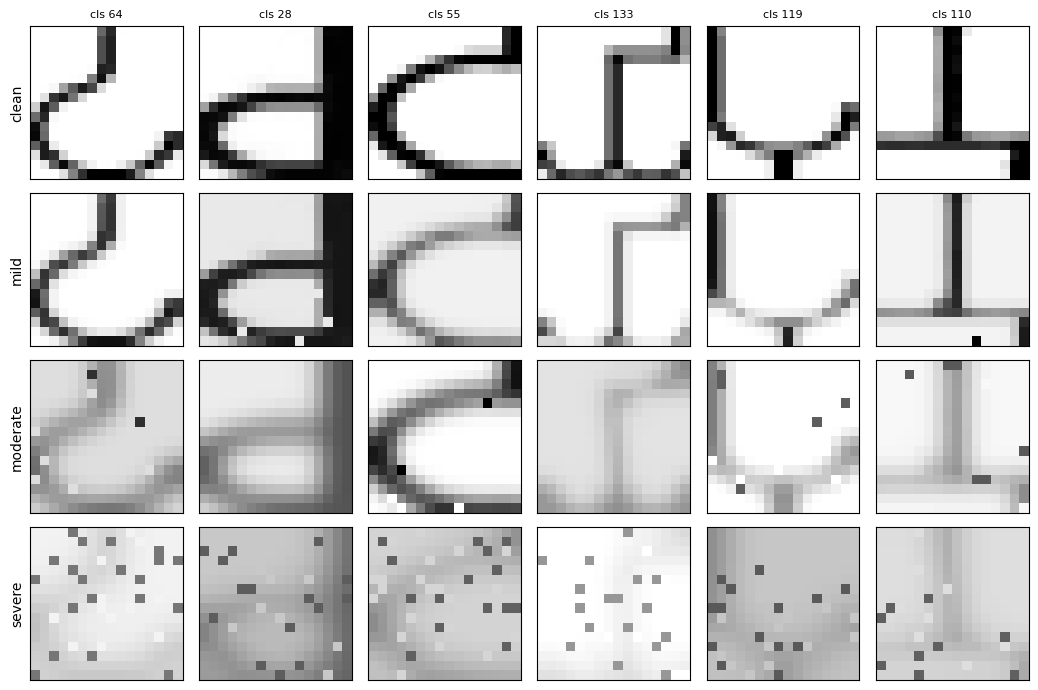

In [14]:
# FIGURE - severity (severity_examples.png)

import matplotlib.pyplot as plt
deg_by, g_te, c_te = {}, None, None
for s in SEVERITIES:
    d_te, g_te, c_te = load_pairs('test', s, 100.0, SEED)
    deg_by[s] = d_te
sel = list(range(6))
fig, axes = plt.subplots(1 + len(SEVERITIES), 6, figsize=(10.5, 7))
for j, i in enumerate(sel):
    axes[0][j].imshow(g_te[i].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0][j].set_title(f'cls {c_te[i]}', fontsize=8)
axes[0][0].set_ylabel('clean')
for r, s in enumerate(SEVERITIES, start=1):
    for j, i in enumerate(sel):
        axes[r][j].imshow(deg_by[s][i].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[r][0].set_ylabel(s)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{RES_DIR}/severity_examples.png', dpi=300, bbox_inches='tight')
plt.show()

### 4b. Recognizer persistence

The fixed recognizer is saved with the results so every OCR-accuracy column in this
and any later session uses the same weights (previously it was retrained per session,
making OCR columns comparable only within a table).


In [15]:
# persist the fixed recognizer -
import os, torch
_CLF = f'{RES_DIR}/clf_recognizer.pt'
if os.path.exists(_CLF):
    clf.load_state_dict(torch.load(_CLF, map_location=DEVICE)); clf.eval()
    print('[clf] recognizer weights reloaded from', _CLF)
else:
    torch.save(clf.state_dict(), _CLF)
    print('[clf] recognizer weights saved to', _CLF, '(recognizer of record for this campaign)')


[clf] recognizer weights saved to /root/qdrm_results/clf_recognizer.pt (recognizer of record for this campaign)


## 5. Experiments
Each restoration model is trained **to completion with epoch-wise train/test logging**
Classical pipeline first (conventional, ConvAE, Residual CNN, U-Net, transformer, diffusion, matched classical control


===== [MILD] DEGRADED INPUT =====
  run 1/1
  -> test PSNR 14.51 dB, SSIM 0.8487, stroke F1 0.8450, OCR 77.76%


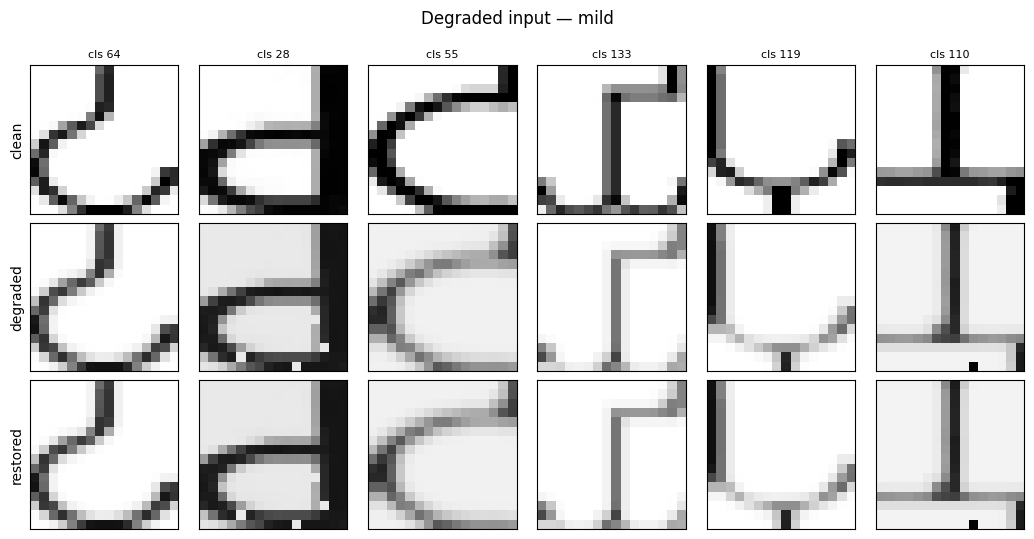


===== [MILD] RESIDUAL CNN =====
  run 1/1
    epoch  25/200  train loss 0.0748  test PSNR 18.43 dB, SSIM 0.9403
    epoch  50/200  train loss 0.0534  test PSNR 19.85 dB, SSIM 0.9587
    epoch  75/200  train loss 0.0497  test PSNR 19.96 dB, SSIM 0.9602
    epoch 100/200  train loss 0.0402  test PSNR 20.44 dB, SSIM 0.9630
    epoch 125/200  train loss 0.0360  test PSNR 21.22 dB, SSIM 0.9703
    epoch 150/200  train loss 0.0265  test PSNR 21.17 dB, SSIM 0.9696
    epoch 175/200  train loss 0.0233  test PSNR 21.42 dB, SSIM 0.9712
    epoch 200/200  train loss 0.0244  test PSNR 21.32 dB, SSIM 0.9711
  -> test PSNR 20.06 dB, SSIM 0.9631, stroke F1 0.9764, OCR 91.41%


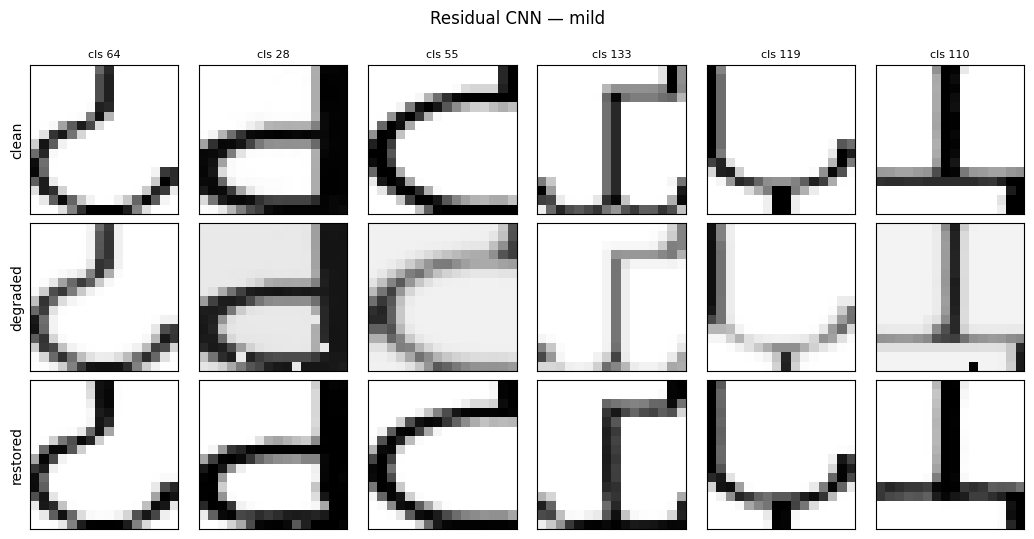


===== [MILD] MATCHED CLASSICAL LATENT MODEL =====
  run 1/1
    epoch  10/25  test PSNR 13.91 dB, SSIM 0.8507
    epoch  20/25  test PSNR 14.20 dB, SSIM 0.8586
    epoch  25/25  test PSNR 14.22 dB, SSIM 0.8591
  -> test PSNR 13.78 dB, SSIM 0.8456, stroke F1 0.9202, OCR 83.18%


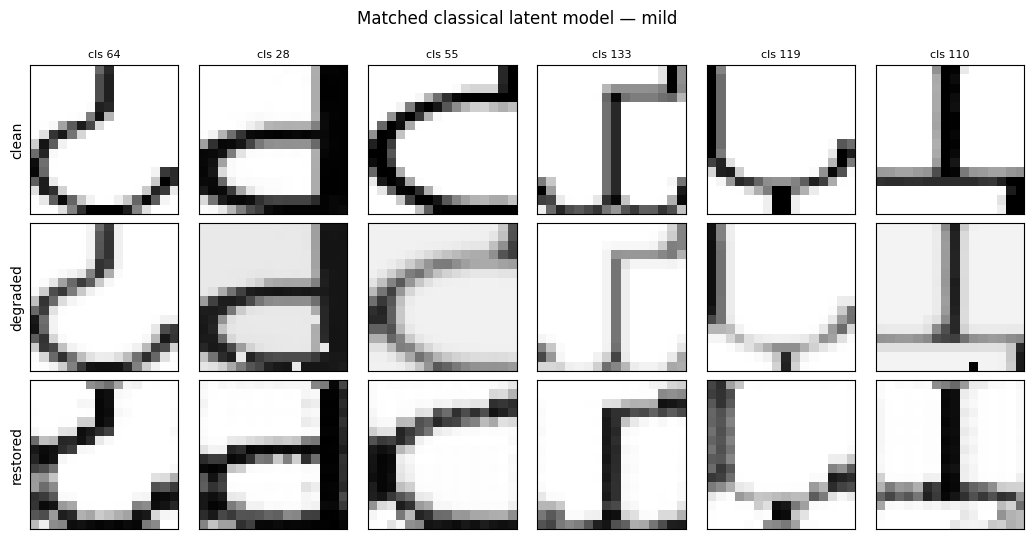


===== [MILD] PROPOSED QDRM =====
  run 1/1
    epoch  10/25  test PSNR 16.38 dB, SSIM 0.9151
    epoch  20/25  test PSNR 16.52 dB, SSIM 0.9182
    epoch  25/25  test PSNR 16.57 dB, SSIM 0.9189
  -> test PSNR 15.96 dB, SSIM 0.9087, stroke F1 0.9529, OCR 87.29%


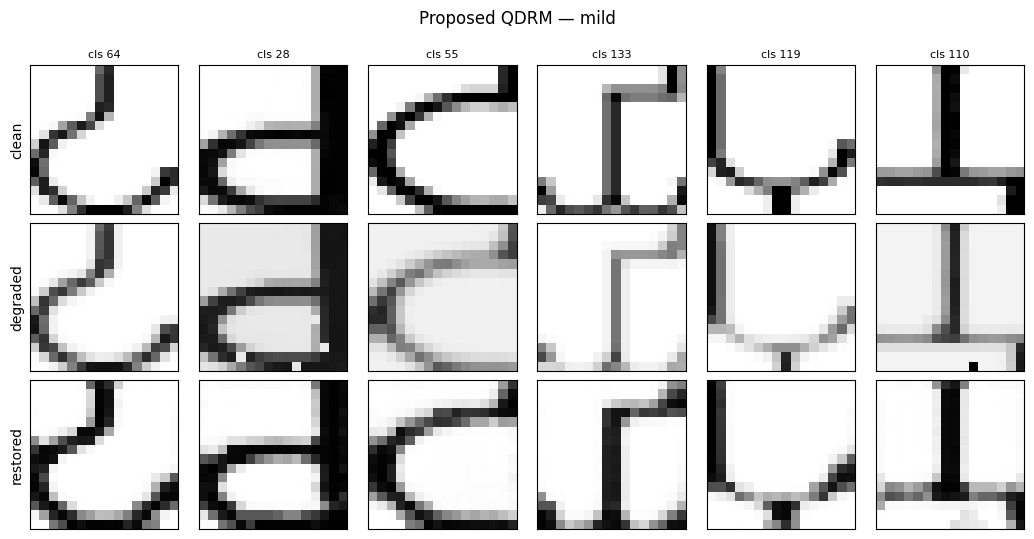


===== [MODERATE] DEGRADED INPUT =====
  run 1/1
  -> test PSNR 10.85 dB, SSIM 0.6265, stroke F1 0.4510, OCR 32.94%


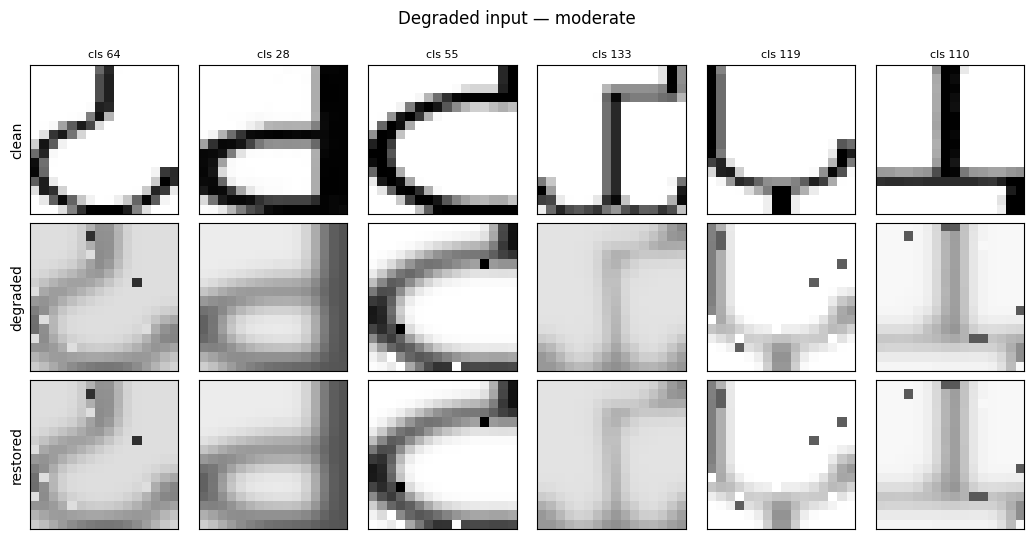


===== [MODERATE] CONVENTIONAL RESTORATION =====
  run 1/3
  -> test PSNR 13.20 dB, SSIM 0.7896, stroke F1 0.8556, OCR 74.35%
  run 2/3
  -> test PSNR 13.20 dB, SSIM 0.7896, stroke F1 0.8556, OCR 74.35%
  run 3/3
  -> test PSNR 13.20 dB, SSIM 0.7896, stroke F1 0.8556, OCR 74.35%


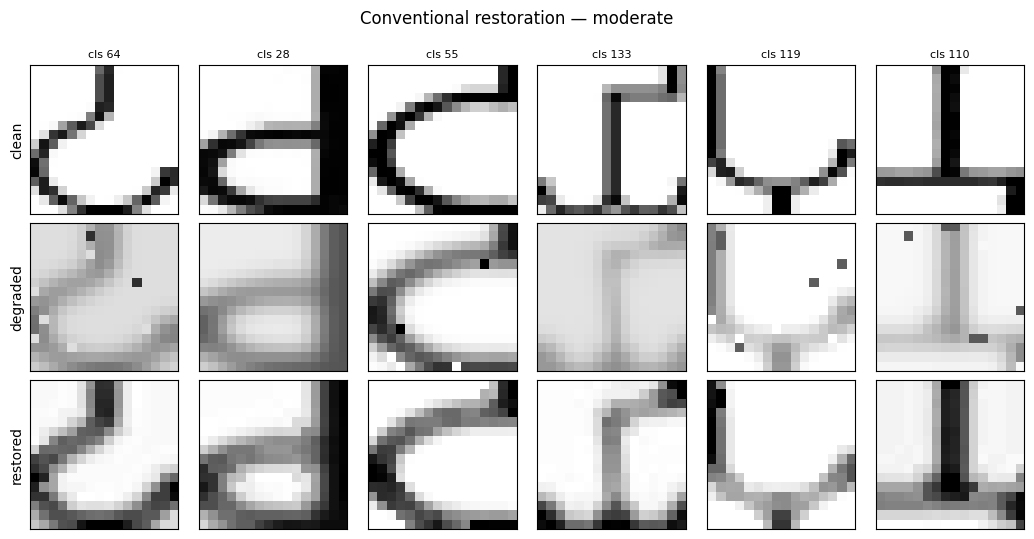


===== [MODERATE] CONVOLUTIONAL AUTOENCODER =====
  run 1/3
    epoch  25/200  train loss 0.3044  test PSNR 11.25 dB, SSIM 0.7142
    epoch  50/200  train loss 0.1967  test PSNR 13.52 dB, SSIM 0.8265
    epoch  75/200  train loss 0.1681  test PSNR 14.09 dB, SSIM 0.8485
    epoch 100/200  train loss 0.1328  test PSNR 14.36 dB, SSIM 0.8589
    epoch 125/200  train loss 0.1262  test PSNR 14.64 dB, SSIM 0.8656
    epoch 150/200  train loss 0.1221  test PSNR 14.84 dB, SSIM 0.8715
    epoch 175/200  train loss 0.1164  test PSNR 15.01 dB, SSIM 0.8775
    epoch 200/200  train loss 0.1178  test PSNR 15.09 dB, SSIM 0.8798
  -> test PSNR 14.73 dB, SSIM 0.8712, stroke F1 0.9373, OCR 80.35%
  run 2/3
    epoch  25/200  train loss 0.3257  test PSNR 10.87 dB, SSIM 0.6760
    epoch  50/200  train loss 0.2181  test PSNR 13.36 dB, SSIM 0.8215
    epoch  75/200  train loss 0.1678  test PSNR 13.79 dB, SSIM 0.8418
    epoch 100/200  train loss 0.1563  test PSNR 14.23 dB, SSIM 0.8522
    epoch 125/200  trai

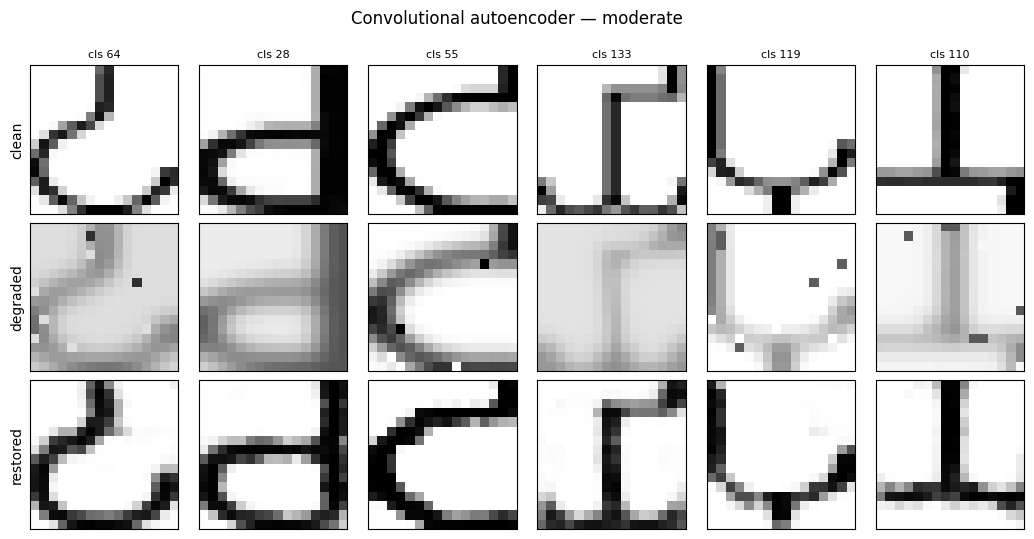


===== [MODERATE] RESIDUAL CNN =====
  run 1/3
    epoch  25/200  train loss 0.5583  test PSNR  6.53 dB, SSIM 0.4053
    epoch  50/200  train loss 0.5824  test PSNR  6.53 dB, SSIM 0.4053
    epoch  75/200  train loss 0.5524  test PSNR  6.53 dB, SSIM 0.4053
    epoch 100/200  train loss 0.1219  test PSNR 15.39 dB, SSIM 0.8926
    epoch 125/200  train loss 0.0873  test PSNR 16.16 dB, SSIM 0.9097
    epoch 150/200  train loss 0.0731  test PSNR 16.31 dB, SSIM 0.9123
    epoch 175/200  train loss 0.0494  test PSNR 16.40 dB, SSIM 0.9141
    epoch 200/200  train loss 0.0407  test PSNR 16.43 dB, SSIM 0.9152
  -> test PSNR 15.77 dB, SSIM 0.9018, stroke F1 0.9618, OCR 85.41%
  run 2/3
    epoch  25/200  train loss 0.1411  test PSNR 15.35 dB, SSIM 0.8912
    epoch  50/200  train loss 0.1287  test PSNR 16.22 dB, SSIM 0.9103
    epoch  75/200  train loss 0.0901  test PSNR 16.40 dB, SSIM 0.9135
    epoch 100/200  train loss 0.0838  test PSNR 16.55 dB, SSIM 0.9172
    epoch 125/200  train loss 0.0624

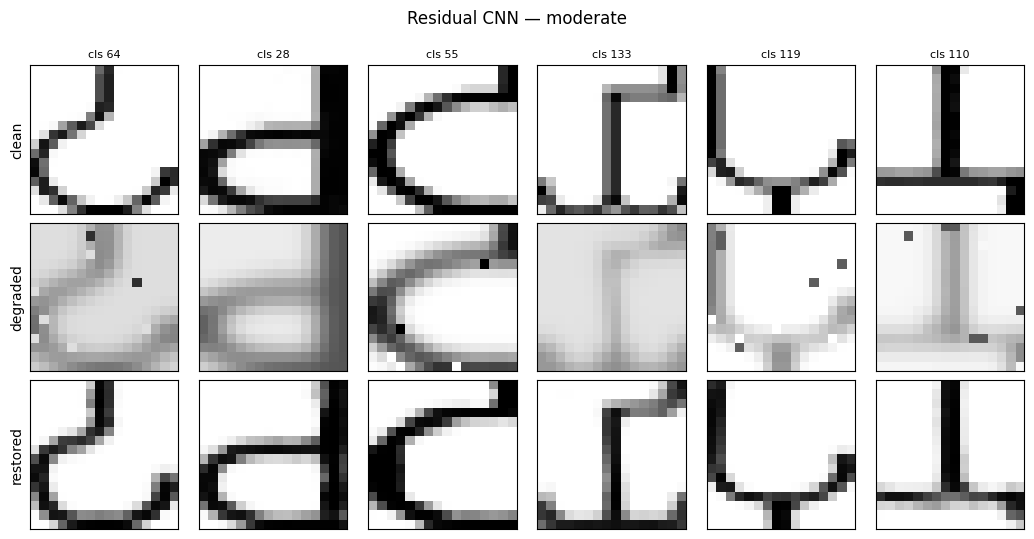


===== [MODERATE] U-NET =====
  run 1/3
    epoch  25/200  train loss 0.2006  test PSNR 14.34 dB, SSIM 0.8435
    epoch  50/200  train loss 0.1269  test PSNR 16.00 dB, SSIM 0.9004
    epoch  75/200  train loss 0.0746  test PSNR 15.85 dB, SSIM 0.8978
    epoch 100/200  train loss 0.0463  test PSNR 15.98 dB, SSIM 0.9016
    epoch 125/200  train loss 0.0361  test PSNR 15.94 dB, SSIM 0.9029
    epoch 150/200  train loss 0.0275  test PSNR 15.91 dB, SSIM 0.9026
    epoch 175/200  train loss 0.0226  test PSNR 15.99 dB, SSIM 0.9036
    epoch 200/200  train loss 0.0353  test PSNR 16.00 dB, SSIM 0.9031
  -> test PSNR 15.67 dB, SSIM 0.8962, stroke F1 0.9508, OCR 84.24%
  run 2/3
    epoch  25/200  train loss 0.1989  test PSNR 14.72 dB, SSIM 0.8557
    epoch  50/200  train loss 0.1393  test PSNR 16.02 dB, SSIM 0.9036
    epoch  75/200  train loss 0.0795  test PSNR 16.17 dB, SSIM 0.9036
    epoch 100/200  train loss 0.0436  test PSNR 16.23 dB, SSIM 0.9087
    epoch 125/200  train loss 0.0280  test 

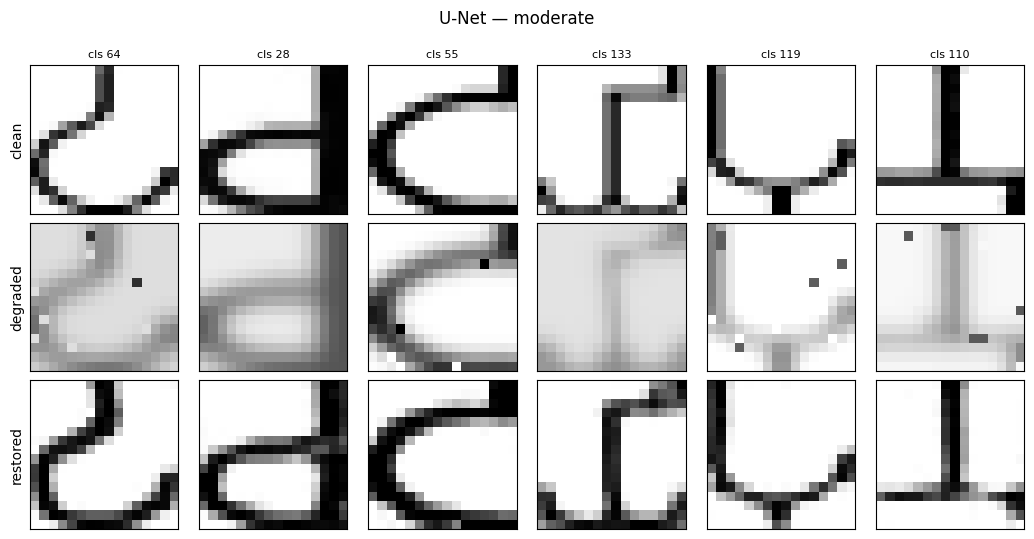


===== [MODERATE] TRANSFORMER RESTORATION =====
  run 1/3
    epoch  25/200  train loss 0.1599  test PSNR 14.31 dB, SSIM 0.8580
    epoch  50/200  train loss 0.1249  test PSNR 15.07 dB, SSIM 0.8827
    epoch  75/200  train loss 0.0988  test PSNR 15.05 dB, SSIM 0.8843
    epoch 100/200  train loss 0.0670  test PSNR 15.08 dB, SSIM 0.8839
    epoch 125/200  train loss 0.0571  test PSNR 15.23 dB, SSIM 0.8886
    epoch 150/200  train loss 0.0541  test PSNR 15.24 dB, SSIM 0.8892
    epoch 175/200  train loss 0.0500  test PSNR 15.14 dB, SSIM 0.8867
    epoch 200/200  train loss 0.0489  test PSNR 15.17 dB, SSIM 0.8875
  -> test PSNR 14.72 dB, SSIM 0.8752, stroke F1 0.9544, OCR 87.76%
  run 2/3
    epoch  25/200  train loss 0.1653  test PSNR 14.21 dB, SSIM 0.8541
    epoch  50/200  train loss 0.1364  test PSNR 15.10 dB, SSIM 0.8847
    epoch  75/200  train loss 0.0907  test PSNR 15.35 dB, SSIM 0.8900
    epoch 100/200  train loss 0.0719  test PSNR 15.42 dB, SSIM 0.8920
    epoch 125/200  train 

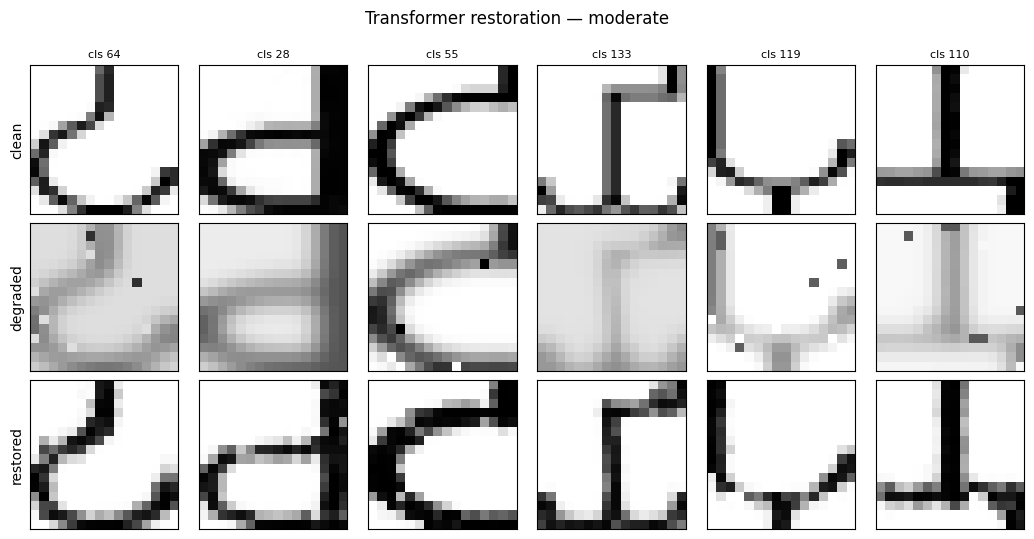


===== [MODERATE] CLASSICAL DIFFUSION MODEL =====
  run 1/3
    epoch  25/200  train loss 0.2160  test PSNR 10.20 dB, SSIM 0.6084
    epoch  50/200  train loss 0.0832  test PSNR 10.29 dB, SSIM 0.6313
    epoch  75/200  train loss 0.2957  test PSNR 11.33 dB, SSIM 0.6871
    epoch 100/200  train loss 0.1370  test PSNR 11.33 dB, SSIM 0.7095
    epoch 125/200  train loss 0.2616  test PSNR 11.57 dB, SSIM 0.7128
    epoch 150/200  train loss 0.7203  test PSNR 11.87 dB, SSIM 0.7149
    epoch 175/200  train loss 0.1626  test PSNR 11.85 dB, SSIM 0.7228
    epoch 200/200  train loss 0.0412  test PSNR 12.44 dB, SSIM 0.7596
  -> test PSNR 12.24 dB, SSIM 0.7450, stroke F1 0.8228, OCR 61.88%
  run 2/3
    epoch  25/200  train loss 0.4167  test PSNR 10.02 dB, SSIM 0.5919
    epoch  50/200  train loss 0.8988  test PSNR 11.46 dB, SSIM 0.6859
    epoch  75/200  train loss 0.0425  test PSNR 10.56 dB, SSIM 0.6628
    epoch 100/200  train loss 0.0692  test PSNR 10.81 dB, SSIM 0.6699
    epoch 125/200  trai

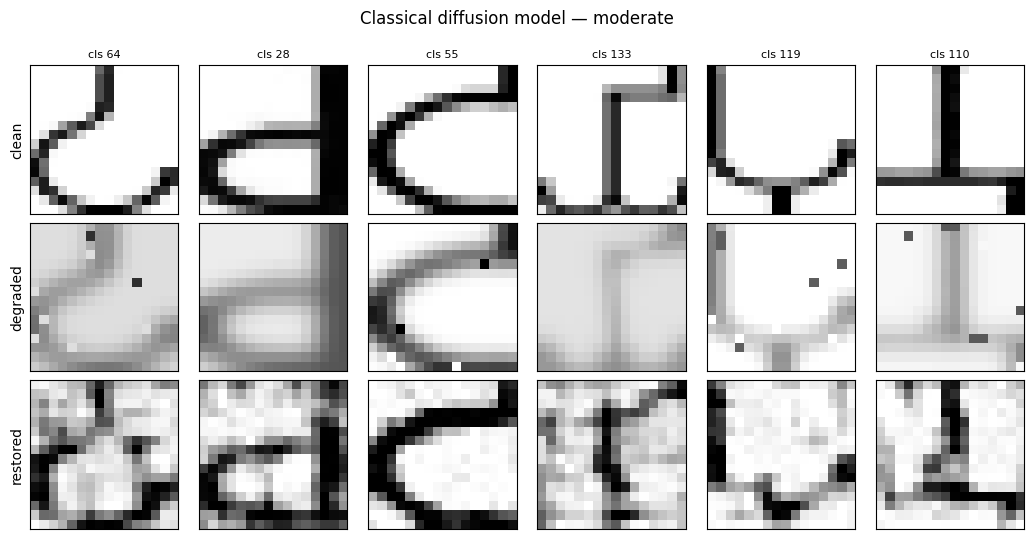


===== [MODERATE] MATCHED CLASSICAL LATENT MODEL =====
  run 1/3
    epoch  10/25  test PSNR 10.84 dB, SSIM 0.6877
    epoch  20/25  test PSNR 11.21 dB, SSIM 0.7081
    epoch  25/25  test PSNR 11.23 dB, SSIM 0.7089
  -> test PSNR 11.08 dB, SSIM 0.6957, stroke F1 0.7844, OCR 61.76%
  run 2/3
    epoch  10/25  test PSNR 11.23 dB, SSIM 0.7083
    epoch  20/25  test PSNR 11.40 dB, SSIM 0.7177
    epoch  25/25  test PSNR 11.34 dB, SSIM 0.7153
  -> test PSNR 11.17 dB, SSIM 0.7013, stroke F1 0.7898, OCR 62.24%
  run 3/3
    epoch  10/25  test PSNR 10.95 dB, SSIM 0.6942
    epoch  20/25  test PSNR 11.02 dB, SSIM 0.6979
    epoch  25/25  test PSNR 11.16 dB, SSIM 0.7055
  -> test PSNR 11.04 dB, SSIM 0.6945, stroke F1 0.7833, OCR 62.47%


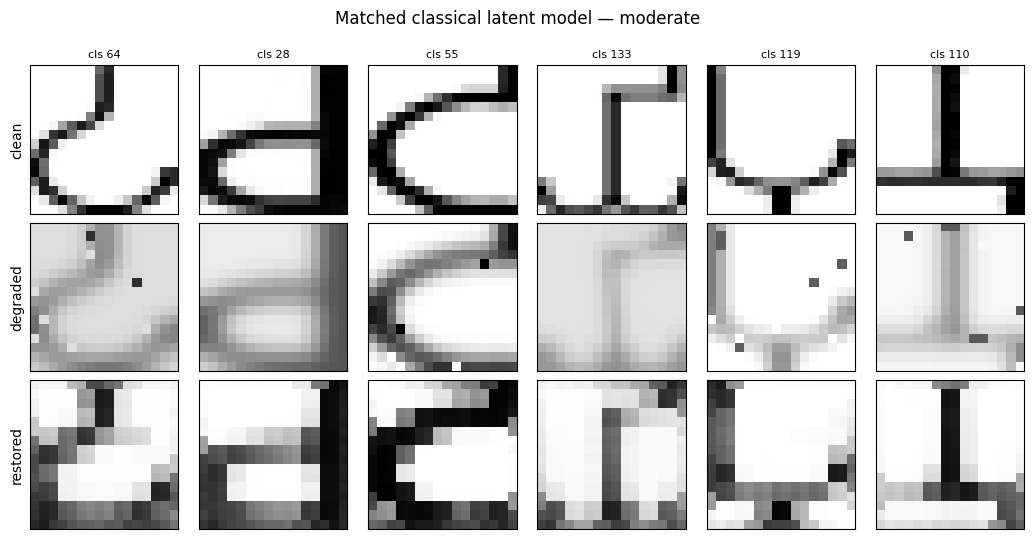


===== [MODERATE] STRICT MATCHED CONTROL (108) =====
  run 1/3
    epoch  10/25  test PSNR 13.04 dB, SSIM 0.8066
    epoch  20/25  test PSNR 13.45 dB, SSIM 0.8233
    epoch  25/25  test PSNR 13.51 dB, SSIM 0.8258
  -> test PSNR 13.22 dB, SSIM 0.8142, stroke F1 0.9070, OCR 80.12%
  run 2/3
    epoch  10/25  test PSNR 13.43 dB, SSIM 0.8213
    epoch  20/25  test PSNR 13.35 dB, SSIM 0.8232
    epoch  25/25  test PSNR 13.49 dB, SSIM 0.8273
  -> test PSNR 13.25 dB, SSIM 0.8164, stroke F1 0.9112, OCR 80.35%
  run 3/3
    epoch  10/25  test PSNR 13.58 dB, SSIM 0.8270
    epoch  20/25  test PSNR 13.54 dB, SSIM 0.8291
    epoch  25/25  test PSNR 13.67 dB, SSIM 0.8326
  -> test PSNR 13.31 dB, SSIM 0.8180, stroke F1 0.9094, OCR 80.12%


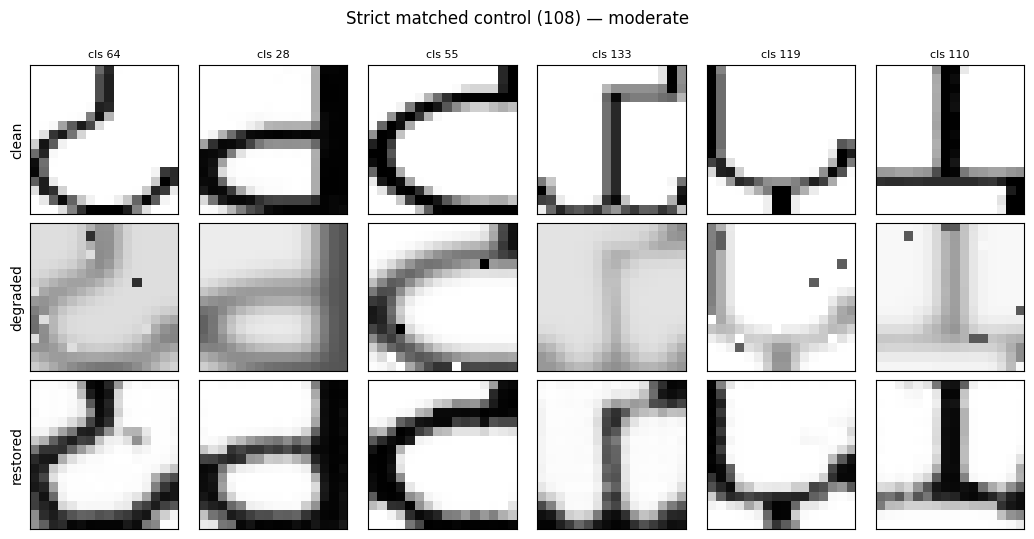


===== [MODERATE] ISO CONTROL L=2 (54) =====
  run 1/3
    epoch  10/25  test PSNR 13.44 dB, SSIM 0.8194
    epoch  20/25  test PSNR 13.67 dB, SSIM 0.8313
    epoch  25/25  test PSNR 13.58 dB, SSIM 0.8293
  -> test PSNR 13.26 dB, SSIM 0.8158, stroke F1 0.9082, OCR 80.24%
  run 2/3
    epoch  10/25  test PSNR 13.68 dB, SSIM 0.8331
    epoch  20/25  test PSNR 13.75 dB, SSIM 0.8363
    epoch  25/25  test PSNR 13.72 dB, SSIM 0.8360
  -> test PSNR 13.34 dB, SSIM 0.8206, stroke F1 0.9125, OCR 79.65%
  run 3/3
    epoch  10/25  test PSNR 13.49 dB, SSIM 0.8206
    epoch  20/25  test PSNR 13.57 dB, SSIM 0.8292
    epoch  25/25  test PSNR 13.60 dB, SSIM 0.8296
  -> test PSNR 13.31 dB, SSIM 0.8176, stroke F1 0.9075, OCR 79.65%


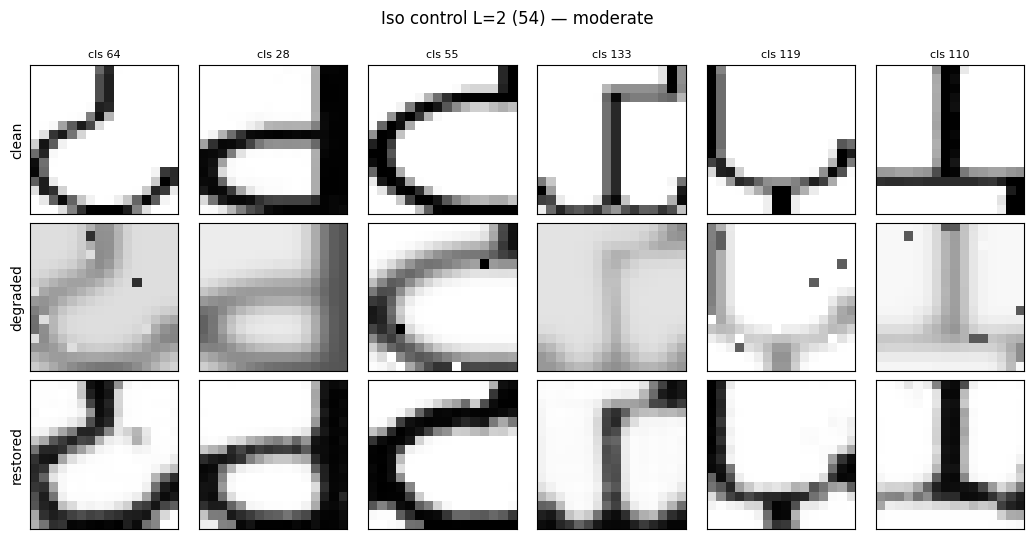


===== [MODERATE] ISO CONTROL L=6 (162) =====
  run 1/3
    epoch  10/25  test PSNR 13.45 dB, SSIM 0.8241
    epoch  20/25  test PSNR 13.83 dB, SSIM 0.8368
    epoch  25/25  test PSNR 13.67 dB, SSIM 0.8336
  -> test PSNR 13.32 dB, SSIM 0.8205, stroke F1 0.9145, OCR 80.82%
  run 2/3
    epoch  10/25  test PSNR 13.71 dB, SSIM 0.8312
    epoch  20/25  test PSNR 13.80 dB, SSIM 0.8357
    epoch  25/25  test PSNR 13.69 dB, SSIM 0.8334
  -> test PSNR 13.35 dB, SSIM 0.8197, stroke F1 0.9086, OCR 78.82%
  run 3/3
    epoch  10/25  test PSNR 13.22 dB, SSIM 0.8103
    epoch  20/25  test PSNR 13.59 dB, SSIM 0.8269
    epoch  25/25  test PSNR 13.49 dB, SSIM 0.8248
  -> test PSNR 13.19 dB, SSIM 0.8131, stroke F1 0.9047, OCR 78.82%


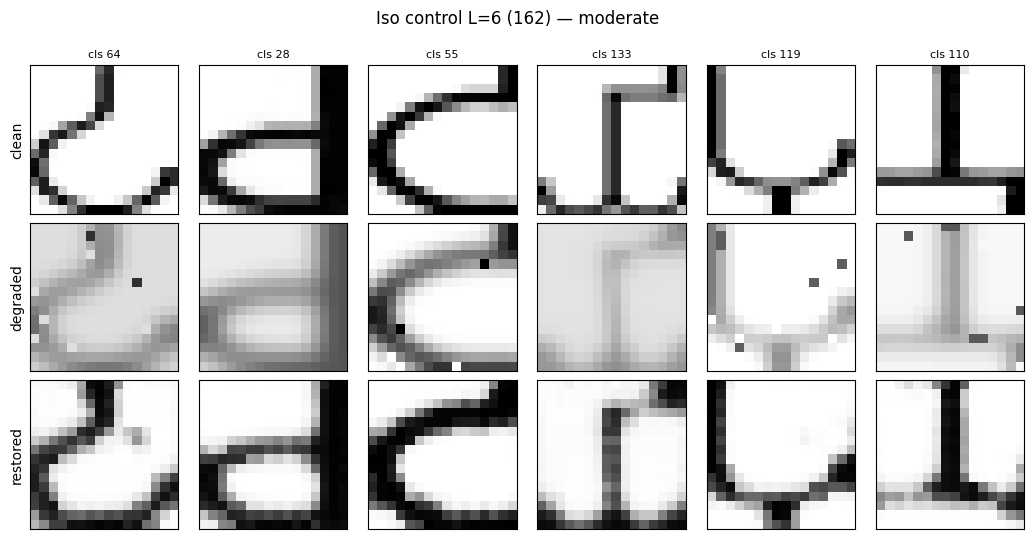


===== [MODERATE] PROPOSED QDRM =====
  run 1/3
    epoch  10/25  test PSNR 13.34 dB, SSIM 0.8217
    epoch  20/25  test PSNR 13.61 dB, SSIM 0.8315
    epoch  25/25  test PSNR 13.59 dB, SSIM 0.8316
  -> test PSNR 13.23 dB, SSIM 0.8181, stroke F1 0.9140, OCR 80.71%
  run 2/3
    epoch  10/25  test PSNR 13.48 dB, SSIM 0.8226
    epoch  20/25  test PSNR 13.41 dB, SSIM 0.8243
    epoch  25/25  test PSNR 13.49 dB, SSIM 0.8269
  -> test PSNR 13.21 dB, SSIM 0.8144, stroke F1 0.9072, OCR 80.00%
  run 3/3
    epoch  10/25  test PSNR 13.46 dB, SSIM 0.8248
    epoch  20/25  test PSNR 13.51 dB, SSIM 0.8300
    epoch  25/25  test PSNR 13.67 dB, SSIM 0.8340
  -> test PSNR 13.30 dB, SSIM 0.8193, stroke F1 0.9104, OCR 79.41%


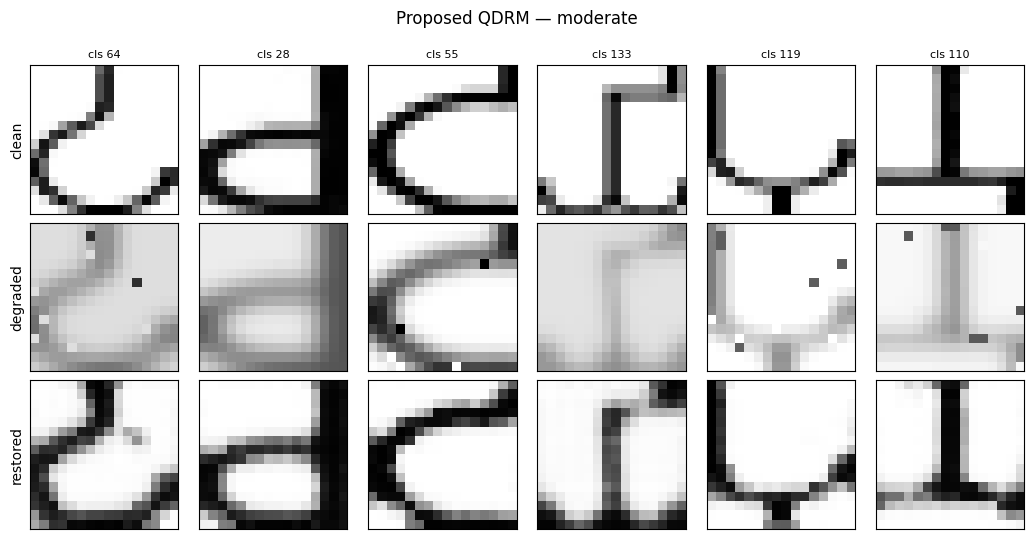


===== [SEVERE] DEGRADED INPUT =====
  run 1/1
  -> test PSNR  8.88 dB, SSIM 0.4398, stroke F1 0.2268, OCR 5.88%


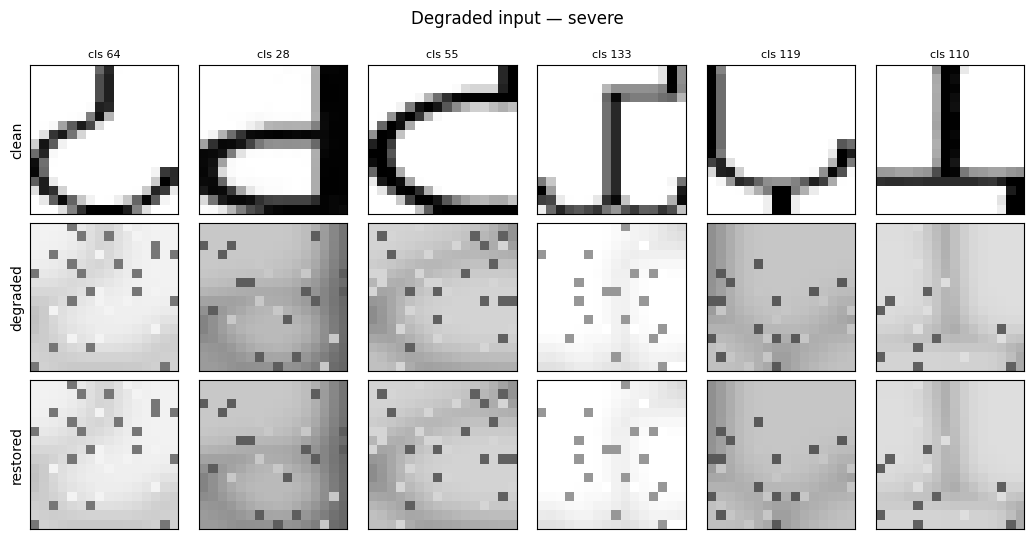


===== [SEVERE] RESIDUAL CNN =====
  run 1/1
    epoch  25/200  train loss 0.5583  test PSNR  6.53 dB, SSIM 0.4053
    epoch  50/200  train loss 0.5824  test PSNR  6.53 dB, SSIM 0.4053
    epoch  75/200  train loss 0.5526  test PSNR  6.53 dB, SSIM 0.4053
    epoch 100/200  train loss 0.5711  test PSNR  6.53 dB, SSIM 0.4053
    epoch 125/200  train loss 0.5639  test PSNR  6.53 dB, SSIM 0.4053
    epoch 150/200  train loss 0.5927  test PSNR  6.53 dB, SSIM 0.4053
    epoch 175/200  train loss 0.5558  test PSNR  6.53 dB, SSIM 0.4053
    epoch 200/200  train loss 0.5714  test PSNR  6.53 dB, SSIM 0.4053
  [!] constant-output collapse detected (std=0.0000) -> reinit, lr/2, retry
    epoch  25/200  train loss 0.5976  test PSNR  6.53 dB, SSIM 0.4053
    epoch  50/200  train loss 0.5326  test PSNR  6.53 dB, SSIM 0.4053
    epoch  75/200  train loss 0.5524  test PSNR  6.53 dB, SSIM 0.4053
    epoch 100/200  train loss 0.5658  test PSNR  6.53 dB, SSIM 0.4053
    epoch 125/200  train loss 0.5571  t

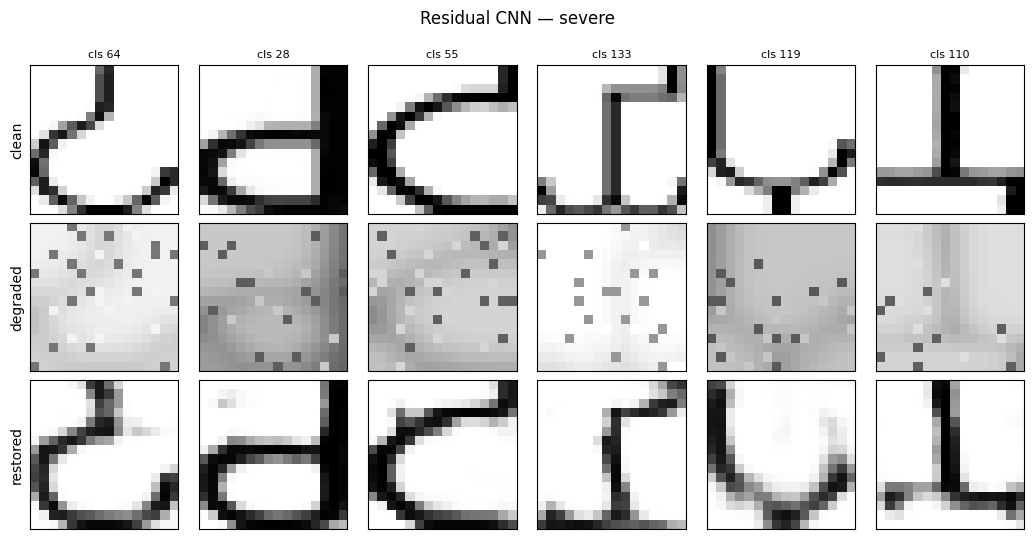


===== [SEVERE] MATCHED CLASSICAL LATENT MODEL =====
  run 1/1
    epoch  10/25  test PSNR  8.55 dB, SSIM 0.5062
    epoch  20/25  test PSNR 10.07 dB, SSIM 0.5886
    epoch  25/25  test PSNR  9.93 dB, SSIM 0.5823
  -> test PSNR  9.91 dB, SSIM 0.5740, stroke F1 0.6669, OCR 32.12%


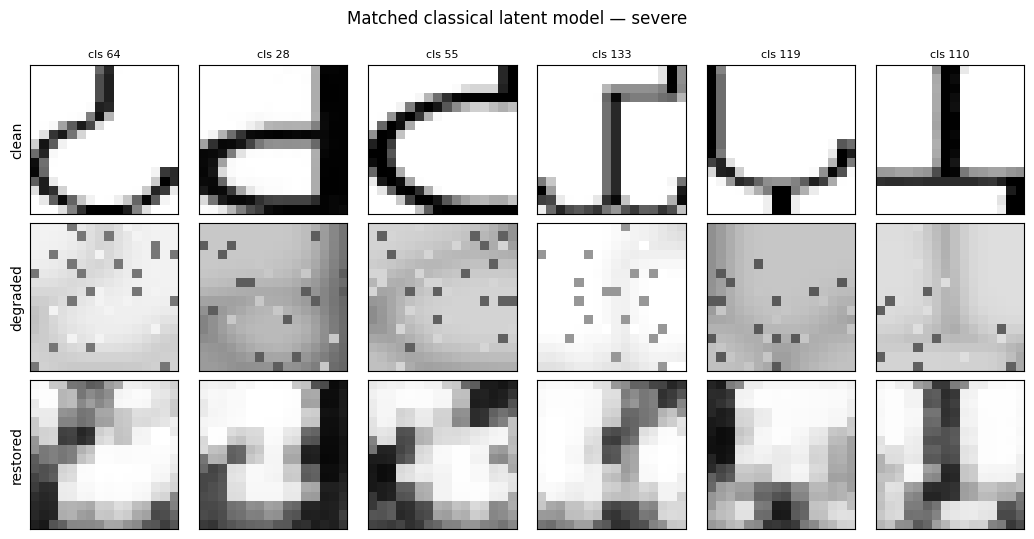


===== [SEVERE] PROPOSED QDRM =====
  run 1/1
    epoch  10/25  test PSNR 10.59 dB, SSIM 0.6318
    epoch  20/25  test PSNR 10.41 dB, SSIM 0.6299
    epoch  25/25  test PSNR 10.49 dB, SSIM 0.6343
  -> test PSNR 10.37 dB, SSIM 0.6228, stroke F1 0.7368, OCR 39.88%


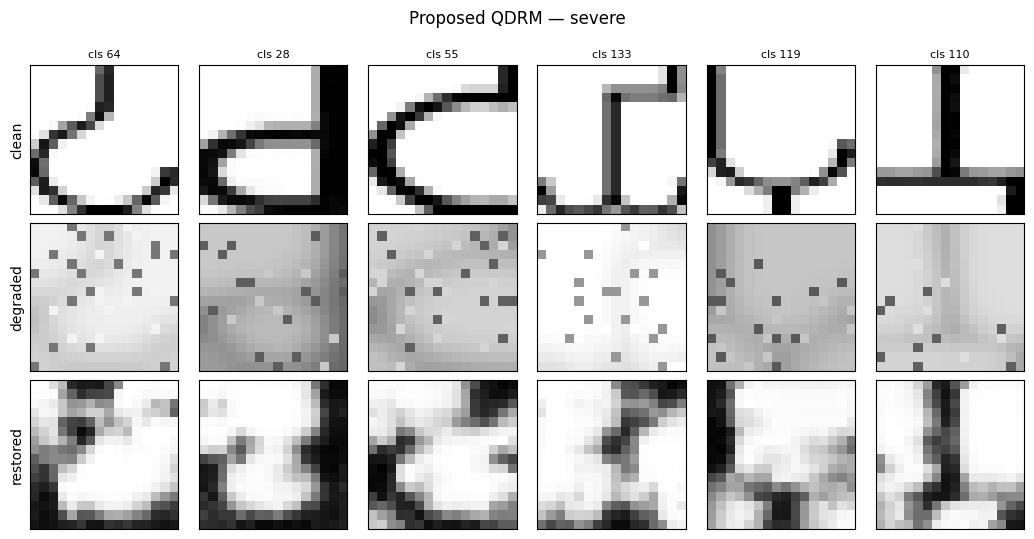


campaign complete — proceed to Sections 6-15 for tables and figures


In [16]:
import pickle, matplotlib.pyplot as plt
METHODS_CLS = ['Degraded input', 'Conventional restoration', 'Convolutional autoencoder',
               'Residual CNN', 'U-Net', 'Transformer restoration',
               'Classical diffusion model', 'Matched classical latent model']
METHOD_Q = 'Proposed QDRM'
# Strictly parameter-matched isomorphic controls + capacity curve (Ref. 1);
# trained only at PRIMARY_SEV via the existing severity gating below.
METHODS_CTRL = ['Strict matched control (108)', 'Iso control L=2 (54)',
                'Iso control L=6 (162)']
ISO_L = {'Strict matched control (108)': 4, 'Iso control L=2 (54)': 2,
         'Iso control L=6 (162)': 6}
ALL_METHODS = METHODS_CLS + METHODS_CTRL + [METHOD_Q]

# RES_DIR on the drive to save the output.
dfs, RESULTS_FID = None, None
FORCE_FRESH_CAMPAIGN = True     # single campaign of record: ignore any local pickle
if FORCE_FRESH_CAMPAIGN and os.path.exists(f'{RES_DIR}/raw_results.pkl'):
    os.remove(f'{RES_DIR}/raw_results.pkl'); print('[campaign] local pickle removed -> fresh campaign')

CKPT_PKL = f'{RES_DIR}/raw_results.pkl'

if not os.path.exists(CKPT_PKL) and dfs:          # fresh runtime -> resume from Drive
    dfs.download('raw_results.pkl', CKPT_PKL, RESULTS_FID)
if os.path.exists(CKPT_PKL):                       # RESUME: reload finished work
    _saved = pickle.load(open(CKPT_PKL, 'rb'))
    results = _saved['results']; runtimes = _saved['runtimes']
    param_counts = _saved['param_counts']
    for s in SEVERITIES:
        results.setdefault(s, {})
        for m in ALL_METHODS:
            results[s].setdefault(m, [])
    done = sum(len(v) for s in results for k, v in results[s].items()
               if not k.startswith('_'))
    print(f'resuming: {done} completed runs found in {CKPT_PKL}')
else:
    results = {s: {m: [] for m in ALL_METHODS} for s in SEVERITIES}
    runtimes, param_counts = {}, {}
mods_cache = {}

def persist():
    pickle.dump(dict(results=results, runtimes=runtimes,
                     param_counts=param_counts), open(CKPT_PKL, 'wb'))
    if dfs:
        try: dfs.upload(CKPT_PKL, parent=RESULTS_FID)
        except Exception as e: print(f'  [drive sync failed: {type(e).__name__}]')

def show_six(name, sev, out, gt_te, deg_te, cls_te):
    sel, seen = [], set()
    for i in range(len(cls_te)):
        if cls_te[i] not in seen:
            sel.append(i); seen.add(cls_te[i])
        if len(sel) == 6: break
    fig, axes = plt.subplots(3, 6, figsize=(10.5, 5.4))
    for j, i in enumerate(sel):
        for r, (im, lab) in enumerate([(gt_te[i], 'clean'), (deg_te[i], 'degraded'),
                                       (out[i], 'restored')]):
            axes[r, j].imshow(im.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
            if j == 0: axes[r, j].set_ylabel(lab)
        axes[0, j].set_title(f'cls {cls_te[i]}', fontsize=8)
    plt.suptitle(f'{name} — {sev}', y=0.99)
    plt.tight_layout(); plt.show()

def test_eval_str(out, gt_te):
    ps = 10*torch.log10(1.0/(((out-gt_te)**2).mean()+1e-12)).item()
    return f'test PSNR {ps:5.2f} dB, SSIM {ssim(out, gt_te).item():.4f}'

def run_method(name, sev, seed, deg_tr, gt_tr, deg_te, gt_te):
    """Train one model verbosely; return restored test set and param count."""
    t0 = time.time()
    if name == 'Degraded input':
        return deg_te.clone(), 0, time.time()-t0
    if name == 'Conventional restoration':
        return conventional_restore(deg_te), 0, time.time()-t0
    if name in ('Matched classical latent model', METHOD_Q) or name in METHODS_CTRL:
        fl = {} if name == METHOD_Q else {'quantum': False}
        if name in METHODS_CTRL:
            fl['iso_L'] = ISO_L[name]
        def cb(ep, tot, mods_p):
            out = qdrm_restore(mods_p, deg_te[:60])
            print(f'    epoch {ep:3d}/{tot}  {test_eval_str(out, gt_te[:60])}', flush=True)
        mods = qdrm_fit(deg_tr, gt_tr, sev, flags=fl, seed=seed, eval_cb=cb, log_every=10)
        tag = ('qdrm' if name == METHOD_Q else
               ('iso%d' % fl['iso_L'] if name in METHODS_CTRL else 'classical'))
        mods_cache[(tag, sev, seed)] = mods
        _cp = f'{RES_DIR}/ckpt_{tag}_{sev}_{seed}.pt'
        torch.save({k: {kk: vv.cpu() for kk, vv in m.state_dict().items()}
                    for k, m in mods.items() if hasattr(m, 'state_dict')}, _cp)
        if dfs:
            try: dfs.upload(_cp, parent=RESULTS_FID)
            except Exception as e: print(f'  [drive sync failed: {type(e).__name__}]')
        out = qdrm_restore(mods, deg_te)
        p = mods['trans'].theta.numel() if name == METHOD_Q else n_params(mods['trans'])
        return out, p, time.time()-t0
    torch.manual_seed(seed)
    net = {'Convolutional autoencoder': ConvAE, 'Residual CNN': ResCNN,
           'U-Net': UNetS, 'Transformer restoration': TransRestorer,
           'Classical diffusion model': CondDiffusion}[name]()
    is_dif = (name == 'Classical diffusion model')
    def cb(ep, tot, model, tr_loss):
        with torch.no_grad():
            out = model(deg_te[:60])
        print(f'    epoch {ep:3d}/{tot}  train loss {tr_loss:.4f}  '
              f'{test_eval_str(out, gt_te[:60])}', flush=True)
    for attempt in range(3):                    # collapse-detect and retry
        net = fit_image_baseline(net, deg_tr, gt_tr, epochs=BASE_EPOCHS,
                                 lr=2e-3/(2**attempt), diffusion=is_dif,
                                 eval_cb=cb, log_every=max(BASE_EPOCHS//8,1))
        with torch.no_grad():
            out = net(deg_te)
        if out.std().item() > 0.02:             # healthy, non-constant output
            break
        print(f'  [!] constant-output collapse detected '
              f'(std={out.std().item():.4f}) -> reinit, lr/2, retry', flush=True)
        torch.manual_seed(seed + 1000*(attempt+1))
        net = {'Convolutional autoencoder': ConvAE, 'Residual CNN': ResCNN,
               'U-Net': UNetS, 'Transformer restoration': TransRestorer,
               'Classical diffusion model': CondDiffusion}[name]()
    return out.clamp(0, 1), n_params(net), time.time()-t0

for SEV in SEVERITIES:
    deg_tr, gt_tr, _ = load_pairs('train', SEV, PCT, SEED)
    deg_te, gt_te, cls_te = load_pairs('test', SEV, 100.0, SEED)
    y_te = torch.tensor([lab2idx[c] for c in cls_te], device=DEVICE)
    methods = ALL_METHODS if SEV == PRIMARY_SEV else \
              ['Degraded input', 'Residual CNN', 'Matched classical latent model', METHOD_Q]
    for name in methods:                                   # one method at a time
        n_seeds = 1 if name == 'Degraded input' else \
                  (R_RUNS if SEV == PRIMARY_SEV else R_RUNS_OTHER)
        print(f'\n===== [{SEV}] {name} ====='.upper(), flush=True)
        if len(results[SEV][name]) >= n_seeds:
            print(f'  already complete ({n_seeds} run(s)) -> skipping', flush=True)
            continue
        for seed in range(len(results[SEV][name]), n_seeds):
            print(f'  run {seed+1}/{n_seeds}', flush=True)
            out, params, dt = run_method(name, SEV, seed, deg_tr, gt_tr, deg_te, gt_te)
            m = full_metrics(out, gt_te, deg_te, clf, y_te)
            m['rest_sample'] = out[:8].cpu()
            results[SEV][name].append(m)
            runtimes.setdefault(name, []).append((dt, len(deg_te)))
            param_counts[name] = params
            persist()                                       # survive session death
            print(f'  -> {test_eval_str(out, gt_te)}, stroke F1 '
                  f'{np.mean(m["f1"]):.4f}, OCR {m["acc"]:.2f}%', flush=True)
        show_six(name, SEV, out, gt_te, deg_te, cls_te)     # six restored characters
    results[SEV]['_data'] = dict(gt=gt_te[:8].cpu(), deg=deg_te[:8].cpu(),
                                 cls=cls_te[:8], y_te=y_te.cpu(), n_test=len(deg_te))
persist()
print('\ncampaign complete — proceed to Sections 6-15 for tables and figures')

## 6. Comparison

In [17]:
import pandas as pd
SEV = PRIMARY_SEV
CTRL108, CTRL152 = 'Strict matched control (108)', 'Matched classical latent model'

def agg(name, key):
    vals = [np.mean(r[key]) for r in results[SEV][name]]
    return mstd(vals, 4 if key in ('ssim','f1','topo') else 2)
def agg_sc(name, key, prec=2):
    return mstd([r[key] for r in results[SEV][name]], prec)
def _fmt_p(p):
    return '< 1e-300' if p == 0 else f'{p:.3g}'

# ---- Table I ----------------------------------------------------------------
rows = [[n, agg(n,'psnr'), agg(n,'ssim'), agg(n,'f1'), agg(n,'topo'),
         agg_sc(n,'acc'), param_counts.get(n, 0)] for n in ALL_METHODS]
t1 = emit_table(rows, ['Method','PSNR','SSIM','Stroke F1','Topology Err','OCR Acc (%)','Params'],
                f'{RES_DIR}/table1_overall.csv', 'Table I — overall comparison')

# ---- Table II (iso controls exist at the primary severity only) --------------
rows = []
for s in SEVERITIES:
    for n in ['Residual CNN', CTRL152, METHOD_Q]:
        rs = results[s][n]
        rows.append([s, n, mstd([np.mean(r['psnr']) for r in rs]),
                     mstd([np.mean(r['ssim']) for r in rs], 4),
                     mstd([np.mean(r['f1']) for r in rs], 4),
                     mstd([r['acc'] for r in rs])])
t2 = emit_table(rows, ['Severity','Method','PSNR','SSIM','Stroke F1','OCR Acc (%)'],
                f'{RES_DIR}/table2_severity.csv',
                'Table II — severity analysis (± over runs at the primary severity; single run elsewhere)')

# ---- Table III (+ strict 108 control) ----------------------------------------
rows = [[n, agg(n,'ep_err'), agg(n,'jc_err'), agg(n,'cc_err'), agg(n,'f1')]
        for n in ['Degraded input','Residual CNN','Classical diffusion model',
                  CTRL152, CTRL108, METHOD_Q]]
t3 = emit_table(rows, ['Method','Endpoint Err','Junction Err','Component Err','Stroke F1'],
                f'{RES_DIR}/table3_structure.csv', 'Table III — structure preservation')

# ---- Table IV (+ strict 108 control; test set loaded once) -------------------
def rec_row(label, key):
    rs = results[SEV][key]
    return [label, mstd([r['acc'] for r in rs]), mstd([r['macro_f1'] for r in rs], 4),
            mstd([r['top3'] for r in rs])]
_dte, _gte, _cte = load_pairs('test', SEV, 100.0, SEED)
gtm = full_metrics(_gte, _gte, _dte, clf,
                   torch.tensor([lab2idx[c] for c in _cte], device=DEVICE))
rows = [['Clean images', f"{gtm['acc']:.2f}", f"{gtm['macro_f1']:.4f}", f"{gtm['top3']:.2f}"],
        rec_row('Degraded images', 'Degraded input'),
        rec_row('Residual CNN outputs', 'Residual CNN'),
        rec_row('Classical diffusion outputs', 'Classical diffusion model'),
        rec_row('Capacity control (152) outputs', CTRL152),
        rec_row('Strict control (108) outputs', CTRL108),
        rec_row('QDRM outputs', METHOD_Q)]
t4 = emit_table(rows, ['Recognizer input','Accuracy (%)','Macro-F1','Top-3 (%)'],
                f'{RES_DIR}/table4_recognition.csv', 'Table IV — recognition')

# ---- Table VI: utility vs BOTH controls (108 primary, 152 capacity) ----------
def _m(name, key):
    return np.mean([np.mean(r[key]) if key != 'acc' else r[key] for r in results[SEV][name]])
rows = []
for metric, key, prec in [('PSNR (dB)','psnr',2), ('SSIM','ssim',4),
                          ('Stroke F1','f1',4), ('OCR accuracy (%)','acc',2)]:
    mq, m108, m152 = _m(METHOD_Q, key), _m(CTRL108, key), _m(CTRL152, key)
    rows.append([metric, f'{m108:.{prec}f}', f'{m152:.{prec}f}', f'{mq:.{prec}f}',
                 f'{mq-m108:+.{prec}f}', f'{mq-m152:+.{prec}f}'])
t6 = emit_table(rows, ['Measure','Strict control (108)','Capacity control (152)',
                       'PQC-QDRM','U vs 108','U vs 152'],
                f'{RES_DIR}/table6_utility.csv',
                'Table VI — PQC utility vs parameter-matched and capacity controls')

# ---- Table VIII -------------------------------------------------------------
rows = []
for n in ALL_METHODS:
    ts = runtimes.get(n, [(0, 1)])
    per_img = np.mean([t/max(k,1)*1000 for t, k in ts])
    rows.append([n, f'{per_img:.1f}', param_counts.get(n, 0)])
t8 = emit_table(rows, ['Method','Total per image (ms)','Params'],
                f'{RES_DIR}/table8_runtime.csv', 'Table VIII — runtime (restore path)')

# ---- Table IX ---------------------------------------------------------------
rows = [['System qubits', NQ], ['Variational layers', L],
        ['Trainable PQC parameters', 3*L*NQ], ['Entangling edges |E|', len(EDGES)],
        ['Observables K', NQ+len(EDGES)], ['One-qubit gates', 6*NQ*L],
        ['Two-qubit gates', len(EDGES)*L], ['Observable groups', 1],
        ['Reverse steps', T]]
t9 = emit_table(rows, ['Resource','Value'], f'{RES_DIR}/table9_resources.csv',
                'Table IX — circuit resources')

# ---- Table X: paired per-image tests, seed 0 --------------------------------
#   (a) QDRM vs strongest classical baseline  (b) QDRM vs strict 108 control
qm = results[SEV][METHOD_Q][0]
strongest = max(['Residual CNN','U-Net','Transformer restoration','Classical diffusion model',
                 'Convolutional autoencoder'],
                key=lambda n: np.mean(results[SEV][n][0]['psnr']))
rows = []
for comp_label, comp in [(strongest, results[SEV][strongest][0]),
                         ('Strict control (108)', results[SEV][CTRL108][0])]:
    for metric, key, prec in [('PSNR','psnr',2), ('SSIM','ssim',4), ('Stroke F1','f1',4)]:
        p, eff = paired_tests(qm[key], comp[key])
        rows.append([comp_label, metric, f'{np.mean(qm[key]-comp[key]):+.{prec}f}',
                     _fmt_p(p), f'{eff:.2f}'])
t10 = emit_table(rows, ['Comparator','Metric','Mean Diff (QDRM − comparator)','p-value','Effect size'],
                 f'{RES_DIR}/table10_stats.csv',
                 'Table X — paired per-image statistics (seed 0)')


=== Table I — overall comparison -> /root/qdrm_results/table1_overall.csv ===
                        Method         PSNR            SSIM       Stroke F1    Topology Err  OCR Acc (%)  Params
                Degraded input 11.08 ± 0.00 0.6265 ± 0.0000 0.4510 ± 0.0000 0.6938 ± 0.0000 32.94 ± 0.00       0
      Conventional restoration 13.43 ± 0.00 0.7896 ± 0.0000 0.8556 ± 0.0000 0.5311 ± 0.0000 74.35 ± 0.00       0
     Convolutional autoencoder 15.07 ± 0.07 0.8685 ± 0.0022 0.9327 ± 0.0068 0.3646 ± 0.0041 80.67 ± 0.62   52129
                  Residual CNN 16.44 ± 0.14 0.9036 ± 0.0018 0.9630 ± 0.0015 0.3172 ± 0.0142 86.16 ± 1.76  167185
                         U-Net 16.16 ± 0.14 0.8942 ± 0.0024 0.9519 ± 0.0012 0.3194 ± 0.0076 85.37 ± 0.91  465953
       Transformer restoration 15.33 ± 0.08 0.8766 ± 0.0017 0.9516 ± 0.0021 0.4237 ± 0.0143 87.18 ± 1.00  105092
     Classical diffusion model 11.78 ± 0.56 0.7183 ± 0.0208 0.8255 ± 0.0123 0.6846 ± 0.1293 59.53 ± 2.77   30361
Matched classical

## 6b. Authentic Brahmi evaluation (Referee comment 3: authentic manuscript images)

21 character pairs extracted from a real rock inscription (TBSI_006): the
weathered incision (`original/`) and the epigraphist's stroke tracing
(`annotated/`). Because both crops come from the same photograph, the paint is
the only difference between them; `annotated-original` therefore isolates the
expert's reading of the strokes, which becomes the binary reference glyph.
Inputs are contrast-stretched originals with strokes normalized to dark-on-light.

Two protocols: **(A) zero-shot** with the moderate-severity checkpoints for every
method, and **(B) leave-one-out fine-tuning** of the three latent models
(108/152 parameters; 20 train / 1 test, 21 folds). Image baselines with
50k–470k parameters are not fine-tuned on 20 images. The reference is an
expert interpretation, not a pristine glyph, and n = 21 from one inscription:
both facts are stated in the manuscript. Simulation only; no QPU.


Downloading...
From: https://drive.google.com/uc?id=1wOP0HzygwgE1F3zkG_0YSWRdRhKAXUwd
To: /root/brahmi_real.zip
100%|██████████| 2.58M/2.58M [00:00<00:00, 137MB/s]


[auth] 19 usable pairs
[align] R1 reference: deg_te moderate, 131072 px, mean 0.782, ink(<0.5) 0.104
char_001.png   diff   79x103 diff=0.52 mask=0.114 ref16=0.113
char_002.png   diff   129x123 diff=0.63 mask=0.131 ref16=0.207
char_003.png   diff   75x95 diff=0.42 mask=0.114 ref16=0.102
char_006.png   diff   83x102 diff=0.46 mask=0.099 ref16=0.109
char_007.png   diff   99x101 diff=0.46 mask=0.088 ref16=0.098
char_008.png   diff   84x85 diff=0.45 mask=0.111 ref16=0.148
char_009.png   diff   91x112 diff=0.47 mask=0.101 ref16=0.109
char_010.png   diff   77x105 diff=0.51 mask=0.114 ref16=0.109
char_011.png   diff   82x98 diff=0.44 mask=0.098 ref16=0.129
char_012.png   diff   105x100 diff=0.43 mask=0.100 ref16=0.156
char_013.png   diff   79x108 diff=0.38 mask=0.079 ref16=0.102
char_014.png   diff   96x98 diff=0.50 mask=0.089 ref16=0.137
char_015.png   diff   85x107 diff=0.45 mask=0.122 ref16=0.125
char_016.png   diff   73x97 diff=0.51 mask=0.090 ref16=0.098
char_017.png   diff   90x106 diff=

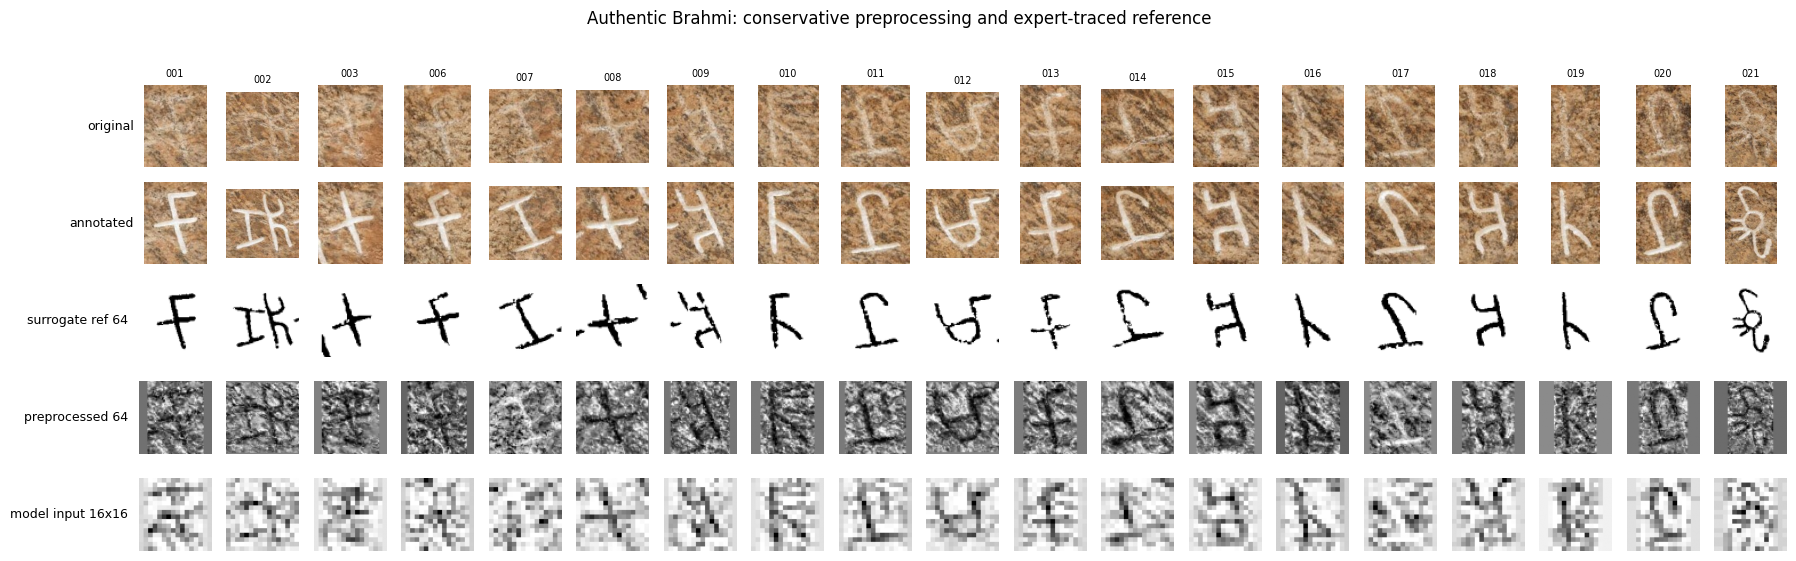

[auth] Proposed QDRM <- /root/qdrm_results/ckpt_qdrm_moderate_0.pt
[auth] Strict matched control (108) <- /root/qdrm_results/ckpt_iso4_moderate_0.pt
[auth] Matched classical latent model (152) <- /root/qdrm_results/ckpt_classical_moderate_0.pt
[auth] trained Residual CNN (residual head) on synthetic moderate (6s)
[auth] trained U-Net on synthetic moderate (6s)
[auth] trained Convolutional autoencoder (residual head) on synthetic moderate (3s)

=== Authentic Brahmi (n=19) — zero-shot, moderate checkpoints -> /root/qdrm_results/table_auth_zeroshot.csv ===
                                   Method    PSNR (dB) dPSNR vs input            SSIM       Stroke F1    Topology Err Wilcoxon p (PSNR vs input)  Transition/Model params
                           Degraded input 11.47 ± 1.57              - 0.6776 ± 0.1637 0.7126 ± 0.2423 0.8488 ± 0.5107                          -                        0
                   Constant white (floor) 10.00 ± 0.83          -1.47 0.5284 ± 0.0375 0.0000 ± 0.000

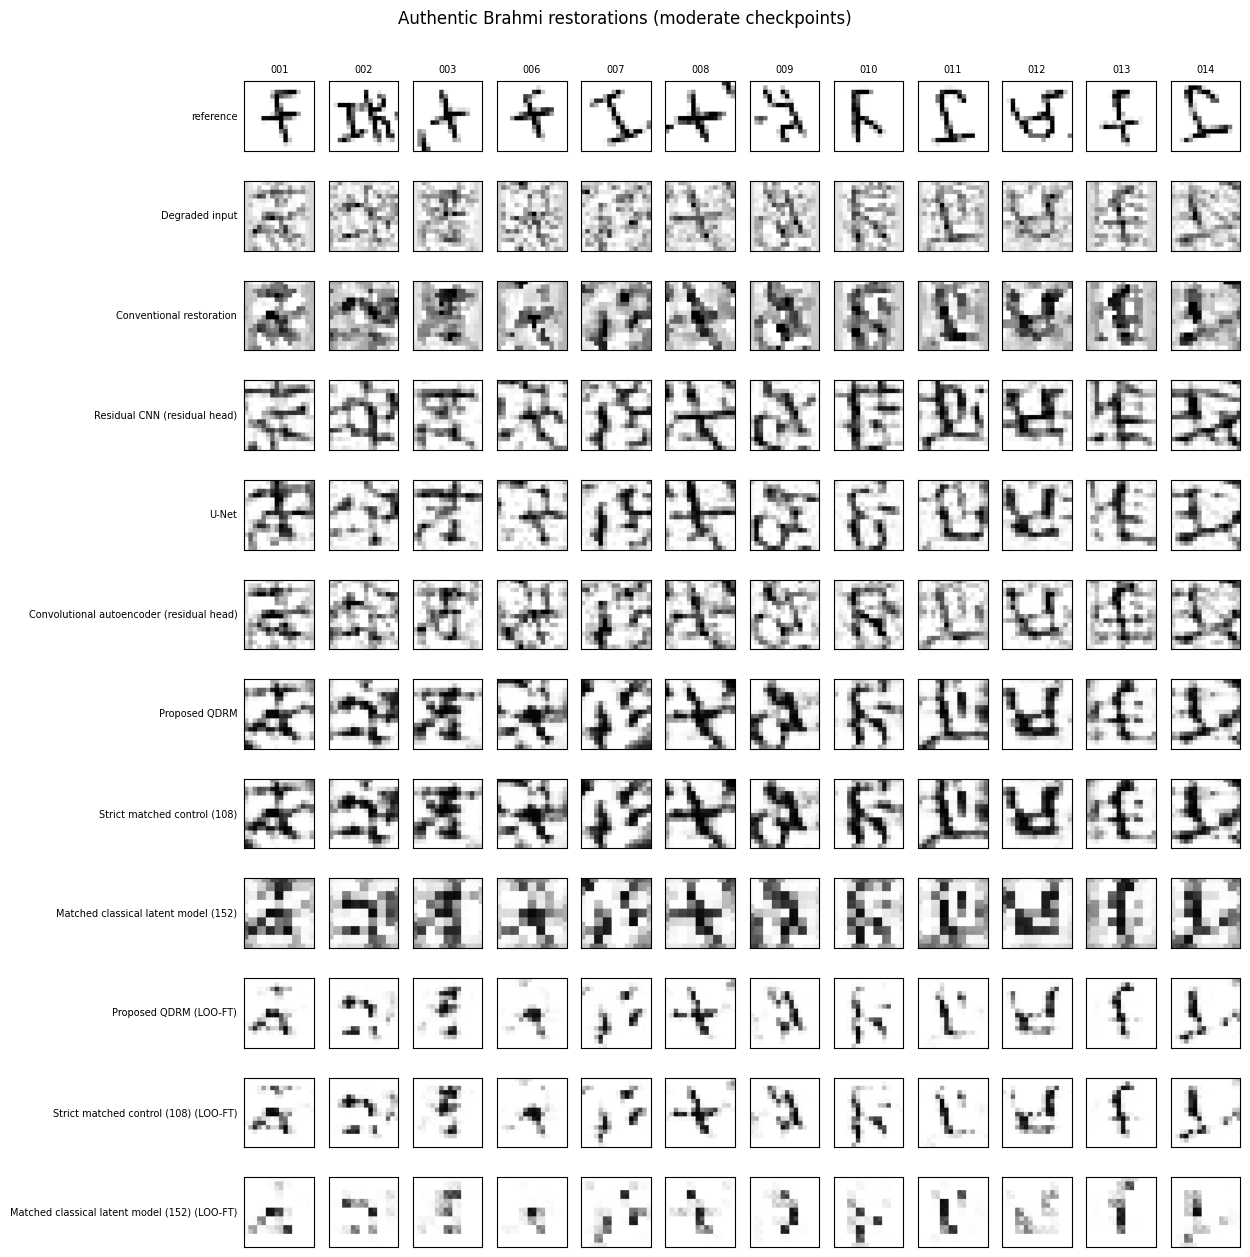

[auth] done


In [18]:
# Real Brahmi dataset

import os, zipfile, glob as _g, time, numpy as np, torch, cv2, matplotlib.pyplot as plt
from PIL import Image

HOME = os.path.expanduser('~')
AUTH_GDRIVE_ID = '1wOP0HzygwgE1F3zkG_0YSWRdRhKAXUwd'
AUTH_ZIP = f'{HOME}/brahmi_real.zip'
AUTH_DIR = f'{HOME}/brahmi_real'
AUTH_TRAIN_IMAGE_BASELINES, AUTH_RUN_LOO = True, True
AUTH_FT_EPOCHS, AUTH_FT_LRS, AUTH_SEED = 60, [3e-4, 1e-3], 0
AUTH_EXCLUDE = ['char_004', 'char_005']
AUTH_CKPT_SEV = 'moderate'                       
AUTH_SWEEP_SEVS = ['mild', 'moderate', 'severe']  
AUTH_FIG_SIZE, AUTH_BG_SIGMA_FRAC = 64, 0.22
AUTH_PCTL_LOW, AUTH_PCTL_HIGH, AUTH_INPUT_GAMMA = 1.0, 99.0, 1.0

AUTH_STROKE_MAP  = False  
AUTH_STROKE_FRAC = 0.10   
AUTH_HIST_MATCH  = True   
AUTH_NLM_H       = 9       
                           
AUTH_TONE_MAP    = False   
                           
_sync = globals().get('dfs')

# fetch + extract
if not os.path.isdir(f'{AUTH_DIR}/original'):
    if not os.path.exists(AUTH_ZIP):
        import gdown
        gdown.download(id=AUTH_GDRIVE_ID, output=AUTH_ZIP, quiet=False)
    with zipfile.ZipFile(AUTH_ZIP) as z: z.extractall(AUTH_DIR)
    if not os.path.isdir(f'{AUTH_DIR}/original'):
        inner = [d for d in _g.glob(f'{AUTH_DIR}/*/') if os.path.isdir(d+'original')]
        assert inner, f'No original/ folder under {AUTH_DIR}'
        AUTH_DIR = inner[0].rstrip('/')

_orig = sorted(_g.glob(f'{AUTH_DIR}/original/*.png'))
_pairs = [(p, f'{AUTH_DIR}/annotated/{os.path.basename(p)}') for p in _orig]
_pairs = [(o,a) for o,a in _pairs if os.path.exists(a)]
_pairs = [(o,a) for o,a in _pairs if os.path.basename(o)[:-4] not in AUTH_EXCLUDE]
print(f'[auth] {len(_pairs)} usable pairs'); assert len(_pairs) >= 5

# Preprocessing 
def _gray(p):
    rgb = np.asarray(Image.open(p).convert('RGB'))
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)[:,:,0].astype(np.float32)/255.0

def _pad_square(x, pad_val=None):
    h,w = x.shape; side = max(h,w)
    if pad_val is None:
        b = np.concatenate([x[0], x[-1], x[:,0], x[:,-1]])
        pad_val = float(np.median(b))
    out = np.full((side,side), pad_val, np.float32)
    y,x0 = (side-h)//2, (side-w)//2
    out[y:y+h, x0:x0+w] = x
    return out

def _robust_norm(x, lo=1, hi=99):
    q0,q1 = np.percentile(x,[lo,hi])
    return np.clip((x-q0)/(q1-q0+1e-6),0,1)

_R1_QGRID = np.linspace(0, 1, 257)
try:
    _r1 = load_pairs('test', AUTH_CKPT_SEV, 100.0, SEED)[0][:512].cpu().numpy().ravel()
    _R1_QUANT = np.quantile(_r1, _R1_QGRID)
    print(f'[align] R1 reference: deg_te {AUTH_CKPT_SEV}, {len(_r1)} px, '
          f'mean {_r1.mean():.3f}, ink(<0.5) {(_r1 < 0.5).mean():.3f}')
except Exception as _e:
    _R1_QUANT = None
    print(f'[align] R1 reference unavailable ({type(_e).__name__}) -> '
          f'histogram matching disabled')

def _quantile_match(x, ref_quant, qgrid=_R1_QGRID):
    """Map x's empirical quantiles onto the reference quantiles
    (histogram specification), preserving rank order exactly."""
    xq = np.quantile(x, qgrid)
    return np.interp(x, xq, ref_quant).astype(np.float32)

def _preprocess_auth_input(o):
    x = o.astype(np.float32)
    sigma = max(5.0, AUTH_BG_SIGMA_FRAC*min(x.shape))
    bg = cv2.GaussianBlur(x,(0,0),sigmaX=sigma,sigmaY=sigma)
    x = _robust_norm(x-bg+np.median(bg), AUTH_PCTL_LOW, AUTH_PCTL_HIGH)
    if AUTH_INPUT_GAMMA != 1.0: x = np.power(x, AUTH_INPUT_GAMMA)

    # input-only polarity check; no annotation leakage
    border = np.concatenate([x[0],x[-1],x[:,0],x[:,-1]])
    center = x[x.shape[0]//4:3*x.shape[0]//4, x.shape[1]//4:3*x.shape[1]//4]
    if np.median(center) > np.median(border): x = 1.0-x

    if AUTH_NLM_H > 0:
        # average out isotropic granite grain; NLM preserves elongated
      
        u8 = (np.clip(x,0,1) * 255).astype(np.uint8)
        u8 = cv2.fastNlMeansDenoising(u8, None, AUTH_NLM_H, 7, 21)
        x = u8.astype(np.float32) / 255.0

    if AUTH_TONE_MAP:
        
        m = float(np.median(x))
        gain = 1.0 / max(m - float(np.percentile(x, 2)), 1e-3)
        x = np.clip(1.0 - gain * np.maximum(m - x, 0.0), 0.0, 1.0)

    if AUTH_STROKE_MAP:
      
        k = max(3, int(AUTH_STROKE_FRAC * min(x.shape)) | 1)
        u8 = (x * 255).astype(np.uint8)
        u8 = cv2.bilateralFilter(u8, d=5, sigmaColor=25, sigmaSpace=5)
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        bh = cv2.morphologyEx(u8, cv2.MORPH_BLACKHAT, ker).astype(np.float32) / 255.0
        bh = _robust_norm(bh, 50.0, 99.5)
        k2 = max(1, int(round(min(x.shape) / (2.0 * SIZE))))
        if k2 > 1:
            bh = cv2.dilate(bh, cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE, (2*k2+1, 2*k2+1)))
        x = 1.0 - bh

    xs = _pad_square(x)
    deg64 = cv2.resize(xs,(AUTH_FIG_SIZE,AUTH_FIG_SIZE),interpolation=cv2.INTER_AREA)
    tmp = cv2.GaussianBlur(deg64,(0,0),0.45)
    deg16 = cv2.resize(tmp,(SIZE,SIZE),interpolation=cv2.INTER_AREA)
    # Histogram specification LAST, at the model scale: quantile-map the final
    # 16x16 input onto the pooled deg_te distribution (matching earlier lets
    # the downscale destroy the matched statistics).
    if AUTH_HIST_MATCH and _R1_QUANT is not None:
        deg16 = np.clip(_quantile_match(deg16, _R1_QUANT), 0, 1)
    return np.clip(deg16,0,1), np.clip(deg64,0,1)

# Expert-traced reference 
def _build_reference(o,a):
    aligned = o.shape == a.shape
    if aligned:
        cc = np.corrcoef(o.ravel(),a.ravel())[0,1]
        aligned = np.isfinite(cc) and cc > 0.5
    diff, how = (np.clip(a-o,0,1),'diff') if aligned else (a.copy(),'bright')

    d8 = cv2.GaussianBlur((diff*255).astype(np.uint8),(3,3),0.5)
    otsu,_ = cv2.threshold(d8,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    thr = max(otsu/255.0,0.05)
    mask = diff > thr
    if mask.mean() < 0.003 or mask.mean() > 0.50:
        mask = diff > max(0.05,np.percentile(diff,92))

    nlab,lab,stats,_ = cv2.connectedComponentsWithStats(mask.astype(np.uint8),8)
    min_area = max(3,int(0.001*mask.size))
    keep = [i for i in range(1,nlab) if stats[i,cv2.CC_STAT_AREA] >= min_area]
    mask = np.isin(lab,keep).astype(np.float32)
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,np.ones((2,2),np.uint8)).astype(np.float32)

    ms = _pad_square(mask,0.0)
    cov64 = cv2.resize(ms,(AUTH_FIG_SIZE,AUTH_FIG_SIZE),interpolation=cv2.INTER_AREA)
    cov16 = cv2.resize(ms,(SIZE,SIZE),interpolation=cv2.INTER_AREA)
    def _covnorm(cov):
       
        if cov.max() > 0:
            q = np.percentile(cov[cov > 0], 75)
            cov = np.clip(cov / max(q, 1e-6), 0, 1)
        return 1.0 - cov
    return _covnorm(cov16), _covnorm(cov64), mask, how, diff, thr

def _build_pair(o_path,a_path,verbose=True):
    o,a = _gray(o_path),_gray(a_path)
    deg16,deg64 = _preprocess_auth_input(o)
    ref16,ref64,m,how,diff,thr = _build_reference(o,a)
    meta = dict(how=how, stroke_frac=float(m.mean()), shape=o.shape,
                d_max=float(diff.max()), thr=float(thr),
                ref_ink=float((ref16<0.5).mean()))
    if verbose:
        print(f'{os.path.basename(o_path):14s} {how:6s} {o.shape[1]}x{o.shape[0]} '
              f'diff={meta["d_max"]:.2f} mask={meta["stroke_frac"]:.3f} '
              f'ref16={meta["ref_ink"]:.3f}')
    return deg16,ref16,deg64,ref64,meta

# tensors 
_deg,_ref,_deg64,_ref64,_meta = [],[],[],[],[]
for o,a in _pairs:
    d16,r16,d64,r64,mt = _build_pair(o,a)
    _deg.append(d16); _ref.append(r16); _deg64.append(d64); _ref64.append(r64); _meta.append(mt)

deg_auth = torch.tensor(np.stack(_deg),dtype=torch.float32).to(DEVICE)
ref_auth = torch.tensor(np.stack(_ref),dtype=torch.float32).to(DEVICE)
_names = [os.path.basename(o)[:-4] for o,_ in _pairs]
n = len(_pairs)
_mean_ink = float((ref_auth < 0.5).float().mean())
print(f'[auth] tensors {tuple(deg_auth.shape)} | mean reference ink {_mean_ink:.3f}')
# ---- measured domain gap: processed authentic inputs vs R1 degraded ----------
if _R1_QUANT is not None:
    _ax = deg_auth.cpu().numpy().ravel()
    try:
        _r1_16 = load_pairs('test', AUTH_CKPT_SEV, 100.0, SEED)[0][:512].cpu().numpy().ravel()
        _w = float(np.abs(np.quantile(_ax, _R1_QGRID)
                          - np.quantile(_r1_16, _R1_QGRID)).mean())
        print(f'[align] authentic inputs: mean {_ax.mean():.3f} std {_ax.std():.3f} '
              f'ink(<0.5) {(_ax < 0.5).mean():.3f} | R1 deg_te: mean {_r1_16.mean():.3f} '
              f'std {_r1_16.std():.3f} ink {(_r1_16 < 0.5).mean():.3f} | '
              f'W1 distance {_w:.4f}')
    except Exception as _e:
        print(f'[align] gap diagnostic skipped ({type(_e).__name__})')
assert _mean_ink > 0.03, ('reference nearly empty (mean ink '
    f'{_mean_ink:.3f}) - stroke-core renormalization failed; do not evaluate')
_ink_in = float((deg_auth < 0.5).float().mean())
_f1_in = float(np.mean(stroke_f1_arr(deg_auth.cpu().numpy(), ref_auth.cpu().numpy())))
print(f'[auth] input ink(<0.5) {_ink_in:.3f} | input-vs-reference stroke F1 {_f1_in:.3f}')
assert _ink_in > 0.03, (f'inputs nearly stroke-free (ink {_ink_in:.3f}) - '
    'stroke map washed out in the downscale; do not evaluate')

# preview 
def _show16(x,size=128):
    return cv2.resize(np.asarray(x,np.float32),(size,size),interpolation=cv2.INTER_NEAREST)

fig,ax = plt.subplots(5,n,figsize=(0.95*n,5.5))
for j,(o,a) in enumerate(_pairs):
    ax[0,j].imshow(np.asarray(Image.open(o))); ax[0,j].axis('off')
    ax[1,j].imshow(np.asarray(Image.open(a))); ax[1,j].axis('off')
    ax[2,j].imshow(_ref64[j],cmap='gray',vmin=0,vmax=1); ax[2,j].axis('off')
    ax[3,j].imshow(_deg64[j],cmap='gray',vmin=0,vmax=1); ax[3,j].axis('off')
    ax[4,j].imshow(_show16(_deg[j]),cmap='gray',vmin=0,vmax=1); ax[4,j].axis('off')
    ax[0,j].set_title(_names[j][-3:],fontsize=7)

for r,lab in enumerate(['original','annotated','surrogate ref 64','preprocessed 64',
                        f'model input {SIZE}x{SIZE}']):
    ax[r,0].text(-0.15,0.5,lab,transform=ax[r,0].transAxes,
                 ha='right',va='center',fontsize=9)
fig.suptitle('Authentic Brahmi: conservative preprocessing and expert-traced reference',y=1.02)
fig.tight_layout()
_png = f'{RES_DIR}/auth_pairs_preview.png'
fig.savefig(_png,dpi=250,bbox_inches='tight')
if _sync: _sync.upload(_png)
plt.show(); plt.close(fig)

# metrics
def auth_metrics(rest_t,ref_t):
    rest = rest_t.clamp(0,1); ref = ref_t
    mse = ((rest-ref)**2).reshape(len(rest),-1).mean(-1)
    psnr = (10*torch.log10(1/(mse+1e-12))).cpu().numpy()
    ssim_pi = np.array([ssim(rest[i:i+1],ref[i:i+1]).item() for i in range(len(rest))])
    rn,cn = rest.cpu().numpy(),ref.cpu().numpy()
    f1 = stroke_f1_arr(rn,cn)
    _,_,_,te = topology_errors(rn,cn)
    return dict(psnr=psnr,ssim=ssim_pi,f1=np.asarray(f1),topo=np.asarray(te))

def _wilcoxon_p(a,b):
    try:
        from scipy.stats import wilcoxon
        d = np.asarray(a)-np.asarray(b)
        return wilcoxon(d).pvalue if np.any(d!=0) else 1.0
    except Exception:
        return float('nan')

# Rebuild latent models
def _rebuild_latent(path,tag):
    sd = torch.load(path,map_location='cpu')
    quantum = tag=='qdrm'
    enc = FRQIMPSEncoder(g.h*g.w,DZ).to(DEVICE)
    Pc = BoundedProjection(DZ,NQ).to(DEVICE); Pd = BoundedProjection(DZ,NQ).to(DEVICE)
    Pt = BoundedProjection(1,NQ).to(DEVICE)
    if quantum:
        trans = make_transition(NQ,L,EDGES,SIM,DIFF).to(QDEV)
    elif tag.startswith('iso'):
        trans = IsoClassicalTransition(NQ,int(tag[3:]),EDGES).to(DEVICE)
    else:
        trans = ClassicalTransition(NQ,L,EDGES).to(DEVICE)
    ro = Readout(getattr(trans,'K',NQ+len(EDGES)),DZ).to(DEVICE)
    dec = PatchDecoder(DZ,g.h*g.w).to(DEVICE)
    mm = dict(enc=enc,Pc=Pc,Pd=Pd,Pt=Pt,trans=trans,ro=ro,dec=dec)
    for k,m in mm.items(): m.load_state_dict(sd[k]); m.eval()
    def q(zc,zd,tau,_t=trans,_qu=quantum):
        return _t(zc.to(QDEV),zd.to(QDEV),tau.to(QDEV)).to(DEVICE) if _qu else _t(zc,zd,tau)
    mm.update(flags=dict(DEFAULT_FLAGS,quantum=quantum,
                         iso_L=int(tag[3:]) if tag.startswith('iso') else 0),
              Tloc=T,q=q)
    return mm

LATENT = [('qdrm','Proposed QDRM'),
          ('iso4','Strict matched control (108)'),
          ('classical','Matched classical latent model (152)')]

def _ckpt(tag, sev=None):
    sev = sev or AUTH_CKPT_SEV
    c = [p for p in [f'{RES_DIR}/ckpt_{tag}_{sev}_0.pt'] if os.path.exists(p)]
    return c[0] if c else None

latent_mods = {}
for tag,lab in LATENT:
    p = _ckpt(tag)
    if p is None:
        print(f'[auth] no {AUTH_CKPT_SEV} checkpoint for {lab} -> skipped'); continue
    latent_mods[tag] = (_rebuild_latent(p,tag),p)
    print(f'[auth] {lab} <- {p}')

# image baselines
import torch.nn as nn, torch.nn.functional as F

class _ConvAERes(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = nn.Sequential(nn.Conv2d(1,32,3,2,1),nn.ReLU(),
                               nn.Conv2d(32,64,3,2,1),nn.ReLU())
        self.d = nn.Sequential(nn.ConvTranspose2d(64,32,4,2,1),nn.ReLU(),
                               nn.ConvTranspose2d(32,1,4,2,1))
    def forward(self,x):
        x1=x.unsqueeze(1); return (x1+self.d(self.e(x1))).squeeze(1)

class _ResCNNRes(nn.Module):
    def __init__(self,ch=48,blocks=4):
        super().__init__()
        self.inp=nn.Conv2d(1,ch,3,1,1)
        self.blocks=nn.ModuleList([nn.Sequential(nn.Conv2d(ch,ch,3,1,1),nn.ReLU(),
                                                 nn.Conv2d(ch,ch,3,1,1)) for _ in range(blocks)])
        self.out=nn.Conv2d(ch,1,3,1,1)
    def forward(self,x):
        x1=x.unsqueeze(1); h=self.inp(x1)
        for b in self.blocks: h=F.relu(h+b(h))
        return (x1+self.out(h)).squeeze(1)

image_models = {}
if AUTH_TRAIN_IMAGE_BASELINES:
    _dtr,_gtr,_ = load_pairs('train',AUTH_CKPT_SEV,PCT,SEED)
    for name,ctor in [('Residual CNN (residual head)',_ResCNNRes),
                      ('U-Net',UNetS),
                      ('Convolutional autoencoder (residual head)',_ConvAERes)]:
        torch.manual_seed(AUTH_SEED); t0=time.time()
        m=fit_image_baseline(ctor().to(DEVICE),_dtr,_gtr,epochs=BASE_EPOCHS,log_every=10**9)
        m.eval(); image_models[name]=m
        print(f'[auth] trained {name} on synthetic {AUTH_CKPT_SEV} ({time.time()-t0:.0f}s)')

# Zero-shot
def _fmt(a,p=2): return f'{np.mean(a):.{p}f} ± {np.std(a):.{p}f}'
zs_out,rows = {},[]
m0 = auth_metrics(deg_auth,ref_auth); zs_out['Degraded input']=deg_auth

def _zrow(label,mm,nparams):
    dp=np.mean(mm['psnr'])-np.mean(m0['psnr'])
    return [label,_fmt(mm['psnr']),f'{dp:+.2f}',_fmt(mm['ssim'],4),_fmt(mm['f1'],4),
            _fmt(mm['topo'],4),f'{_wilcoxon_p(mm["psnr"],m0["psnr"]):.3g}',nparams]

rows.append(['Degraded input',_fmt(m0['psnr']),'-',_fmt(m0['ssim'],4),
             _fmt(m0['f1'],4),_fmt(m0['topo'],4),'-',0])

mw = auth_metrics(torch.ones_like(ref_auth),ref_auth)
rows.append(_zrow('Constant white (floor)',mw,0))

with torch.no_grad():
    out=conventional_restore(deg_auth).to(DEVICE)
    zs_out['Conventional restoration']=out
    rows.append(_zrow('Conventional restoration',auth_metrics(out,ref_auth),0))

    for name,m in image_models.items():
        out=m(deg_auth).clamp(0,1); zs_out[name]=out
        rows.append(_zrow(name,auth_metrics(out,ref_auth),sum(p.numel() for p in m.parameters())))

    for tag,lab in LATENT:
        if tag not in latent_mods: continue
        mods=latent_mods[tag][0]
        out=qdrm_restore(mods,deg_auth).clamp(0,1); zs_out[lab]=out
        rows.append(_zrow(lab,auth_metrics(out,ref_auth),
                          sum(p.numel() for p in mods['trans'].parameters())))

emit_table(rows,
           ['Method','PSNR (dB)','dPSNR vs input','SSIM','Stroke F1','Topology Err',
            'Wilcoxon p (PSNR vs input)','Transition/Model params'],
           f'{RES_DIR}/table_auth_zeroshot.csv',
           f'Authentic Brahmi (n={n}) — zero-shot, {AUTH_CKPT_SEV} checkpoints')

# training-severity transfer
sweep_rows = []
with torch.no_grad():
    for sev in AUTH_SWEEP_SEVS:
        for tag,lab in LATENT:
            p = _ckpt(tag, sev)
            if p is None:
                print(f'[sweep] no {sev} checkpoint for {lab}'); continue
            mods_s = latent_mods[tag][0] if (sev == AUTH_CKPT_SEV and tag in latent_mods) \
                     else _rebuild_latent(p, tag)
            out = qdrm_restore(mods_s, deg_auth).clamp(0,1)
            mm = auth_metrics(out, ref_auth)
            sweep_rows.append([sev, lab, _fmt(mm['psnr']),
                               f'{np.mean(mm["psnr"])-np.mean(m0["psnr"]):+.2f}',
                               _fmt(mm['f1'],4), _fmt(mm['topo'],4)])
if sweep_rows:
    emit_table(sweep_rows,
               ['Train severity','Method','PSNR (dB)','dPSNR vs input',
                'Stroke F1','Topology Err'],
               f'{RES_DIR}/table_auth_sev_sweep.csv',
               f'Authentic Brahmi (n={n}) — zero-shot transfer vs training severity')

# LOO fine-tuning
def _params(mods):
    return [p for k in ('enc','Pc','Pd','Pt','trans','ro','dec') for p in mods[k].parameters()]

def _qdrm_forward(mods,deg_b):
    fl,Tloc=mods['flags'],mods['Tloc']; Bm=len(deg_b)
    z_deg=mods['enc'](patchify(deg_b,g)).reshape(Bm*g.P,DZ); z=z_deg
    for t in range(Tloc,0,-1):
        tau=torch.full((Bm*g.P,1),t/Tloc,device=DEVICE)
        zdc=z_deg if fl['cond'] else torch.zeros_like(z_deg)
        z=mods['ro'](mods['q'](mods['Pc'](z),mods['Pd'](zdc),mods['Pt'](tau)))
    ph=mods['dec'](z).reshape(Bm,g.P,-1)
    return hann_aggregate(ph,g) if fl['hann'] else uniform_aggregate(ph,g)

def finetune_latent(mods,deg,ref,epochs,lr,seed):
    torch.manual_seed(seed)
    for k in ('enc','Pc','Pd','Pt','trans','ro','dec'): mods[k].train()
    opt=torch.optim.Adam(_params(mods),lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        out=_qdrm_forward(mods,deg)
        loss=(out-ref).abs().mean()+0.5*(1-ssim(out,ref))
        loss.backward(); opt.step()
    for k in ('enc','Pc','Pd','Pt','trans','ro','dec'): mods[k].eval()
    return mods

loo_out,loo_rows = {},[]
if AUTH_RUN_LOO:
    mwf = auth_metrics(torch.ones_like(ref_auth),ref_auth)
    loo_rows.append(['Constant white (floor)','-',_fmt(mwf['psnr']),
                     _fmt(mwf['ssim'],4),_fmt(mwf['f1'],4),_fmt(mwf['topo'],4),'-','-'])
    for tag,lab in LATENT:
        if tag not in latent_mods: continue
        path=latent_mods[tag][1]; best=None
        for lr in AUTH_FT_LRS:
            outs=torch.zeros_like(ref_auth); t0=time.time()
            for i in range(n):
                keep=[j for j in range(n) if j!=i]
                mods_i=_rebuild_latent(path,tag)
                mods_i=finetune_latent(mods_i,deg_auth[keep],ref_auth[keep],
                                       AUTH_FT_EPOCHS,lr,AUTH_SEED+i)
                with torch.no_grad():
                    outs[i]=qdrm_restore(mods_i,deg_auth[i:i+1]).clamp(0,1)[0]
                if (i+1)%7==0:
                    print(f'  [{lab} lr={lr}] fold {i+1}/{n}  '
                          f'{(time.time()-t0)/(i+1):.0f}s/fold',flush=True)
            mm=auth_metrics(outs,ref_auth)
            print(f'  [{lab}] lr={lr}: PSNR {np.mean(mm["psnr"]):.2f}  '
                  f'F1 {np.mean(mm["f1"]):.3f}')
            if best is None or np.mean(mm['psnr'])>np.mean(best[1]['psnr']):
                best=(lr,mm,outs.clone())

        lr_b,mm,outs=best; loo_out[lab]=outs
        zs=auth_metrics(zs_out[lab],ref_auth)
        loo_rows.append([lab,_fmt(zs['psnr']),_fmt(mm['psnr']),_fmt(mm['ssim'],4),
                         _fmt(mm['f1'],4),_fmt(mm['topo'],4),
                         f'{_wilcoxon_p(mm["psnr"],zs["psnr"]):.3g}',f'{lr_b:g}'])

    emit_table(loo_rows,
               ['Method','PSNR zero-shot','PSNR LOO fine-tuned','SSIM','Stroke F1',
                'Topology Err','Wilcoxon p (FT vs zero-shot)','best lr'],
               f'{RES_DIR}/table_auth_loo.csv',
               f'Authentic Brahmi (n={n}) — leave-one-out fine-tuning from '
               f'{AUTH_CKPT_SEV} checkpoints ({AUTH_FT_EPOCHS} epochs, '
               f'n-1 train / 1 test per fold; lr from {AUTH_FT_LRS} by mean PSNR)')

# Qualitative comparison
show_methods=['Degraded input']+[k for k in zs_out if k!='Degraded input']
if loo_out: show_methods += [f'{k} (LOO-FT)' for k in loo_out]
panel={**zs_out,**{f'{k} (LOO-FT)':v for k,v in loo_out.items()}}
cols=min(n,12)

fig,ax=plt.subplots(len(show_methods)+1,cols,
                    figsize=(1.05*cols,1.05*(len(show_methods)+1)))
for j in range(cols):
    ax[0,j].imshow(_show16(_ref[j]),cmap='gray',vmin=0,vmax=1)
    ax[0,j].set_title(_names[j][-3:],fontsize=7)
    for r,mname in enumerate(show_methods,1):
        img=panel[mname][j].detach().cpu().numpy()
        ax[r,j].imshow(_show16(img),cmap='gray',vmin=0,vmax=1)

for r,lab in enumerate(['reference']+show_methods):
    ax[r,0].text(-0.1,0.5,lab,transform=ax[r,0].transAxes,
                 ha='right',va='center',fontsize=7)
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])

fig.suptitle(f'Authentic Brahmi restorations ({AUTH_CKPT_SEV} checkpoints)',y=1.0)
fig.tight_layout()
_png=f'{RES_DIR}/auth_restorations.png'
fig.savefig(_png,dpi=250,bbox_inches='tight')
if _sync: _sync.upload(_png)
plt.show(); plt.close(fig)

print('[auth] done')

## 7. Quantum block with reduced-scale ideal and hardware-aware noisy simulation


In [19]:
BACKEND_NAME = 'ibm_kingston'
NOISE = dict(p1=2.5e-4, p2=2.03e-3, pro=1.0e-2)
N_SHOT = 2048

try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    svc = QiskitRuntimeService()
    bk = svc.backend(BACKEND_NAME)
    props = bk.properties()

    import statistics as _st
    g1 = [
        g.parameters[0].value for g in props.gates
        if len(g.qubits) == 1 and g.gate != 'reset'
    ]
    g2 = [
        g.parameters[0].value for g in props.gates
        if len(g.qubits) == 2
    ]
    ro_ = [
        props.readout_error(q) for q in range(bk.num_qubits)
    ]

    NOISE = dict(
        p1=_st.median(g1),
        p2=_st.median(g2),
        pro=_st.median(ro_)
    )
    print(f'live calibration from {BACKEND_NAME}:', NOISE)

except Exception as e:
    print(
        f'using published {BACKEND_NAME} medians '
        f'(live fetch unavailable: {type(e).__name__}):',
        NOISE
    )

def rebuild_qdrm(path, quantum=True):
    enc = FRQIMPSEncoder(g.h * g.w, DZ).to(DEVICE)
    Pc = BoundedProjection(DZ, NQ).to(DEVICE)
    Pd = BoundedProjection(DZ, NQ).to(DEVICE)
    Pt = BoundedProjection(1, NQ).to(DEVICE)

    trans = (
        make_transition(NQ, L, EDGES, SIM, DIFF).to(QDEV)
        if quantum
        else ClassicalTransition(NQ, L, EDGES).to(DEVICE)
    )

    ro = Readout(NQ + len(EDGES), DZ).to(DEVICE)
    dec = PatchDecoder(DZ, g.h * g.w).to(DEVICE)

    sd = torch.load(path, weights_only=True)

    mm = dict(
        enc=enc,
        Pc=Pc,
        Pd=Pd,
        Pt=Pt,
        trans=trans,
        ro=ro,
        dec=dec
    )

    for k, m in mm.items():
        if k in sd:
            m.load_state_dict(sd[k], strict=False)

    def q(zc, zd, tau):
        if quantum:
            return trans(
                zc.to(QDEV),
                zd.to(QDEV),
                tau.to(QDEV)
            ).to(DEVICE)
        return trans(zc, zd, tau)

    mm.update(
        flags=dict(DEFAULT_FLAGS, quantum=quantum),
        Tloc=T,
        q=q
    )
    return mm

if ('qdrm', PRIMARY_SEV, 0) not in mods_cache:
    _cp = f'{RES_DIR}/ckpt_qdrm_{PRIMARY_SEV}_0.pt'
    mods_cache[('qdrm', PRIMARY_SEV, 0)] = rebuild_qdrm(
        _cp,
        quantum=True
    )

mods = mods_cache[('qdrm', PRIMARY_SEV, 0)]

deg_te, gt_te, _ = load_pairs(
    'test',
    PRIMARY_SEV,
    100.0,
    SEED
)

sub = slice(0, 8)

ideal = qdrm_restore(
    mods,
    deg_te[sub]
)

q_ideal = mods['q']

mods['q'] = make_noisy_pqc(
    mods,
    **NOISE,
    n_shot=N_SHOT
)

print('noisy density-matrix simulation on reduced subset ...')

noisy = qdrm_restore(
    mods,
    deg_te[sub],
    chunk=2
)

mods['q'] = q_ideal

def ppsnr(x):
    return 10 * torch.log10(
        1.0 / (((x - gt_te[sub]) ** 2).mean() + 1e-12)
    ).item()

mm = results[PRIMARY_SEV]['Matched classical latent model'][0]
base_psnr = float(np.mean(mm['psnr'][:4]))

u_ideal = ppsnr(ideal) - base_psnr
u_noisy = ppsnr(noisy) - base_psnr

rows = [
    [
        'Ideal simulation',
        f'{g.h}x{g.w}',
        NQ,
        f'{ppsnr(ideal):.2f}',
        '1.000'
    ],
    [
        'Noisy simulation',
        f'{g.h}x{g.w}',
        NQ,
        f'{ppsnr(noisy):.2f}',
        f'{max(u_noisy, 0) / max(u_ideal, 1e-6):.3f}'
        if u_ideal > 0 else 'n/a'
    ],
    [
        f'Real QPU ({BACKEND_NAME})',
        '-',
        '-',
        '[hardware run]',
        '[hardware run]'
    ]
]

t7 = emit_table(
    rows,
    [
        'Execution mode',
        'Patch',
        'Qubits',
        'Patch PSNR',
        'Utility retention'
    ],
    f'{RES_DIR}/table7_noisy.csv',
    'Table VII — ideal vs noisy (reduced scale)'
)

[section 7] skipped by design - see Section 16b for Table IX of record


In [20]:
def get_mods(tag, sev, seed=0):
    """Return trained mods for tag in {'qdrm','classical','iso2','iso4','iso6'}:
    from mods_cache if present, else rebuilt from ckpt_{tag}_{sev}_{seed}.pt
    (searched in RES_DIR)."""
    hit = mods_cache.get((tag, sev, seed))
    if hit is not None:
        return hit
    import glob as _g
    name = f'ckpt_{tag}_{sev}_{seed}.pt'
    cand = [f'{RES_DIR}/{name}']
    path = next((p for p in cand if os.path.exists(p)), None)
    assert path, f'{name} not found in RES_DIR - that run has no checkpoint'
    sd = torch.load(path, map_location='cpu')
    fl = dict(DEFAULT_FLAGS)
    if tag != 'qdrm':
        fl['quantum'] = False
    if tag.startswith('iso'):
        fl['iso_L'] = int(tag[3:])
    edges = EDGES if fl['entangle'] else []
    enc = FRQIMPSEncoder(g.h*g.w, DZ).to(DEVICE)
    Pc = BoundedProjection(DZ, NQ).to(DEVICE)
    Pd = BoundedProjection(DZ, NQ).to(DEVICE)
    Pt = BoundedProjection(1, NQ).to(DEVICE)
    if fl['quantum']:
        trans = make_transition(NQ, L, edges, SIM, DIFF).to(QDEV)
        Kdim = trans.K
    else:
        trans = (IsoClassicalTransition(NQ, int(fl['iso_L']), EDGES)
                 if fl.get('iso_L') else ClassicalTransition(NQ, L, EDGES)).to(DEVICE)
        Kdim = NQ + len(EDGES)
    ro = Readout(Kdim, DZ).to(DEVICE)
    dec = PatchDecoder(DZ, g.h*g.w).to(DEVICE)
    mods_l = dict(enc=enc, Pc=Pc, Pd=Pd, Pt=Pt, trans=trans, ro=ro, dec=dec)
    for k, m in mods_l.items():
        assert k in sd, f'{name} lacks module {k!r}'
        m.load_state_dict(sd[k]); m.eval()
    def q(zc, zd, tau, _t=trans, _fl=fl):
        if _fl['quantum']:
            return _t(zc.to(QDEV), zd.to(QDEV), tau.to(QDEV)).to(DEVICE)
        return _t(zc, zd, tau)
    mods_l.update(flags=fl, Tloc=T, q=q)
    mods_cache[(tag, sev, seed)] = mods_l
    return mods_l

In [21]:
#  Table VII/IX are of record - see the record markdown cell)
SEV = PRIMARY_SEV
deg_tr, gt_tr, cls_tr = load_pairs('train', SEV, PCT, SEED)
deg_te, gt_te, cls_te = load_pairs('test',  SEV, 100.0, SEED)
for _tag in ('qdrm', 'classical', 'iso4'):

    get_mods(_tag, PRIMARY_SEV, 0)          # cell-28 rebuild: cache hit if in-session
mods = mods_cache[('qdrm', PRIMARY_SEV, 0)]
print('[prep] test tensors', tuple(deg_te.shape), '| mods_cache:',
      sorted(k for k in mods_cache if k[1] == PRIMARY_SEV))

[prep] test tensors (850, 16, 16) | mods_cache: [('classical', 'moderate', 0), ('classical', 'moderate', 1), ('classical', 'moderate', 2), ('iso2', 'moderate', 0), ('iso2', 'moderate', 1), ('iso2', 'moderate', 2), ('iso4', 'moderate', 0), ('iso4', 'moderate', 1), ('iso4', 'moderate', 2), ('iso6', 'moderate', 0), ('iso6', 'moderate', 1), ('iso6', 'moderate', 2), ('qdrm', 'moderate', 0), ('qdrm', 'moderate', 1), ('qdrm', 'moderate', 2)]


## 8. Qualitative Comparison

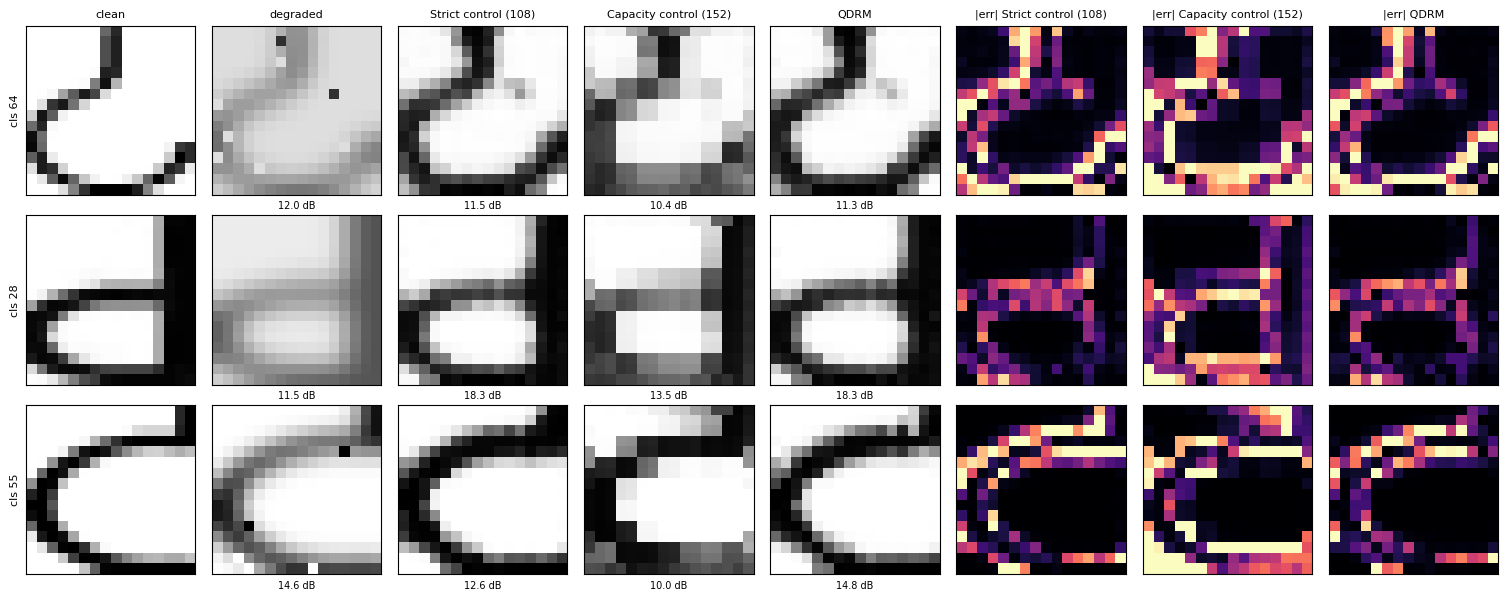

In [22]:
import matplotlib.pyplot as plt
S = PRIMARY_SEV
deg_te, gt_te, cls_te = load_pairs('test', S, 100.0, SEED)
sel, seen = [], set()
for i in range(len(cls_te)):
    if cls_te[i] not in seen:
        sel.append(i); seen.add(cls_te[i])
    if len(sel) == 3: break

def _psnr1(a, b):
    return 10 * torch.log10(1.0 / (((a - b) ** 2).mean() + 1e-12)).item()

models = [('Strict control (108)', get_mods('iso4', S, 0)),
          ('Capacity control (152)', get_mods('classical', S, 0)),
          ('QDRM', get_mods('qdrm', S, 0))]

cols = ['clean', 'degraded'] + [n for n, _ in models] + [f'|err| {n}' for n, _ in models]
fig, axes = plt.subplots(len(sel), len(cols), figsize=(1.9 * len(cols), 2.0 * len(sel)))
for r, i in enumerate(sel):
    with torch.no_grad():
        outs = [qdrm_restore(m, deg_te[i:i+1])[0] for _, m in models]
    panels = ([(gt_te[i], None, 'gray'), (deg_te[i], _psnr1(deg_te[i], gt_te[i]), 'gray')]
              + [(o, _psnr1(o, gt_te[i]), 'gray') for o in outs]
              + [((o - gt_te[i]).abs(), None, 'magma') for o in outs])
    for c, (im, ps, cmap) in enumerate(panels):
        vmax = 1 if cmap == 'gray' else 0.5
        axes[r, c].imshow(im.cpu(), cmap=cmap, vmin=0, vmax=vmax, interpolation='nearest')
        if ps is not None:
            axes[r, c].set_xlabel(f'{ps:.1f} dB', fontsize=7)
    axes[r, 0].set_ylabel(f'cls {cls_te[sel[r]]}', fontsize=8)
for c, t in enumerate(cols):
    axes[0, c].set_title(t, fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
_png = f'{RES_DIR}/fig_qual_errormaps.png'
plt.savefig(_png, dpi=300, bbox_inches='tight')
if globals().get('dfs'):
    try: dfs.upload(_png)
    except Exception as e: print(f'[drive sync failed: {type(e).__name__}]')
plt.show(); plt.close(fig)

## 9. Qualitative restoration comparison across different severities

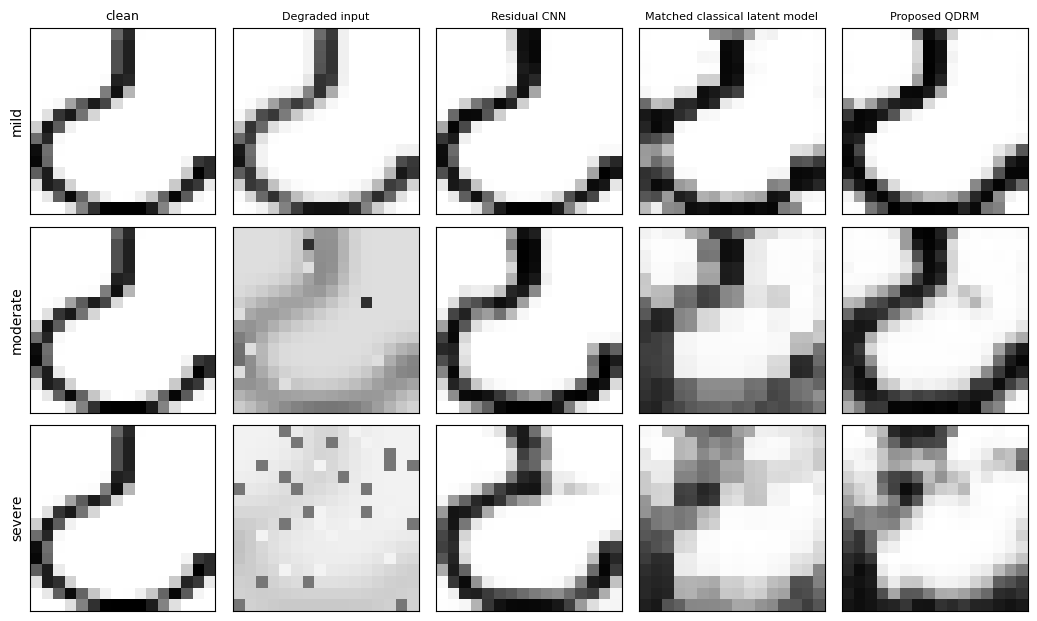

In [23]:
import matplotlib.pyplot as plt
SEV = PRIMARY_SEV
show = ['Degraded input', 'Residual CNN', 'Matched classical latent model', METHOD_Q]
fig, axes = plt.subplots(len(SEVERITIES), len(show)+1,
                         figsize=(2.1*(len(show)+1), 2.1*len(SEVERITIES)))
for i, s in enumerate(SEVERITIES):
    d = results[s]['_data']
    axes[i, 0].imshow(d['gt'][0], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_ylabel(s)
    if i == 0:
        axes[i, 0].set_title('clean', fontsize=9)
    for j, n in enumerate(show):
        img = d['deg'][0] if n == 'Degraded input' else results[s][n][0]['rest_sample'][0]
        axes[i, j+1].imshow(img, cmap='gray', vmin=0, vmax=1)
        if i == 0:
            axes[i, j+1].set_title(n, fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig3_qualitative.png', dpi=140); plt.show()

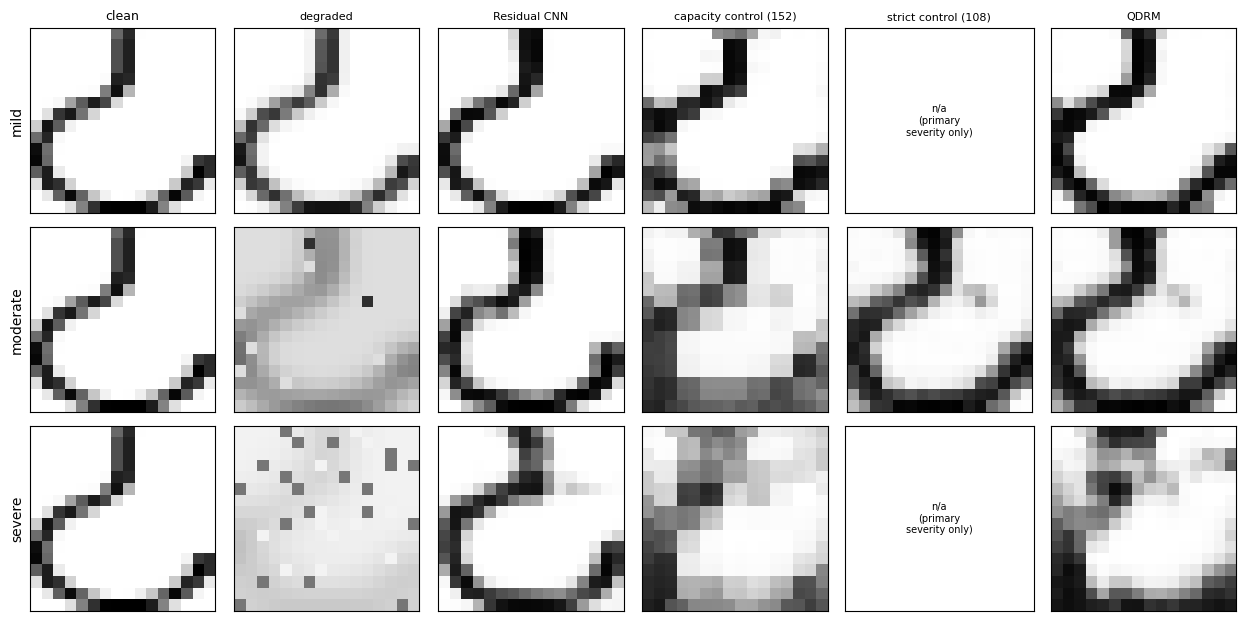

In [24]:
import matplotlib.pyplot as plt
SEV = PRIMARY_SEV
show = ['Degraded input', 'Residual CNN', 'Matched classical latent model',
        'Strict matched control (108)', METHOD_Q]
titles = ['degraded', 'Residual CNN', 'capacity control (152)',
          'strict control (108)', 'QDRM']
fig, axes = plt.subplots(len(SEVERITIES), len(show)+1,
                         figsize=(2.1*(len(show)+1), 2.1*len(SEVERITIES)))
for i, s in enumerate(SEVERITIES):
    d = results[s]['_data']
    axes[i, 0].imshow(d['gt'][0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[i, 0].set_ylabel(s)
    if i == 0:
        axes[i, 0].set_title('clean', fontsize=9)
    for j, n in enumerate(show):
        ax = axes[i, j+1]
        if n == 'Degraded input':
            img = d['deg'][0]
        elif results[s].get(n) and 'rest_sample' in results[s][n][0]:
            img = results[s][n][0]['rest_sample'][0]
        else:                                  # iso controls: primary severity only
            ax.text(0.5, 0.5, 'n/a\n(primary\nseverity only)', ha='center',
                    va='center', fontsize=7, transform=ax.transAxes)
            img = None
        if img is not None:
            ax.imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        if i == 0:
            ax.set_title(titles[j], fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{RES_DIR}/fig3_qualitative.png', dpi=300, bbox_inches='tight'); plt.show()

## 10. Quantitative comparison charts with metrics

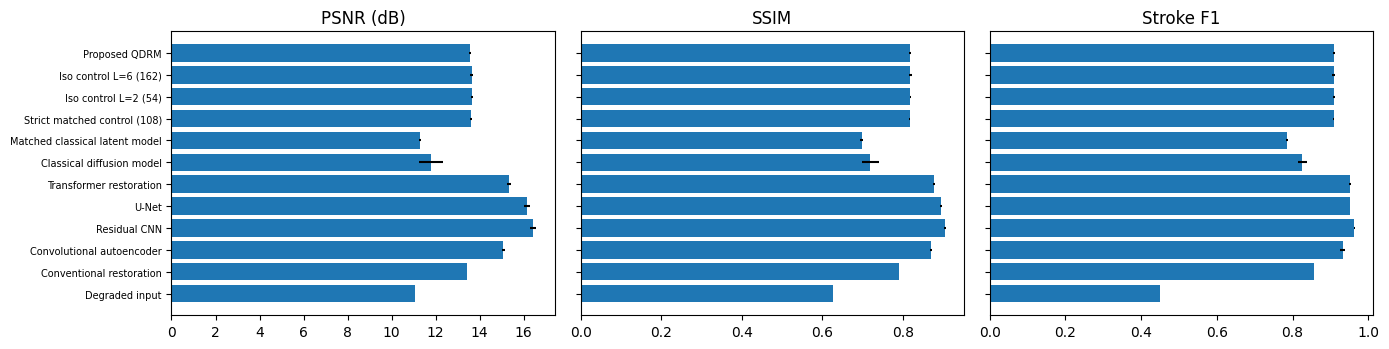

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for k, (key, ttl) in enumerate([('psnr', 'PSNR (dB)'), ('ssim', 'SSIM'),
                                ('f1', 'Stroke F1')]):
    means = [np.mean([np.mean(r[key]) for r in results[SEV][n]]) for n in ALL_METHODS]
    errs  = [np.std([np.mean(r[key]) for r in results[SEV][n]]) for n in ALL_METHODS]
    ax[k].barh(range(len(ALL_METHODS)), means, xerr=errs)
    ax[k].set_yticks(range(len(ALL_METHODS)))
    ax[k].set_yticklabels(ALL_METHODS if k == 0 else ['']*len(ALL_METHODS), fontsize=7)
    ax[k].set_title(ttl)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig5_bars.png', dpi=140); plt.show()

## 11. Performance across degradation of different severities

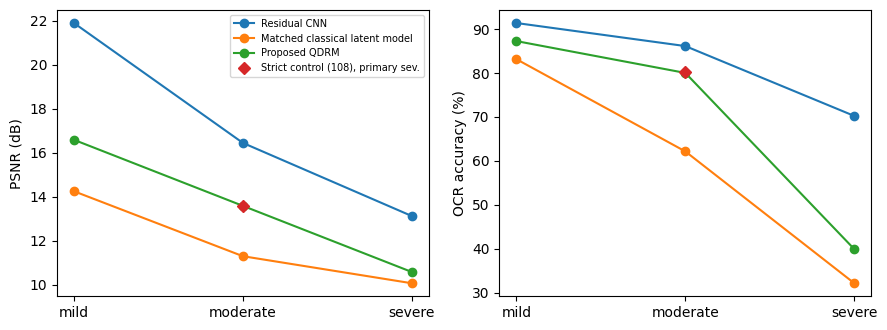

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for n, c in [('Residual CNN', 'tab:blue'),
             ('Matched classical latent model', 'tab:orange'),
             (METHOD_Q, 'tab:green')]:
    ax[0].plot(SEVERITIES, [np.mean([np.mean(r['psnr']) for r in results[s][n]])
                            for s in SEVERITIES], 'o-', label=n, color=c)
    ax[1].plot(SEVERITIES, [np.mean([r['acc'] for r in results[s][n]])
                            for s in SEVERITIES], 'o-', label=n, color=c)
_c108 = results[PRIMARY_SEV].get('Strict matched control (108)')
if _c108:                                   # primary severity only: single marker
    ax[0].plot([PRIMARY_SEV], [np.mean([np.mean(r['psnr']) for r in _c108])],
               'D', color='tab:red', label='Strict control (108), primary sev.')
    ax[1].plot([PRIMARY_SEV], [np.mean([r['acc'] for r in _c108])], 'D', color='tab:red')
ax[0].set_ylabel('PSNR (dB)'); ax[1].set_ylabel('OCR accuracy (%)')
ax[0].legend(fontsize=7)
plt.tight_layout()
plt.savefig(f'{RES_DIR}/fig6_severity.png', dpi=300, bbox_inches='tight'); plt.show()

## 12. Skeleton and topology comparison

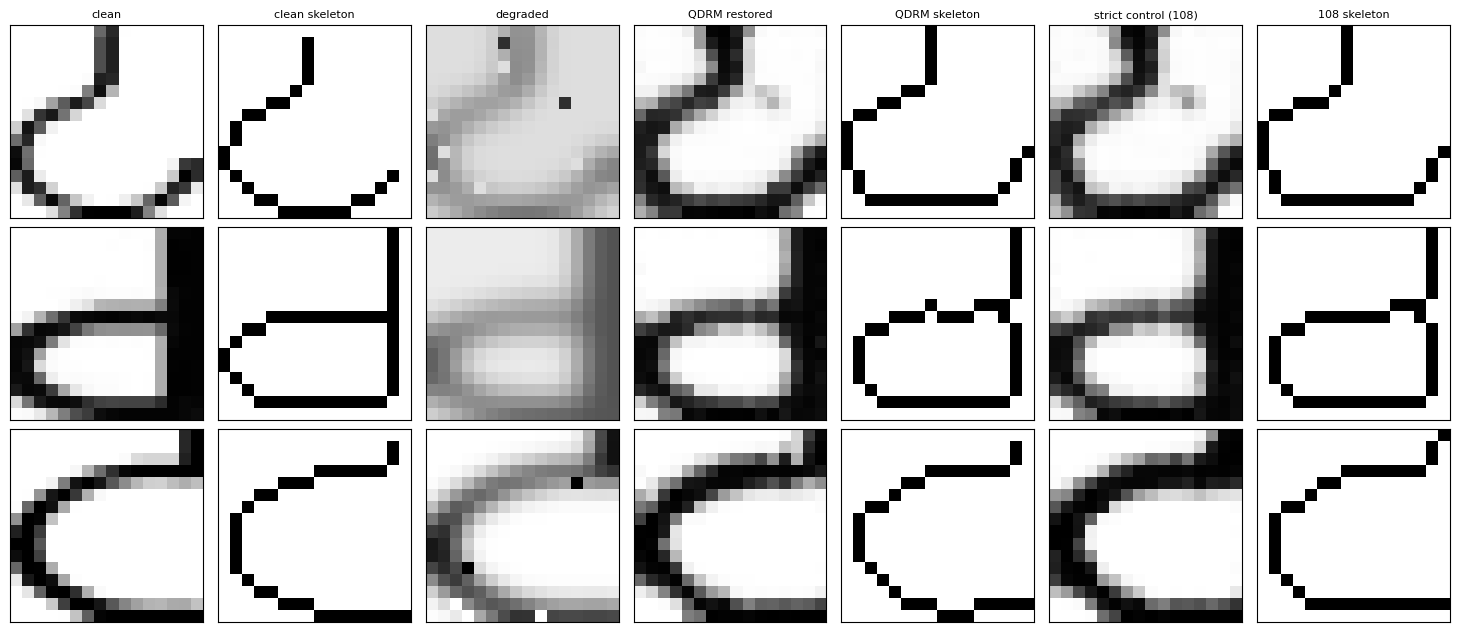

In [27]:
from skimage.morphology import skeletonize
d = results[SEV]['_data']
qs = results[SEV][METHOD_Q][0]['rest_sample']
_c108 = results[SEV].get('Strict matched control (108)')
cs = _c108[0]['rest_sample'] if _c108 else None

def _skel(t):                      # dark skeleton on white, same polarity as glyphs
    return 1.0 - skeletonize(np.asarray(t.cpu(), dtype=float) < 0.5).astype(float)

cols = ['clean', 'clean skeleton', 'degraded', 'QDRM restored', 'QDRM skeleton']
if cs is not None:
    cols += ['strict control (108)', '108 skeleton']
fig, axes = plt.subplots(3, len(cols), figsize=(2.1 * len(cols), 6.4))
for i in range(3):
    imgs = [d['gt'][i], _skel(d['gt'][i]), d['deg'][i], qs[i], _skel(qs[i])]
    if cs is not None:
        imgs += [cs[i], _skel(cs[i])]
    for j, im in enumerate(imgs):
        axes[i, j].imshow(np.asarray(im.cpu() if hasattr(im, 'cpu') else im, dtype=float),
                          cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        if i == 0:
            axes[i, j].set_title(cols[j], fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{RES_DIR}/fig7_skeletons.png', dpi=300, bbox_inches='tight'); plt.show()

## 13. Normalized recognition confusion matrix

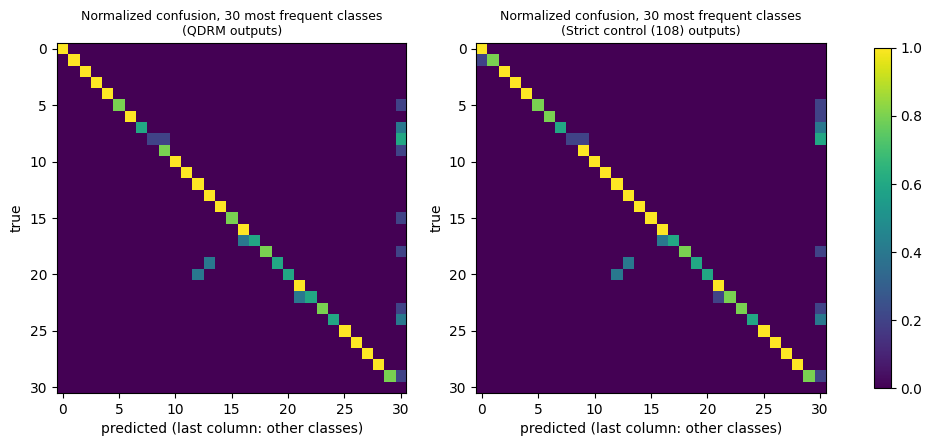

In [28]:
from sklearn.metrics import confusion_matrix
d = results[SEV]['_data']; y = np.asarray(d['y_te'].cpu())
top = np.argsort(np.bincount(y))[-30:]
mask = np.isin(y, top)
OTHER = int(y.max()) + 1
def _cm(pred):
    p = np.asarray(pred.cpu() if hasattr(pred, 'cpu') else pred).reshape(-1)
    n_rep = len(p) // len(y)
    if n_rep < 1 or n_rep * len(y) != len(p):
        raise ValueError(f'pred length {len(p)} incompatible with {len(y)} labels')
    yy = np.tile(y, n_rep); mm = np.tile(mask, n_rep)
    p = p.copy(); p[~np.isin(p, top)] = OTHER
    return confusion_matrix(yy[mm], p[mm], labels=list(top) + [OTHER], normalize='true')
panels = [('QDRM outputs', results[SEV][METHOD_Q][0]['pred'])]
_c108 = results[SEV].get('Strict matched control (108)')
if _c108 and 'pred' in _c108[0]:
    panels.append(('Strict control (108) outputs', _c108[0]['pred']))
fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 5.2), squeeze=False)
im = None
for ax, (ttl, pred) in zip(axes[0], panels):
    try:
        im = ax.imshow(_cm(pred), cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Normalized confusion, 30 most frequent classes\n({ttl})', fontsize=9)
        ax.set_xlabel('predicted (last column: other classes)'); ax.set_ylabel('true')
    except Exception as e:
        ax.text(0.5, 0.5, f'{ttl}\nunavailable ({type(e).__name__})', ha='center',
                va='center', fontsize=8, transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([]); print(f'[fig8] {ttl}: {e}')
if im is not None:
    fig.colorbar(im, ax=axes[0].tolist(), shrink=0.85)
plt.savefig(f'{RES_DIR}/fig8_confusion.png', dpi=300, bbox_inches='tight'); plt.show()


## 14. Ablation study

In [29]:
ABLATIONS = [('Without MPS contextual encoding', {'mps': False}),
             ('Without degradation conditioning', {'cond': False}),
             ('Without entangling gates (separable PQC)', {'entangle': False}),
             ('Without Hamiltonian-energy loss', {'ham': False}),
             ('Without gradient and curvature losses', {'gradcurv': False}),
             ('Without latent alignment', {'latent': False}),
             ('Without overlap consistency', {'overlap': False}),
             ('Single reverse step', {'multistep': False}),
             ('Uniform patch averaging', {'hann': False}),
             ('Without forward-diffusion supervision', {'fwd_sup': False})]
deg_tr, gt_tr, _ = load_pairs('train', SEV, PCT, SEED)
deg_te, gt_te, cls_te = load_pairs('test', SEV, 100.0, SEED)
y_te = torch.tensor([lab2idx[c] for c in cls_te], device=DEVICE)
AB_SEEDS = R_RUNS   # seeded ablations, mean +- std over R runs (Ref. 1-2)
ab_rows, ab_psnr, ab_labels = [], [], []
for label, fl in ABLATIONS:
    ms = []
    for sd_a in range(AB_SEEDS):
        print(f'[ablation] {label} (seed {sd_a + 1}/{AB_SEEDS})', flush=True)
        try:
            mods_a = qdrm_fit(deg_tr, gt_tr, SEV, flags=fl, seed=sd_a)
            out = qdrm_restore(mods_a, deg_te)
            ms.append(full_metrics(out, gt_te, deg_te, clf, y_te))
        except Exception as e:
            print(f'  [!] configuration failed ({type(e).__name__}: {str(e)[:100]}) '
                  '-> run excluded', flush=True)
    if not ms:
        continue
    P_ = [np.mean(m['psnr']) for m in ms]; S_ = [np.mean(m['ssim']) for m in ms]
    F_ = [np.mean(m['f1']) for m in ms]; Tp = [np.mean(m['topo']) for m in ms]
    A_ = [m['acc'] for m in ms]
    ab_rows.append([label, mstd(P_), mstd(S_, 4), mstd(F_, 4), mstd(Tp, 4), mstd(A_)])
    ab_psnr.append(float(np.mean(P_))); ab_labels.append(label)
def _res_row(label, key):
    runs = results[SEV].get(key, [])
    if not runs:
        return None
    P_ = [np.mean(m['psnr']) for m in runs]; S_ = [np.mean(m['ssim']) for m in runs]
    F_ = [np.mean(m['f1']) for m in runs]; Tp = [np.mean(m['topo']) for m in runs]
    A_ = [m['acc'] for m in runs]
    return [label, mstd(P_), mstd(S_, 4), mstd(F_, 4), mstd(Tp, 4), mstd(A_)]
for lbl, key in [('Matched classical control (152)', 'Matched classical latent model'),
                 ('Strict matched control (108)', 'Strict matched control (108)'),
                 ('Complete QDRM', METHOD_Q)]:
    r_ = _res_row(lbl, key)
    if r_ is not None:
        ab_rows.append(r_)
t5 = emit_table(ab_rows, ['Configuration', 'PSNR', 'SSIM', 'Stroke F1',
                          'Topology Err', 'OCR Acc (%)'],
                f'{RES_DIR}/table5_ablation.csv', 'Table V — ablations')

[ablation] Without MPS contextual encoding (seed 1/3)
[ablation] Without MPS contextual encoding (seed 2/3)
[ablation] Without MPS contextual encoding (seed 3/3)
[ablation] Without degradation conditioning (seed 1/3)
[ablation] Without degradation conditioning (seed 2/3)
[ablation] Without degradation conditioning (seed 3/3)
[ablation] Without entangling gates (separable PQC) (seed 1/3)
[ablation] Without entangling gates (separable PQC) (seed 2/3)
[ablation] Without entangling gates (separable PQC) (seed 3/3)
[ablation] Without Hamiltonian-energy loss (seed 1/3)
[ablation] Without Hamiltonian-energy loss (seed 2/3)
[ablation] Without Hamiltonian-energy loss (seed 3/3)
[ablation] Without gradient and curvature losses (seed 1/3)
[ablation] Without gradient and curvature losses (seed 2/3)
[ablation] Without gradient and curvature losses (seed 3/3)
[ablation] Without latent alignment (seed 1/3)
[ablation] Without latent alignment (seed 2/3)
[ablation] Without latent alignment (seed 3/3)
[

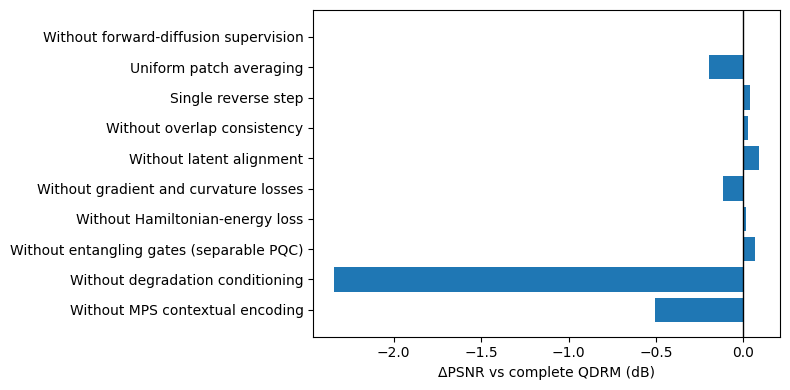

In [30]:
plt.figure(figsize=(8, 4))
_mq_psnr = float(np.mean([np.mean(m['psnr']) for m in results[SEV][METHOD_Q]]))
plt.barh(ab_labels, np.array(ab_psnr) - _mq_psnr)
plt.axvline(0, color='k', lw=1)
plt.xlabel('ΔPSNR vs complete QDRM (dB)')
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig9_ablation.png', dpi=140); plt.show()

In [31]:
# Sensitivity to the diffusion horizon T and forward-noise strength
# (Referee comment 2)

SENS = ([('T', v, {'T_override': v}) for v in (1, 2, 3, 4)]
        + [('eta_scale', v, {'eta_scale': v}) for v in (0.5, 2.0)])
sens_rows = []
for kind, val, fl in SENS:
    ms = []
    for sd_a in range(R_RUNS):
        print(f'[sensitivity] {kind}={val} (seed {sd_a + 1}/{R_RUNS})', flush=True)
        mods_s = qdrm_fit(deg_tr, gt_tr, SEV, flags=fl, seed=sd_a)
        out = qdrm_restore(mods_s, deg_te)
        ms.append(full_metrics(out, gt_te, deg_te, clf, y_te))
    P_ = [np.mean(m['psnr']) for m in ms]; F_ = [np.mean(m['f1']) for m in ms]
    A_ = [m['acc'] for m in ms]
    sens_rows.append([kind, val, mstd(P_), mstd(F_, 4), mstd(A_)])
emit_table(sens_rows, ['Sweep', 'Value', 'PSNR', 'Stroke F1', 'OCR Acc (%)'],
           f'{RES_DIR}/table_sensitivity.csv',
           'Diffusion horizon and noise-strength sensitivity (complete QDRM)')
print('note: eta_scale=1.0 and T=2 correspond to the complete model of Table I.')


[sensitivity] T=1 (seed 1/3)
[sensitivity] T=1 (seed 2/3)
[sensitivity] T=1 (seed 3/3)
[sensitivity] T=2 (seed 1/3)
[sensitivity] T=2 (seed 2/3)
[sensitivity] T=2 (seed 3/3)
[sensitivity] T=3 (seed 1/3)
[sensitivity] T=3 (seed 2/3)
[sensitivity] T=3 (seed 3/3)
[sensitivity] T=4 (seed 1/3)
[sensitivity] T=4 (seed 2/3)
[sensitivity] T=4 (seed 3/3)
[sensitivity] eta_scale=0.5 (seed 1/3)
[sensitivity] eta_scale=0.5 (seed 2/3)
[sensitivity] eta_scale=0.5 (seed 3/3)
[sensitivity] eta_scale=2.0 (seed 1/3)
[sensitivity] eta_scale=2.0 (seed 2/3)
[sensitivity] eta_scale=2.0 (seed 3/3)

=== Diffusion horizon and noise-strength sensitivity (complete QDRM) -> /root/qdrm_results/table_sensitivity.csv ===
    Sweep  Value         PSNR       Stroke F1  OCR Acc (%)
        T    1.0 13.62 ± 0.01 0.9114 ± 0.0007 80.00 ± 0.75
        T    2.0 13.58 ± 0.05 0.9105 ± 0.0028 80.04 ± 0.53
        T    3.0 13.58 ± 0.07 0.9117 ± 0.0012 79.96 ± 0.36
        T    4.0 13.59 ± 0.03 0.9126 ± 0.0002 80.04 ± 0.59
eta_s

In [32]:
# Test-set degradation-realization variance (Referee comment 3)
real_rows = []
deg_stats = []
for r_i in range(K_TEST_REALIZATIONS):
    deg_r, gt_r, cls_r = load_pairs('test', PRIMARY_SEV, 100.0, SEED, realization=r_i)
    ps = 10 * torch.log10(1.0 / (((deg_r - gt_r) ** 2).mean(dim=(1, 2)) + 1e-12))
    deg_stats.append(float(ps.mean()))
real_rows.append(['Degraded input', mstd(deg_stats), '-', '-'])
for tag, label in [('qdrm', 'Proposed QDRM'),
                   ('classical', 'Matched classical control (152)'),
                   ('iso4', 'Strict matched control (108)')]:
    mods_r = mods_cache.get((tag, PRIMARY_SEV, 0))
    if mods_r is None:
        print(f'[realizations] no cached model for {label} -> run the driver cell first')
        continue
    P_, F_, A_ = [], [], []
    for r_i in range(K_TEST_REALIZATIONS):
        deg_r, gt_r, cls_r = load_pairs('test', PRIMARY_SEV, 100.0, SEED, realization=r_i)
        y_r = torch.tensor([lab2idx[c] for c in cls_r], device=DEVICE)
        out = qdrm_restore(mods_r, deg_r)
        m = full_metrics(out, gt_r, deg_r, clf, y_r)
        P_.append(np.mean(m['psnr'])); F_.append(np.mean(m['f1'])); A_.append(m['acc'])
    real_rows.append([label, mstd(P_), mstd(F_, 4), mstd(A_)])
emit_table(real_rows, ['Method', 'PSNR (mean +- std over realizations)',
                       'Stroke F1', 'OCR Acc (%)'],
           f'{RES_DIR}/table_realizations.csv',
           'Variance over K test degradation realizations (identical models)')



=== Variance over K test degradation realizations (identical models) -> /root/qdrm_results/table_realizations.csv ===
                         Method PSNR (mean +- std over realizations)       Stroke F1  OCR Acc (%)
                 Degraded input                         11.05 ± 0.02               -            -
                  Proposed QDRM                         13.60 ± 0.03 0.9153 ± 0.0011 80.24 ± 0.67
Matched classical control (152)                         11.29 ± 0.02 0.7823 ± 0.0021 59.29 ± 1.80
   Strict matched control (108)                         13.59 ± 0.04 0.9081 ± 0.0018 79.65 ± 0.93


,Method,PSNR (mean +- std over realizations),Stroke F1,OCR Acc (%)
0,Degraded input,11.05 ± 0.02,-,-
1,Proposed QDRM,13.60 ± 0.03,0.9153 ± 0.0011,80.24 ± 0.67
2,Matched classical control (152),11.29 ± 0.02,0.7823 ± 0.0021,59.29 ± 1.80
3,Strict matched control (108),13.59 ± 0.04,0.9081 ± 0.0018,79.65 ± 0.93


In [33]:
# Unseen-degradation generalization (Referee comment 3)

def _degrade_batch(gt_b, sev_name, rng_seed, order=None, disable=None, blend=None):
    outs = []
    for i in range(len(gt_b)):
        x = gt_b[i].cpu().numpy()
        rng = np.random.default_rng(rng_seed * 1_000_003 + i * 101)
        y, _ = degrade(x, sev_name, rng, order=order, disable=disable, blend=blend)
        outs.append(y)
    return torch.tensor(np.stack(outs), dtype=torch.float32).to(DEVICE)

UNSEEN = [
    ('Reversed composition order', dict(order=list(reversed(ORDER)))),
    ('Blur last (moved from first)', dict(order=[o for o in ORDER if o != 'blur'] + ['blur'])),
    ('No fade (operator subset)', dict(disable=['fade'])),
    ('Interpolated severity (mild~moderate)', dict(blend=('mild', 'moderate', 0.5))),
    ('Extrapolated severity (1.25 x severe)', dict(blend=('severe', 'severe', 1.25))),
]
MODELS_U = [('QDRM', mods_cache.get(('qdrm', PRIMARY_SEV, 0))),
            ('Control-108', mods_cache.get(('iso4', PRIMARY_SEV, 0))),
            ('Control-152', mods_cache.get(('classical', PRIMARY_SEV, 0)))]
uns_rows = []
if MODELS_U[0][1] is None:
    print('[unseen] run the driver cell first (mods_cache empty)')
else:
    y_u = torch.tensor([lab2idx[c] for c in cls_te], device=DEVICE)
    for label, kw in UNSEEN:
        deg_u = _degrade_batch(gt_te, PRIMARY_SEV, SEED + 777, **kw).clamp(0, 1)
        row = [label]
        for _, mods_x in MODELS_U:
            if mods_x is None:
                row.append('-'); continue
            with torch.no_grad():
                out = qdrm_restore(mods_x, deg_u)
            m = full_metrics(out, gt_te, deg_u, clf, y_u)
            row.append(f"{np.mean(m['psnr']):.2f} / {m['acc']:.1f}")
        ps_d = 10 * torch.log10(1.0 / (((deg_u - gt_te) ** 2).mean() + 1e-12)).item()
        row.append(f'{ps_d:.2f}')
        uns_rows.append(row)
        print(f'[unseen] {label}: done', flush=True)
    emit_table(uns_rows, ['Held-out degradation setting',
                          'QDRM (PSNR / OCR)', 'Control-108 (PSNR / OCR)',
                          'Control-152 (PSNR / OCR)', 'Degraded-input PSNR'],
               f'{RES_DIR}/table_unseen.csv',
               'Generalization to unseen degradation settings (no retraining)')

[unseen] Reversed composition order: done
[unseen] Blur last (moved from first): done
[unseen] No fade (operator subset): done
[unseen] Interpolated severity (mild~moderate): done
[unseen] Extrapolated severity (1.25 x severe): done

=== Generalization to unseen degradation settings (no retraining) -> /root/qdrm_results/table_unseen.csv ===
         Held-out degradation setting QDRM (PSNR / OCR) Control-108 (PSNR / OCR) Control-152 (PSNR / OCR) Degraded-input PSNR
           Reversed composition order      12.31 / 52.7             12.26 / 51.1             10.61 / 37.9               10.02
         Blur last (moved from first)      12.34 / 52.7             12.29 / 50.9             10.64 / 38.4               10.01
            No fade (operator subset)      12.99 / 81.5             12.82 / 80.9             10.71 / 62.8               11.65
Interpolated severity (mild~moderate)      14.35 / 87.9             14.17 / 87.2             11.24 / 67.9               12.54
Extrapolated severity (1.25

## 15. Runtime comparison

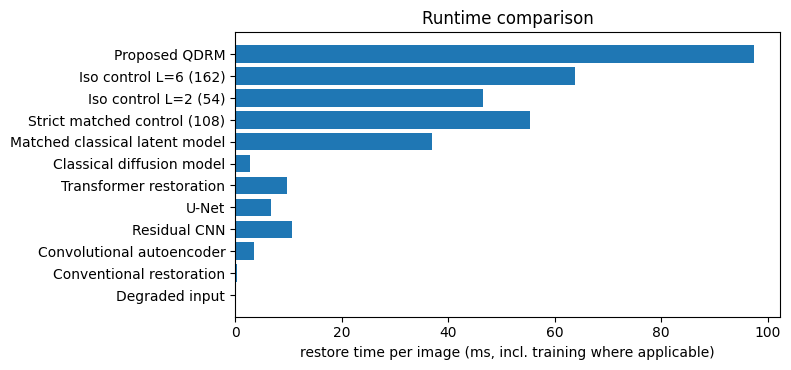

all figures saved to /root/qdrm_results


In [34]:
names = [n for n in ALL_METHODS if n in runtimes]
per_img = [np.mean([t/max(k, 1)*1000 for t, k in runtimes[n]]) for n in names]
plt.figure(figsize=(8, 3.8))
plt.barh(names, per_img)
plt.xlabel('restore time per image (ms, incl. training where applicable)')
plt.title('Runtime comparison')
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig11_runtime.png', dpi=140); plt.show()

print('all figures saved to', RES_DIR)

## 16. Real-QPU execution of the QDRM reverse operator (ibm_kingston)

In [ ]:
import numpy as np, torch, matplotlib.pyplot as plt
import subprocess, sys
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter

def draw_mpl(circ, path, fold):
    """Save a matplotlib circuit drawing."""
    try:
        try:
            fig = circ.draw('mpl', fold=fold, idle_wires=False)
        except Exception:
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                            'pylatexenc'], check=True)
            fig = circ.draw('mpl', fold=fold, idle_wires=False)
        fig.savefig(path, dpi=140, bbox_inches='tight'); plt.show()
        print('saved', path)
    except Exception as e:
        print(f'[mpl drawing skipped: {type(e).__name__}] text diagram above is '
              'authoritative; install pylatexenc and re-run to get the figure')

IBM_API_KEY = 'PASTE_API_KEY'
IBM_CRN     = 'PASTE_INSTANCE_CRN'

BACKEND     = 'ibm_kingston'
N_IMG_QPU   = 8                             
                                             # same n=8 images (Referee comment 3)
SHOTS       = 2048

SUBMIT_TO_QPU = False
assert SUBMIT_TO_QPU, ('Set SUBMIT_TO_QPU = True only to repeat the hardware '
                       'experiment; the recorded outputs below and the '
                       'server-retained jobs above are the results of record.')

ckpt_path = f'{RES_DIR}/ckpt_qdrm_{PRIMARY_SEV}_0.pt'
FORCE_RETRAIN = False        # True -> retrain even if a checkpoint exists,
                             # reproducing the full epoch-wise log below
if FORCE_RETRAIN or not os.path.exists(ckpt_path):
    print('training QDRM (simulation, FastPQC) with epoch-wise train/test metrics')
    deg_tr, gt_tr, _ = load_pairs('train', PRIMARY_SEV, PCT, SEED)
    deg_ev, gt_ev, _ = load_pairs('test', PRIMARY_SEV, 20.0, SEED)

    def _psnr(a, b):
        return 10*torch.log10(1.0/(((a-b)**2).mean()+1e-12)).item()

    def cb(ep, tot, mods_p):
        otr = qdrm_restore(mods_p, deg_tr[:40])      # training-set metrics
        ote = qdrm_restore(mods_p, deg_ev[:40])      # test-set metrics
        print(f'  epoch {ep:3d}/{tot}  '
              f'train PSNR {_psnr(otr, gt_tr[:40]):5.2f} dB '
              f'SSIM {ssim(otr, gt_tr[:40]).item():.4f}  |  '
              f'test PSNR {_psnr(ote, gt_ev[:40]):5.2f} dB '
              f'SSIM {ssim(ote, gt_ev[:40]).item():.4f}', flush=True)
    mods = qdrm_fit(deg_tr, gt_tr, PRIMARY_SEV, seed=0, eval_cb=cb, log_every=5)
    torch.save({k: {kk: vv.cpu() for kk, vv in m.state_dict().items()}
                for k, m in mods.items() if hasattr(m, 'state_dict')}, ckpt_path)
    if dfs:
        try: dfs.upload(ckpt_path)
        except Exception as _e: print('[ckpt sync failed]', type(_e).__name__)
else:
    mods = rebuild_qdrm(ckpt_path, quantum=True)
    print('loaded trained checkpoint:', ckpt_path,
          '   (set FORCE_RETRAIN = True to reproduce the epoch-wise log)')
theta = mods['trans'].theta.detach().cpu().numpy()          # (L, nq, 3)

deg_pv, gt_pv, cls_pv = load_pairs('test', PRIMARY_SEV, 100.0, SEED)
with torch.no_grad():
    out_pv = qdrm_restore(mods, deg_pv[:6])
_ps = 10*torch.log10(1.0/(((out_pv-gt_pv[:6])**2).mean()+1e-12)).item()
print(f'simulation restore on 6 test characters: PSNR {_ps:.2f} dB, '
      f'SSIM {ssim(out_pv, gt_pv[:6]).item():.4f}')
fig, axes = plt.subplots(3, 6, figsize=(10.5, 5.4))
for j in range(6):
    for r, (im, lab) in enumerate([(gt_pv[j], 'clean'), (deg_pv[j], 'degraded'),
                                   (out_pv[j], 'restored (sim)')]):
        axes[r, j].imshow(im.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
        if j == 0: axes[r, j].set_ylabel(lab, fontsize=10)
    axes[0, j].set_title(f'class {cls_pv[j]}', fontsize=9)
plt.suptitle('Trained model — simulated restoration preview', y=0.99)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig_qpu_sim_preview.png', dpi=140)
plt.show()

# Qiskit circuit

Lq = mods['trans'].L
p_zc = [Parameter(f'zc{q}') for q in range(NQ)]
p_zd = [Parameter(f'zd{q}') for q in range(NQ)]
p_tau = [Parameter(f'tau{q}') for q in range(NQ)]
qc = QuantumCircuit(NQ, NQ)
for l in range(Lq):
    for q in range(NQ):                                     # encoding, Eq. (30)
        qc.ry(np.pi * p_zc[q], q)
        qc.rz(np.pi * p_zd[q], q)
        qc.ry(np.pi * p_tau[q], q)
    for q in range(NQ):                                     # variational, Eq. (31)
        qc.rz(float(theta[l, q, 0]), q)
        qc.rx(float(theta[l, q, 1]), q)
        qc.ry(float(theta[l, q, 2]), q)
    for (a, b) in EDGES:                                    # entangling, Eq. (32)
        qc.cx(a, b)
qc.measure(range(NQ), range(NQ))
print('\n--- logical circuit (Eqs. 30-33) ---')
print(qc.draw('text', fold=110))
draw_mpl(qc, f'{RES_DIR}/fig_qpu_circuit_logical.png', fold=28)

def counts_to_expectations(counts, shots=None):
    """<Z_q>, <Z_a Z_b> from one counts dict. Normalizes by the ACTUAL total
    count, so a shots mismatch can rescale nothing; `shots` kept for API
    compatibility and used only for a sanity warning."""
    ez = np.zeros(NQ); ezz = np.zeros(len(EDGES)); tot = 0
    for bits, c in counts.items():
        z = np.array([1.0 - 2.0*int(bits[NQ-1-q]) for q in range(NQ)])
        ez += c * z
        ezz += c * np.array([z[a]*z[b] for (a, b) in EDGES])
        tot += c
    if shots and abs(tot - shots) > 0.01 * shots:
        print(f'  [warn] counts total {tot} != nominal shots {shots} '
              f'(normalizing by {tot})')
    m = np.concatenate([ez, ezz]) / max(tot, 1)
    return np.clip(m, -1.0, 1.0)

def pub_counts(res, i):
    """Per-parameter-set counts from a SamplerV2 PUB result."""
    ba = res.data.c
    try:
        return ba.get_counts(i)
    except TypeError:
        pass
    from collections import Counter
    try:
        return dict(Counter(ba.get_bitstrings(i)))
    except TypeError:
        return dict(Counter(ba.get_bitstrings(loc=i)))

def batch_expectations(res, n_sets, shots):
    M = np.stack([counts_to_expectations(pub_counts(res, i), shots)
                  for i in range(n_sets)])
    spread = M.std(axis=0).mean()
    print(f'  m_hw stats: mean|m| {np.abs(M).mean():.3f}, max|m| '
          f'{np.abs(M).max():.3f}, across-set spread {spread:.4f}')
    assert spread > 1e-6, (
        'all parameter sets returned IDENTICAL expectations — counts were '
        'aggregated across the batch; per-set extraction failed')
    return torch.tensor(M, dtype=torch.float32, device=DEVICE)

# Transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
service = QiskitRuntimeService(channel='ibm_cloud', token=IBM_API_KEY,
                               instance=IBM_CRN)
backend = service.backend(BACKEND)
isa = transpile(qc, backend=backend, optimization_level=2)
ops = isa.count_ops()
print(f'\n--- transpiled for {BACKEND} ---')
print(f'logical:   depth {qc.depth():3d} | 2q gates {sum(1 for _ in EDGES)*Lq}')
print(f'hardware:  depth {isa.depth():3d} | ops {dict(ops)}')
draw_mpl(isa, f'{RES_DIR}/fig_qpu_circuit_transpiled.png', fold=40)
sampler = SamplerV2(mode=backend)

def run_qpu_step(z_cur, z_deg, tau):
    """One reverse step for a batch of patches: single PUB job, Eq. (36)."""
    vals = torch.cat([z_cur, z_deg, tau], dim=1).cpu().numpy()   # (N, 3nq)
    order = [p.name for p in isa.parameters]
    cols = {f'zc{q}': z_cur[:, q] for q in range(NQ)}
    cols.update({f'zd{q}': z_deg[:, q] for q in range(NQ)})
    cols.update({f'tau{q}': tau[:, q] for q in range(NQ)})
    pv = np.stack([cols[n].cpu().numpy() for n in order], axis=1)
    job = sampler.run([(isa, pv)], shots=SHOTS)
    print(f'  submitted job {job.job_id()} ({pv.shape[0]} parameter sets, '
          f'{SHOTS} shots) ...', flush=True)
    res = job.result()[0]
    return batch_expectations(res, pv.shape[0], SHOTS)

# Hardware reverse trajectory on the reduced subset

deg_te, gt_te, cls_te = load_pairs('test', PRIMARY_SEV, 100.0, SEED)
sub = slice(0, N_IMG_QPU)
db, gb = deg_te[sub], gt_te[sub]
Bm = db.shape[0]
enc, Pc, Pd, Pt, ro, dec = (mods[k] for k in ('enc', 'Pc', 'Pd', 'Pt', 'ro', 'dec'))
with torch.no_grad():
    z_deg = enc(patchify(db, g)).reshape(Bm*g.P, DZ)
    z_hw, z_id = z_deg.clone(), z_deg.clone()
    for t in range(T, 0, -1):
        tau = torch.full((Bm*g.P, 1), t/T, device=DEVICE)
        print(f'reverse step t={t}: executing on {BACKEND}')
        m_hw = run_qpu_step(Pc(z_hw), Pd(z_deg), Pt(tau))
        m_id = mods['q'](Pc(z_id), Pd(z_deg), Pt(tau))          # ideal reference
        dev = (m_hw - m_id).abs()
        print(f'  observable deviation |Delta m|: mean {dev.mean():.4f} '
              f'max {dev.max():.4f}   (Eq. 58 Delta_p analogue)')
        z_hw, z_id = ro(m_hw), ro(m_id)
        print(f'  z_hw after readout: mean {z_hw.mean():.3f} std {z_hw.std():.3f} '
              f'(ideal: mean {z_id.mean():.3f} std {z_id.std():.3f})')
    x_hw = hann_aggregate(dec(z_hw).reshape(Bm, g.P, -1), g).clamp(0, 1)
    x_id = hann_aggregate(dec(z_id).reshape(Bm, g.P, -1), g).clamp(0, 1)

# Metrics, images

def ps(x): return 10*torch.log10(1.0/(((x-gb)**2).mean()+1e-12)).item()
mm = results[PRIMARY_SEV]['Matched classical latent model'][0]
base = float(np.mean(mm['psnr'][:Bm]))
u_id, u_hw = ps(x_id) - base, ps(x_hw) - base
print('\n=== Table VII rows (reduced subset, per-image basis) ===')
print(f"{'mode':22s} {'patch':>6s} {'qubits':>7s} {'PSNR':>7s} {'SSIM':>7s} {'U-retention':>12s}")
print(f"{'Ideal simulation':22s} {g.h}x{g.w:>4d} {NQ:7d} {ps(x_id):7.2f} "
      f"{ssim(x_id, gb).item():7.4f} {'1.000':>12s}")
print(f"{'Real QPU ('+BACKEND+')':22s} {g.h}x{g.w:>4d} {NQ:7d} {ps(x_hw):7.2f} "
      f"{ssim(x_hw, gb).item():7.4f} "
      f"{(max(u_hw,0)/max(u_id,1e-6) if u_id>0 else float('nan')):12.3f}")

fig, axes = plt.subplots(4, Bm, figsize=(2.4*Bm, 9.2))
axes = np.atleast_2d(axes.reshape(4, Bm))
for j in range(Bm):
    for r, (im, lab) in enumerate([(gb[j], 'clean'), (db[j], 'degraded'),
                                   (x_id[j], 'ideal sim'),
                                   (x_hw[j], f'QPU {BACKEND}')]):
        axes[r, j].imshow(im.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
        if j == 0: axes[r, j].set_ylabel(lab, fontsize=10)
    axes[0, j].set_title(f'class {cls_te[j]}', fontsize=9)
plt.suptitle(f'Hardware restoration — {PRIMARY_SEV} severity, {SHOTS} shots', y=0.99)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/fig10_qpu_restoration.png', dpi=140)
plt.show()
print('figures saved to', RES_DIR)


#### Verbatim session console log (hardware session of record)
```
--- transpiled for ibm_kingston ---
logical:   depth  39 | 2q gates 32
hardware:  depth  88 | ops {'rz': 296, 'sx': 209, 'cz': 32, 'measure': 9, 'x': 6}
saved /root/qdrm_results/fig_qpu_circuit_transpiled.png
reverse step t=2: executing on ibm_kingston
  submitted job da4vvmuaa69c739k9pug (392 parameter sets, 2048 shots) ...
  m_hw stats: mean|m| 0.244, max|m| 0.816, across-set spread 0.1196
  observable deviation |Delta m|: mean 0.0387 max 0.1806   (Eq. 58 Delta_p analogue)
  z_hw after readout: mean 0.375 std 0.140 (ideal: mean 0.375 std 0.151)
reverse step t=1: executing on ibm_kingston
  submitted job da502g43jnrc73agnm90 (392 parameter sets, 2048 shots) ...
  m_hw stats: mean|m| 0.241, max|m| 0.802, across-set spread 0.1310
  observable deviation |Delta m|: mean 0.0444 max 0.1817   (Eq. 58 Delta_p analogue)
  z_hw after readout: mean 0.363 std 0.147 (ideal: mean 0.361 std 0.159)

=== Table IX rows (unified n=8 subset, per-image basis) ===
mode                     patch  qubits    PSNR    SSIM  U-retention
Ideal simulation         4x4        9    14.76  0.8759        1.000
Real QPU (ibm_kingston)  4x4        9    15.19  0.8739        1.185
```

#### Restoration grid produced by the session (manuscript Fig. `fig:hardware_restoration`)
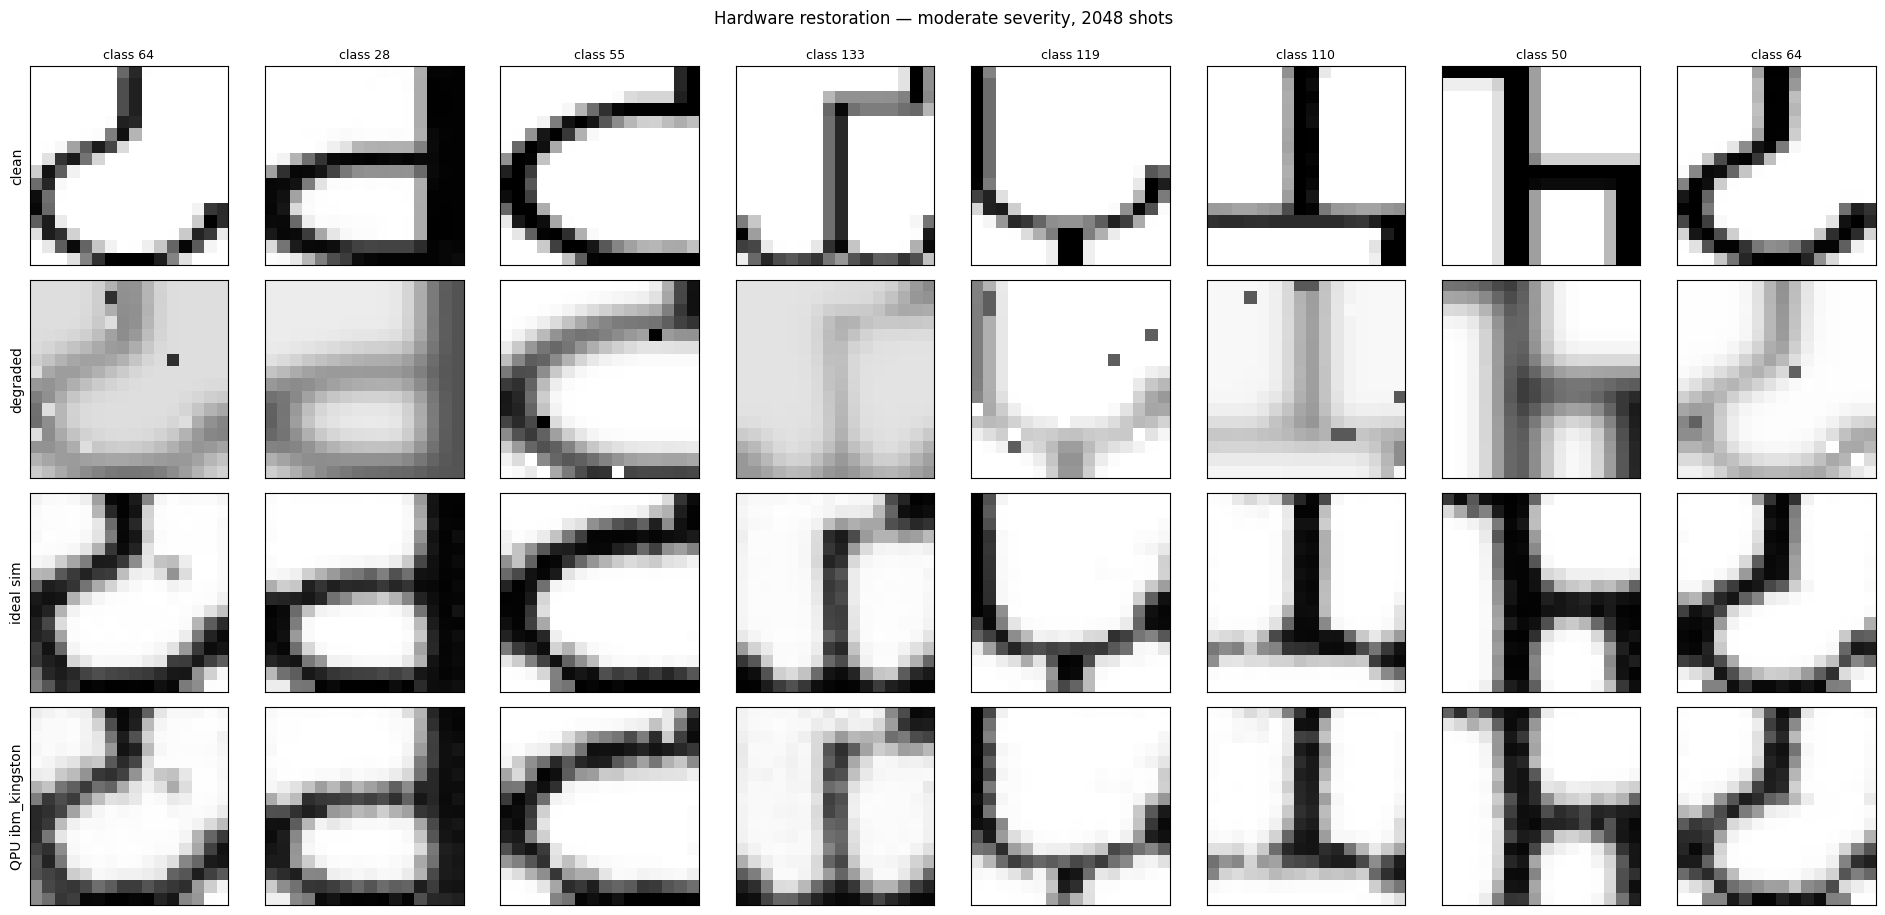


### 17. Quantum-circuit diagrams of the pipeline

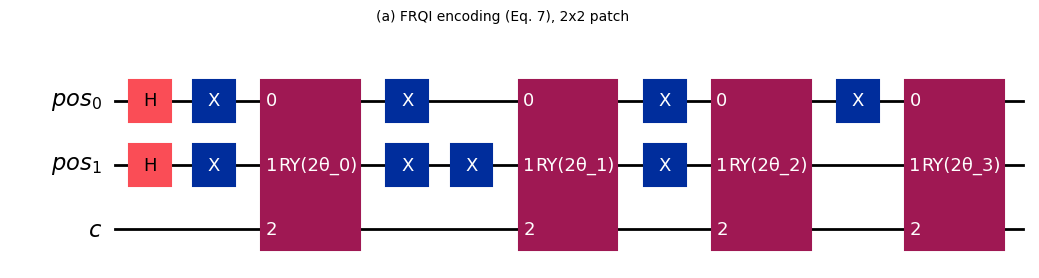

saved /root/qdrm_results/fig_circuit_frqi.png


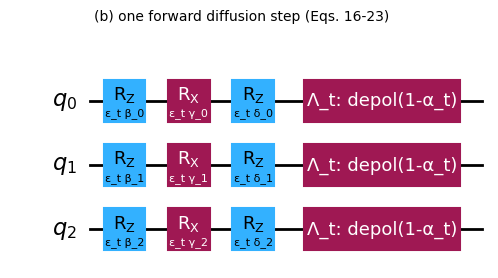

saved /root/qdrm_results/fig_circuit_forward.png


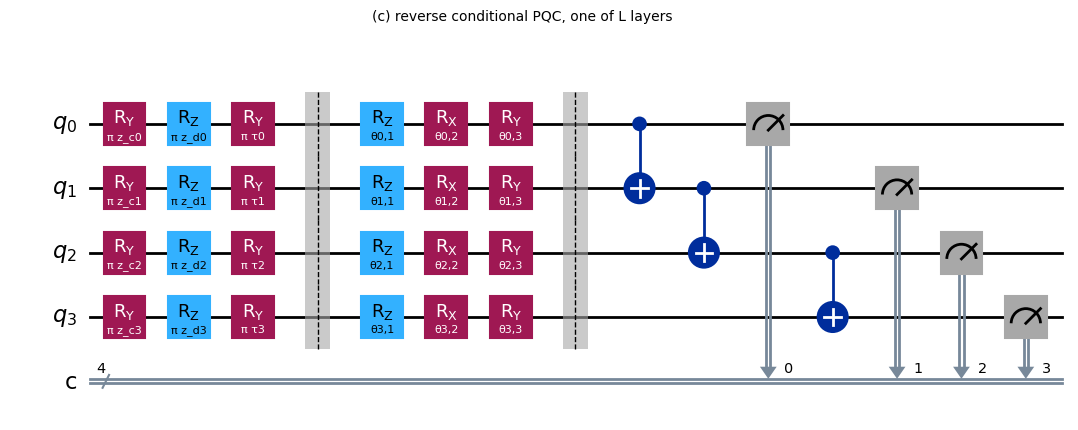

saved /root/qdrm_results/fig_circuit_reverse_pqc.png
(a-full) FRQI 4x4: 5 qubits, depth 44


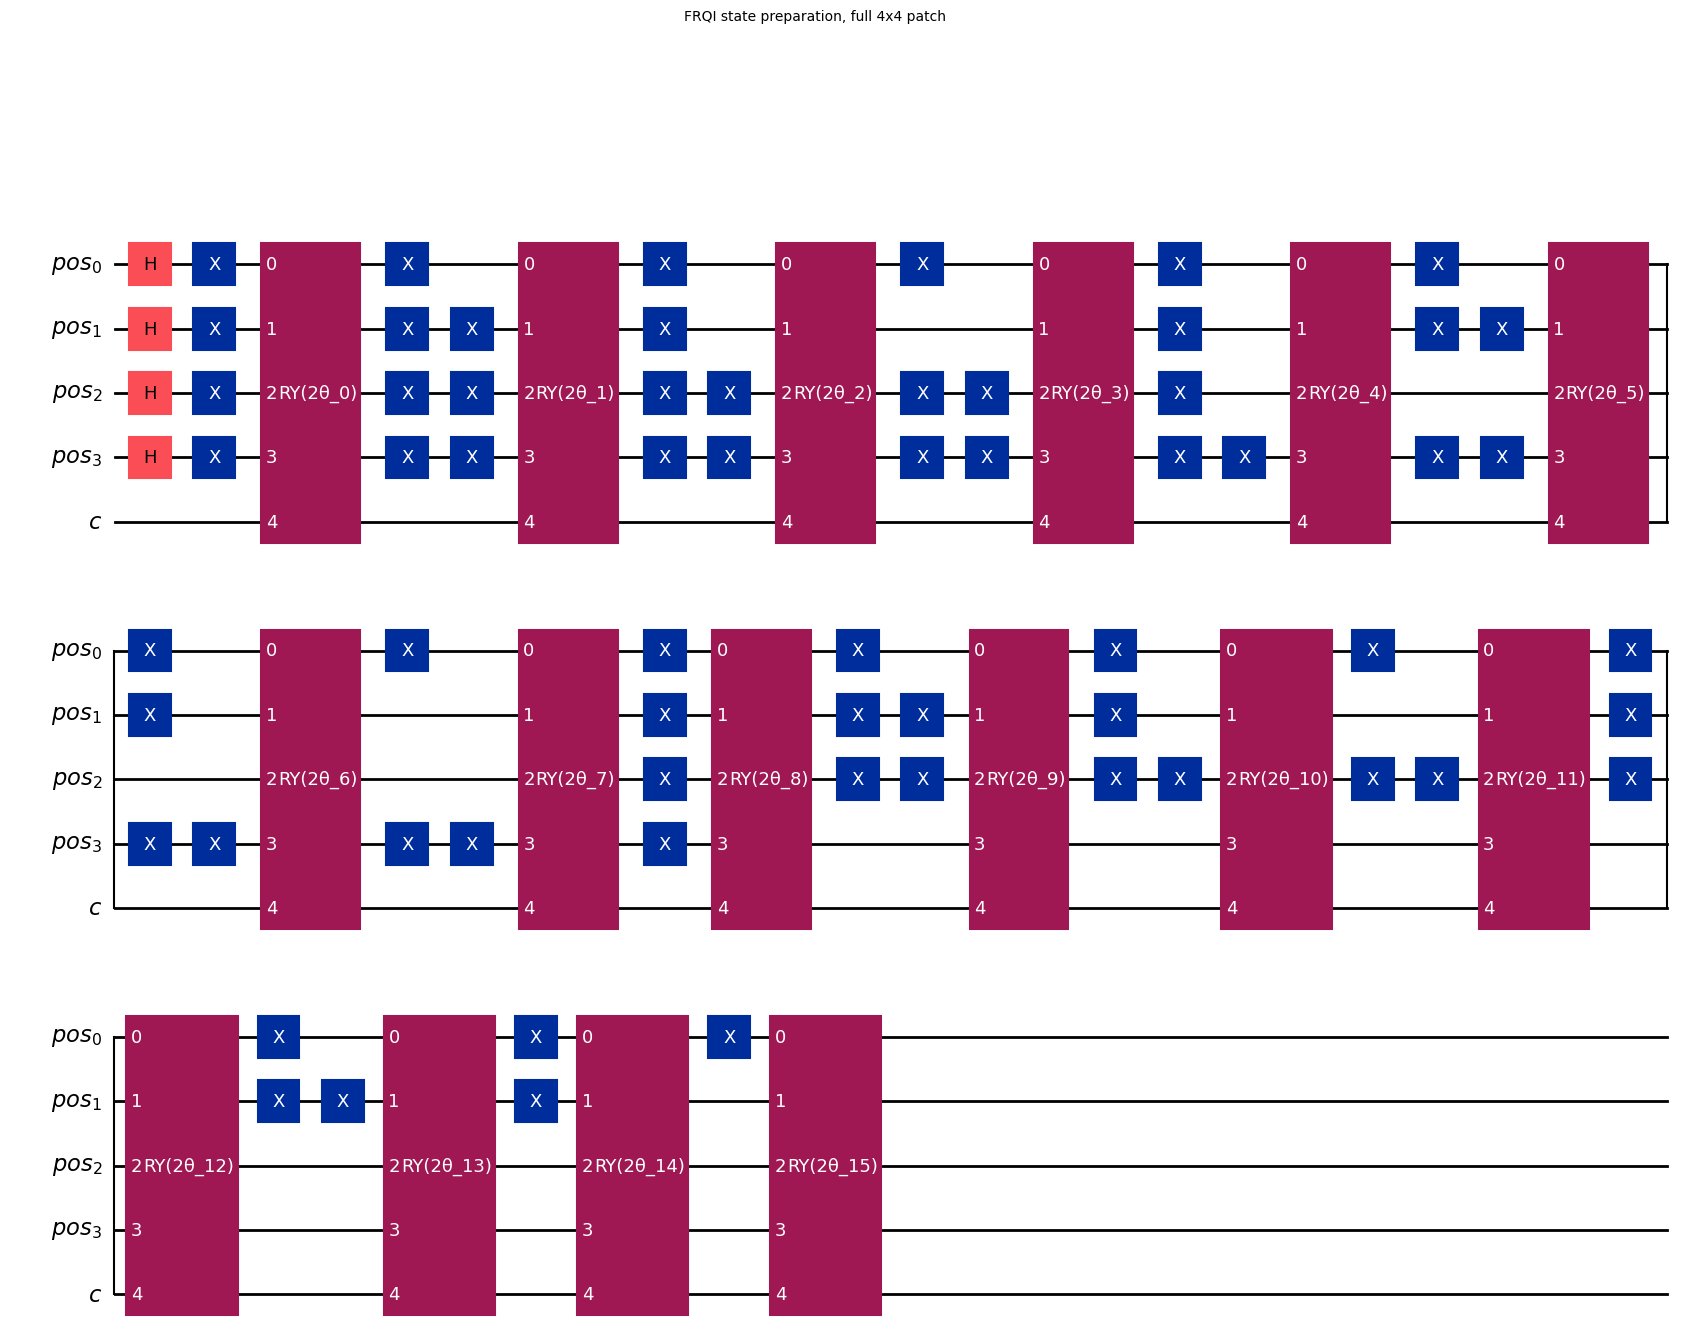

saved /root/qdrm_results/fig_circuit_frqi_full.png


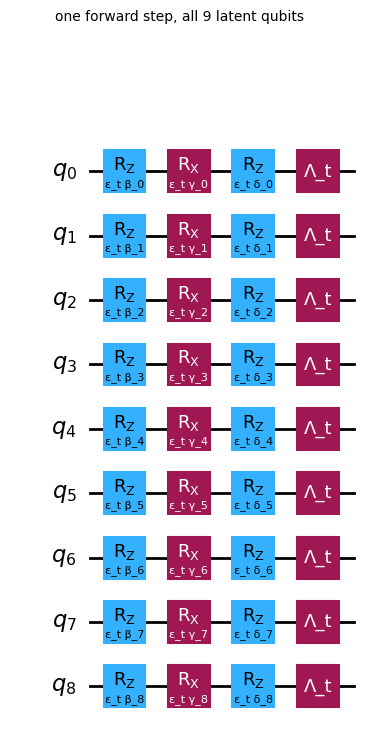

saved /root/qdrm_results/fig_circuit_forward_full.png
(c-full) reverse PQC: 9 qubits, L=4 layers, depth 57, 32 CNOTs — exactly the circuit trained and run on hardware


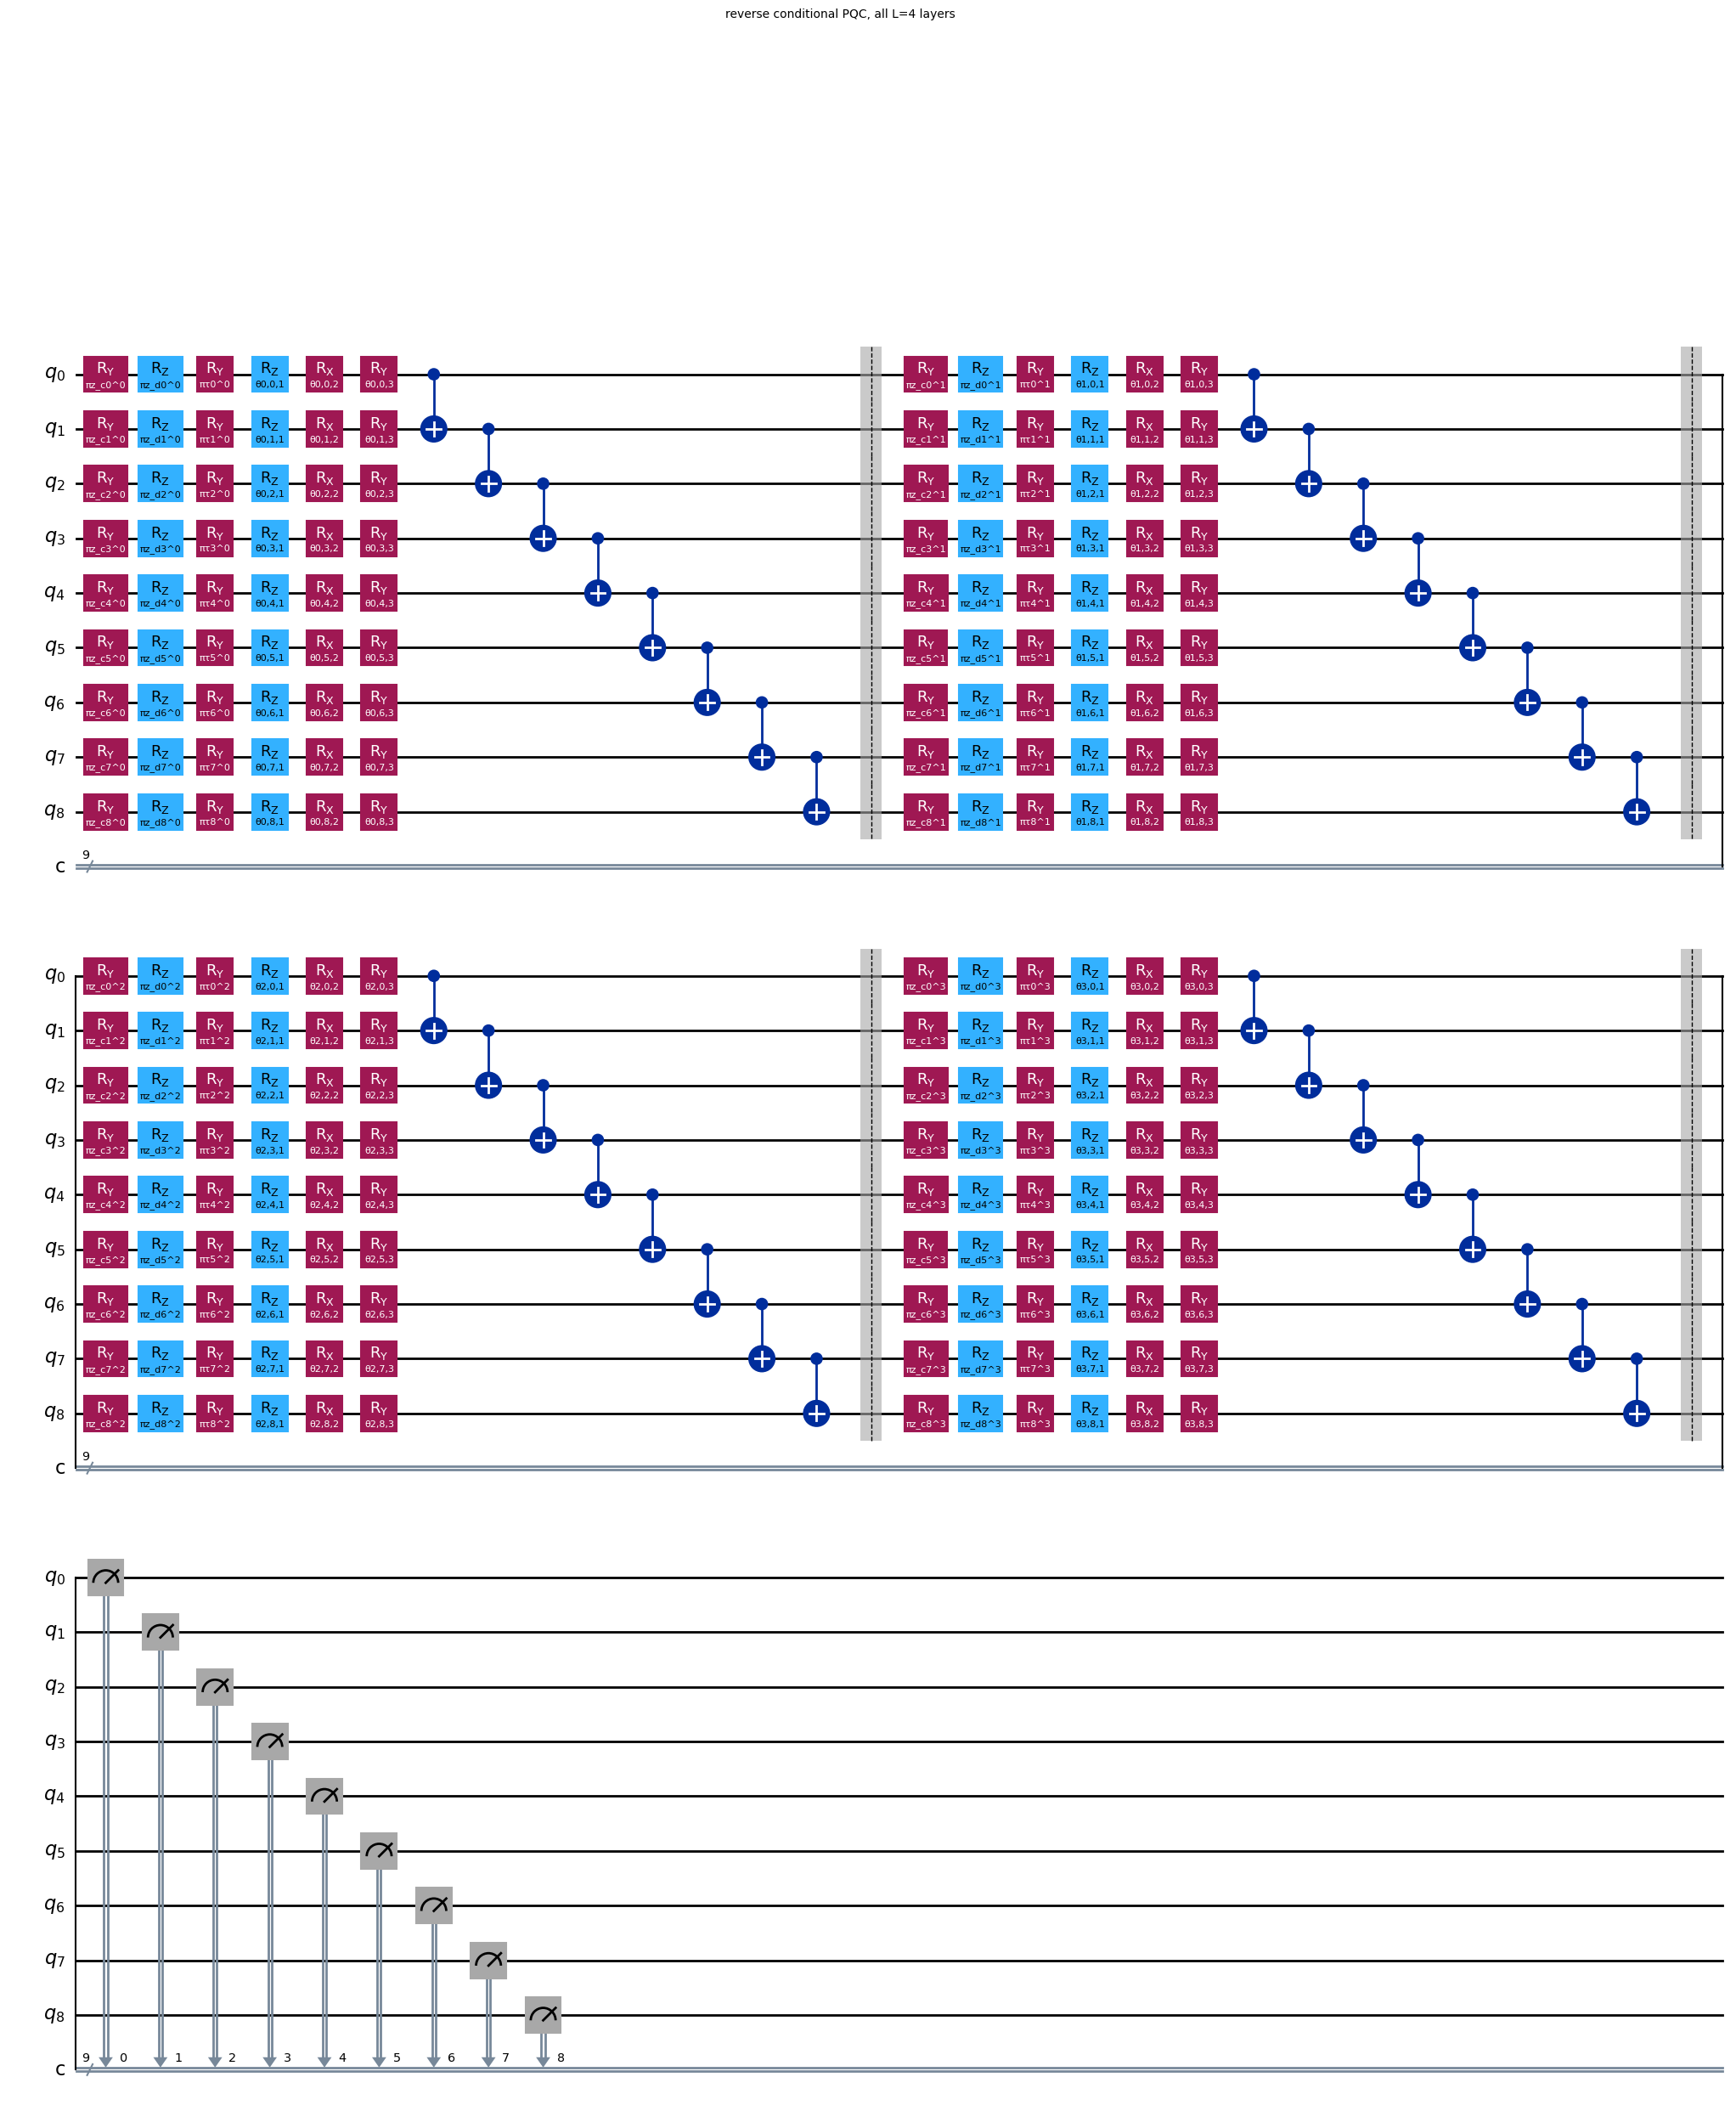

saved /root/qdrm_results/fig_circuit_reverse_pqc_full.png


In [36]:
import numpy as np, matplotlib.pyplot as plt
try:
    import pylatexenc                      # required by qiskit's 'mpl' drawer
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pylatexenc'],
                   check=False)
from IPython.display import display
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, Gate

import os
if 'RES_DIR' not in globals():
    RES_DIR = os.path.expanduser('~/qdrm_results')
    os.makedirs(RES_DIR, exist_ok=True)
if 'NQ' not in globals():    NQ = 9
if 'L' not in globals():     L = 4
if 'EDGES' not in globals(): EDGES = [(q, q + 1) for q in range(NQ - 1)]

def draw_show_save(circ, name, fold, title=None):
    """Render with the mpl drawer, display inline, save to RES_DIR."""
    try:
        f = circ.draw('mpl', fold=fold)
        if title:
            f.suptitle(title, fontsize=10, y=1.02)
        f.savefig(f'{RES_DIR}/{name}.png', dpi=150, bbox_inches='tight')
        display(f)
        plt.close(f)
        print('saved', f'{RES_DIR}/{name}.png')
    except Exception as e:
        print(f'[mpl failed for {name}: {type(e).__name__}: {e}]')
        print(circ.draw('text', fold=max(fold, 100)))   # text fallback still shown

# Reduced illustrations ----------------
# FRQI encoding: |I> = (1/2) sum_i |i> ( cos th_i |0> + sin th_i |1> )
pos = QuantumRegister(2, 'pos'); col = QuantumRegister(1, 'c')
frqi = QuantumCircuit(pos, col)
frqi.h(pos)
for i in range(4):
    b = format(i, '02b')
    for q, bit in enumerate(reversed(b)):
        if bit == '0': frqi.x(pos[q])
    frqi.append(Gate('cc-RY', 3, [], label=f'RY(2θ_{i})'), [pos[0], pos[1], col[0]])
    for q, bit in enumerate(reversed(b)):
        if bit == '0': frqi.x(pos[q])
draw_show_save(frqi, 'fig_circuit_frqi', 20, '(a) FRQI encoding (Eq. 7), 2x2 patch')

# one forward diffusion step
nq_show = 3
fwd = QuantumCircuit(nq_show)
for q in range(nq_show):
    fwd.rz(Parameter(f'ε_t β_{q}'), q)
    fwd.rx(Parameter(f'ε_t γ_{q}'), q)
    fwd.rz(Parameter(f'ε_t δ_{q}'), q)
for q in range(nq_show):
    fwd.append(Gate('Λ_t', 1, [], label='Λ_t: depol(1-α_t)'), [q])
draw_show_save(fwd, 'fig_circuit_forward', 20, '(b) one forward diffusion step (Eqs. 16-23)')

# reverse conditional PQC, one layer
nq_show = 4
rev = QuantumCircuit(nq_show, nq_show)
for q in range(nq_show):
    rev.ry(Parameter(f'π z_c{q}'), q)
    rev.rz(Parameter(f'π z_d{q}'), q)
    rev.ry(Parameter(f'π τ{q}'), q)
rev.barrier()
for q in range(nq_show):
    rev.rz(Parameter(f'θ{q},1'), q)
    rev.rx(Parameter(f'θ{q},2'), q)
    rev.ry(Parameter(f'θ{q},3'), q)
rev.barrier()
for q in range(nq_show - 1):
    rev.cx(q, q + 1)
rev.measure(range(nq_show), range(nq_show))
draw_show_save(rev, 'fig_circuit_reverse_pqc', 24, '(c) reverse conditional PQC, one of L layers')

# Full-size (real) circuit
posF = QuantumRegister(4, 'pos'); colF = QuantumRegister(1, 'c')
frqi_full = QuantumCircuit(posF, colF)
frqi_full.h(posF)
for i in range(16):
    b = format(i, '04b')
    for q, bit in enumerate(reversed(b)):
        if bit == '0': frqi_full.x(posF[q])
    frqi_full.append(Gate('mc-RY', 5, [], label=f'RY(2θ_{i})'),
                     [posF[0], posF[1], posF[2], posF[3], colF[0]])
    for q, bit in enumerate(reversed(b)):
        if bit == '0': frqi_full.x(posF[q])
print(f'(a-full) FRQI 4x4: {frqi_full.num_qubits} qubits, depth {frqi_full.depth()}')
draw_show_save(frqi_full, 'fig_circuit_frqi_full', 24, 'FRQI state preparation, full 4x4 patch')

fwd_full = QuantumCircuit(NQ)
for q in range(NQ):
    fwd_full.rz(Parameter(f'ε_t β_{q}'), q)
    fwd_full.rx(Parameter(f'ε_t γ_{q}'), q)
    fwd_full.rz(Parameter(f'ε_t δ_{q}'), q)
for q in range(NQ):
    fwd_full.append(Gate('Λ_t', 1, [], label='Λ_t'), [q])
draw_show_save(fwd_full, 'fig_circuit_forward_full', 30, f'one forward step, all {NQ} latent qubits')

rev_full = QuantumCircuit(NQ, NQ)
for l in range(L):
    for q in range(NQ):
        rev_full.ry(Parameter(f'πz_c{q}^{l}'), q)
        rev_full.rz(Parameter(f'πz_d{q}^{l}'), q)
        rev_full.ry(Parameter(f'πτ{q}^{l}'), q)
    for q in range(NQ):
        rev_full.rz(Parameter(f'θ{l},{q},1'), q)
        rev_full.rx(Parameter(f'θ{l},{q},2'), q)
        rev_full.ry(Parameter(f'θ{l},{q},3'), q)
    for (a, b) in EDGES:
        rev_full.cx(a, b)
    rev_full.barrier()
rev_full.measure(range(NQ), range(NQ))
print(f'(c-full) reverse PQC: {NQ} qubits, L={L} layers, depth {rev_full.depth()}, '
      f'{len(EDGES)*L} CNOTs — exactly the circuit trained and run on hardware')
draw_show_save(rev_full, 'fig_circuit_reverse_pqc_full', 30, f'reverse conditional PQC, all L={L} layers')

In [37]:
import shutil
for src, dst in [('fig_circuit_reverse_pqc',      'fig_circuit_reverse_in_pqc'),
                 ('fig_circuit_frqi_full',        'circuit_frqi'),
                 ('fig_circuit_forward_full',     'circuit_forward_full'),
                 ('fig_circuit_reverse_pqc_full', 'fig_circuit_reverse_in_pqc_and_full')]:
    p = f'{RES_DIR}/{src}.png'
    if os.path.exists(p):
        shutil.copy(p, f'{RES_DIR}/{dst}.png'); print('->', f'{dst}.png')

-> fig_circuit_reverse_in_pqc.png
-> circuit_frqi.png
-> circuit_forward_full.png
-> fig_circuit_reverse_in_pqc_and_full.png
